In [2]:
# ============================================================
# CELL 1 — Basic Imports
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully!")
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

Libraries imported successfully!
OpenCV version: 5.0.0
NumPy version: 2.5.1


In [3]:
# ============================================================
# CELL 2 — Project and Dataset Paths
# ============================================================

from pathlib import Path

# Current project folder
PROJECT_ROOT = Path.cwd()

# Chula RBC-12 dataset
DATASET_ROOT = PROJECT_ROOT / "Chula-RBC-12-Dataset-1.0"

# Image and annotation folders
IMAGE_DIR = DATASET_ROOT / "Dataset"
LABEL_DIR = DATASET_ROOT / "Label"

print("Project Root:")
print(PROJECT_ROOT)

print("\nDataset Root:")
print(DATASET_ROOT)

print("\nDataset exists:", DATASET_ROOT.exists())
print("Image folder exists:", IMAGE_DIR.exists())
print("Label folder exists:", LABEL_DIR.exists())

Project Root:
c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT

Dataset Root:
c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\Chula-RBC-12-Dataset-1.0

Dataset exists: True
Image folder exists: True
Label folder exists: True


In [4]:
# ============================================================
# CELL 3 — Verify Dataset Files
# ============================================================

# Get all JPG images
image_files = sorted(IMAGE_DIR.glob("*.jpg"))

# Get all TXT annotation files
label_files = sorted(LABEL_DIR.glob("*.txt"))

print("Total images :", len(image_files))
print("Total labels :", len(label_files))

print("\nFirst 5 image files:")
for file in image_files[:5]:
    print(file.name)

print("\nFirst 5 label files:")
for file in label_files[:5]:
    print(file.name)

# Basic consistency check
if len(image_files) == len(label_files):
    print("\n✅ Number of images and labels match.")
else:
    print("\n⚠️ Number of images and labels do NOT match.")

Total images : 706
Total labels : 591

First 5 image files:
1.jpg
10.jpg
100.jpg
101.jpg
102.jpg

First 5 label files:
1.txt
10.txt
100.txt
101.txt
102.txt

⚠️ Number of images and labels do NOT match.


In [5]:
# ============================================================
# CELL 3 — Check Image/Label Correspondence
# ============================================================

# Get image names without the extension
image_ids = {file.stem for file in IMAGE_DIR.glob("*.jpg")}

# Get label names without the extension
label_ids = {file.stem for file in LABEL_DIR.glob("*.txt")}

# Images that have no corresponding label file
images_without_labels = sorted(image_ids - label_ids, key=lambda x: int(x))

# Labels that have no corresponding image
labels_without_images = sorted(label_ids - image_ids, key=lambda x: int(x))

print("Total images:", len(image_ids))
print("Total labels:", len(label_ids))

print("\nImages WITHOUT labels:", len(images_without_labels))
print("Labels WITHOUT images:", len(labels_without_images))

print("\nFirst 20 images without labels:")
print(images_without_labels[:20])

print("\nFirst 20 labels without images:")
print(labels_without_images[:20])

Total images: 706
Total labels: 591

Images WITHOUT labels: 115
Labels WITHOUT images: 0

First 20 images without labels:
['18', '47', '50', '58', '59', '60', '61', '62', '63', '77', '87', '93', '104', '108', '109', '110', '111', '112', '113', '114']

First 20 labels without images:
[]


In [6]:
# ============================================================
# CELL 4 — Find a Valid Image + Label Pair
# ============================================================

# Find image IDs that have a corresponding label file
valid_image_ids = sorted(
    image_ids.intersection(label_ids),
    key=lambda x: int(x)
)

print("Images with labels:", len(valid_image_ids))

# Select the first valid image
sample_id = valid_image_ids[0]

sample_image_path = IMAGE_DIR / f"{sample_id}.jpg"
sample_label_path = LABEL_DIR / f"{sample_id}.txt"

print("\nSelected image:", sample_image_path.name)
print("Selected label:", sample_label_path.name)

# Load image
sample_image = cv2.imread(str(sample_image_path))

if sample_image is None:
    raise FileNotFoundError(
        f"Could not load image: {sample_image_path}"
    )

# Convert BGR → RGB for matplotlib
sample_image_rgb = cv2.cvtColor(
    sample_image,
    cv2.COLOR_BGR2RGB
)

print("\nImage loaded successfully!")
print("Image shape:", sample_image.shape)

Images with labels: 591

Selected image: 1.jpg
Selected label: 1.txt

Image loaded successfully!
Image shape: (480, 640, 3)


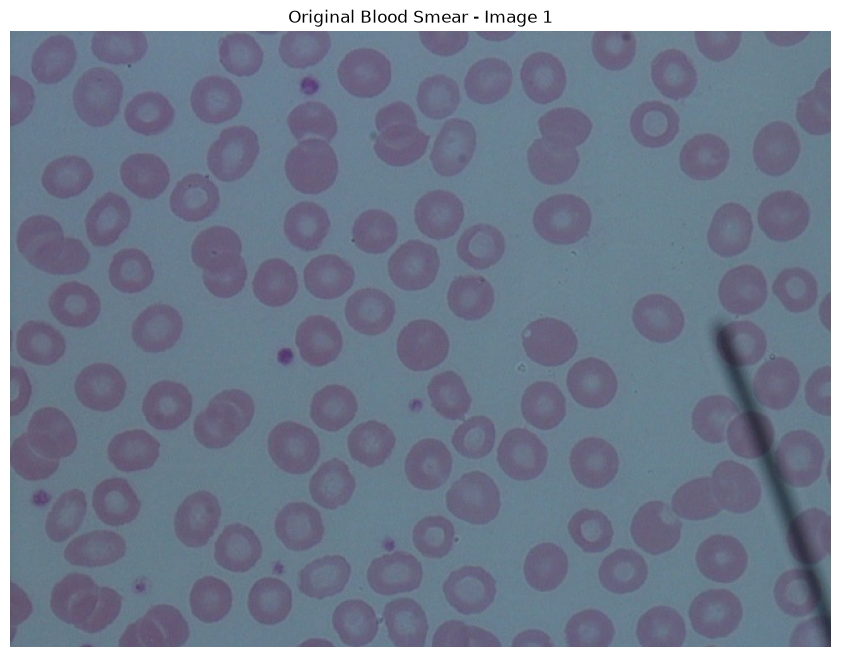

In [7]:
# ============================================================
# CELL 5 — Display Original Blood Smear
# ============================================================

plt.figure(figsize=(12, 8))

plt.imshow(sample_image_rgb)

plt.title(
    f"Original Blood Smear - Image {sample_id}"
)

plt.axis("off")
plt.show()

In [8]:
# ============================================================
# CELL 6 — Read RBC Annotation File
# ============================================================

# Read the label file corresponding to our selected image
with open(sample_label_path, "r") as file:
    label_lines = file.readlines()

print("Total RBC annotations:", len(label_lines))

print("\nFirst 10 annotations:")

for line in label_lines[:10]:
    print(line.strip())

Total RBC annotations: 117

First 10 annotations:
594 95 0
601 151 0
556 153 0
548 99 0
508 77 0
515 30 0
471 21 0
410 39 0
380 41 0
334 50 0


In [9]:

# ============================================================
# CELL 7 — RBC Class Names
# ============================================================

CLASS_NAMES = {
    0: "Normal cell",
    1: "Macrocyte",
    2: "Microcyte",
    3: "Spherocyte",
    4: "Target cell",
    5: "Stomatocyte",
    6: "Ovalocyte",
    7: "Teardrop",
    8: "Burr cell",
    9: "Schistocyte",
    10: "Uncategorized",
    11: "Hypochromia"
}

print("Total RBC classes:", len(CLASS_NAMES))

for class_id, class_name in CLASS_NAMES.items():
    print(f"{class_id} → {class_name}")

Total RBC classes: 12
0 → Normal cell
1 → Macrocyte
2 → Microcyte
3 → Spherocyte
4 → Target cell
5 → Stomatocyte
6 → Ovalocyte
7 → Teardrop
8 → Burr cell
9 → Schistocyte
10 → Uncategorized
11 → Hypochromia


Total valid RBC annotations: 117

First 10 annotations:
{'x': 594, 'y': 95, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 601, 'y': 151, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 556, 'y': 153, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 548, 'y': 99, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 508, 'y': 77, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 515, 'y': 30, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 471, 'y': 21, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 410, 'y': 39, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 380, 'y': 41, 'class_id': 0, 'class_name': 'Normal cell'}
{'x': 334, 'y': 50, 'class_id': 0, 'class_name': 'Normal cell'}


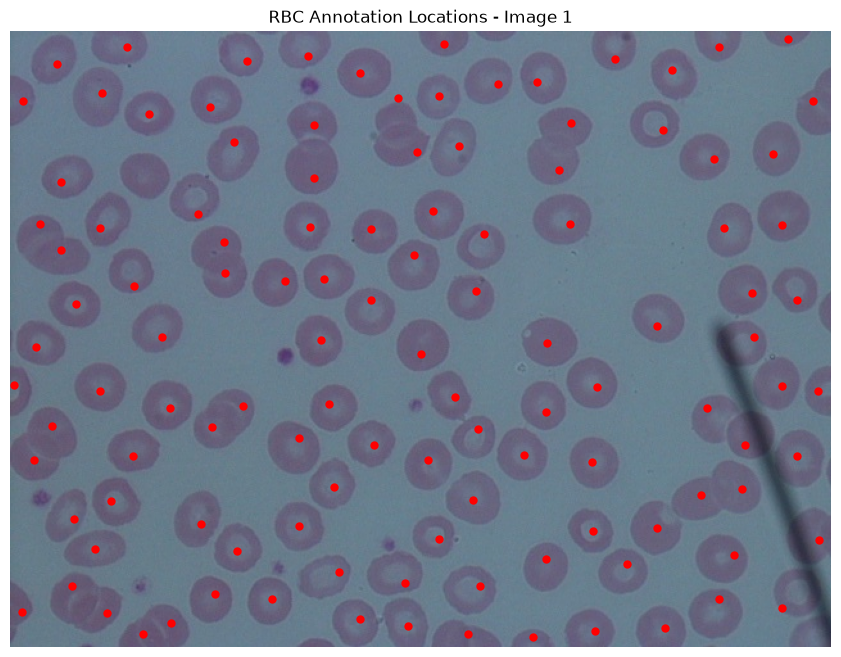

In [10]:
# ============================================================
# CELL 8 — Parse RBC Annotations and Visualize Their Locations
# ============================================================

annotations = []

for line in label_lines:

    values = line.strip().split()

    # Each valid line should contain:
    # x coordinate, y coordinate, class ID
    if len(values) != 3:
        continue

    x = int(values[0])
    y = int(values[1])
    class_id = int(values[2])

    # Check that the class ID is valid
    if class_id not in CLASS_NAMES:
        print(f"Warning: Unknown class ID {class_id}")
        continue

    annotations.append({
        "x": x,
        "y": y,
        "class_id": class_id,
        "class_name": CLASS_NAMES[class_id]
    })

print("Total valid RBC annotations:", len(annotations))

print("\nFirst 10 annotations:")

for annotation in annotations[:10]:
    print(annotation)


# ------------------------------------------------------------
# Display annotation points on the blood smear
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

plt.imshow(sample_image_rgb)

for annotation in annotations:

    x = annotation["x"]
    y = annotation["y"]

    plt.scatter(
        x,
        y,
        c="red",
        s=25
    )

plt.title(
    f"RBC Annotation Locations - Image {sample_id}"
)

plt.axis("off")
plt.show()

In [11]:
# ============================================================
# CELL 9 — Class Distribution in the Selected Image
# ============================================================

from collections import Counter

# Count how many RBCs belong to each class
class_counts = Counter(
    annotation["class_id"]
    for annotation in annotations
)

print("RBC class distribution for Image", sample_id)
print("-" * 50)

for class_id in sorted(CLASS_NAMES.keys()):

    count = class_counts.get(class_id, 0)

    print(
        f"{class_id:2d} - "
        f"{CLASS_NAMES[class_id]:20s} : "
        f"{count}"
    )

print("-" * 50)
print("Total RBCs:", sum(class_counts.values()))

RBC class distribution for Image 1
--------------------------------------------------
 0 - Normal cell          : 112
 1 - Macrocyte            : 0
 2 - Microcyte            : 0
 3 - Spherocyte           : 0
 4 - Target cell          : 0
 5 - Stomatocyte          : 0
 6 - Ovalocyte            : 5
 7 - Teardrop             : 0
 8 - Burr cell            : 0
 9 - Schistocyte          : 0
10 - Uncategorized        : 0
11 - Hypochromia          : 0
--------------------------------------------------
Total RBCs: 117


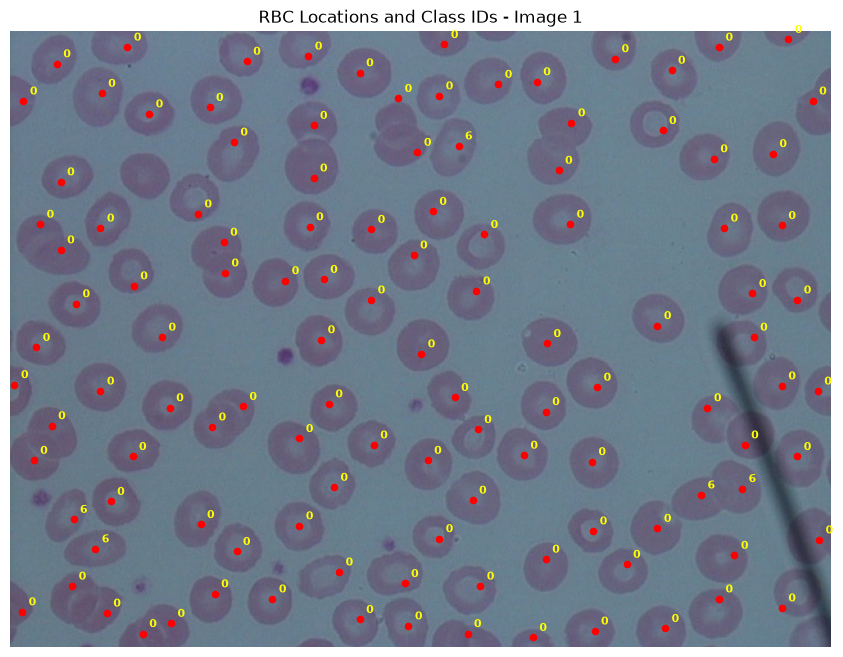

In [12]:
# ============================================================
# CELL 10 — Visualize RBC Class IDs
# ============================================================

plt.figure(figsize=(12, 8))

plt.imshow(sample_image_rgb)

for annotation in annotations:

    x = annotation["x"]
    y = annotation["y"]
    class_id = annotation["class_id"]

    # Mark the RBC center
    plt.scatter(
        x,
        y,
        c="red",
        s=20
    )

    # Display class ID beside the point
    plt.text(
        x + 5,
        y - 5,
        str(class_id),
        fontsize=8,
        color="yellow",
        fontweight="bold"
    )

plt.title(
    f"RBC Locations and Class IDs - Image {sample_id}"
)

plt.axis("off")
plt.show()

Original image shape: (480, 640, 3)
Green channel shape: (480, 640)


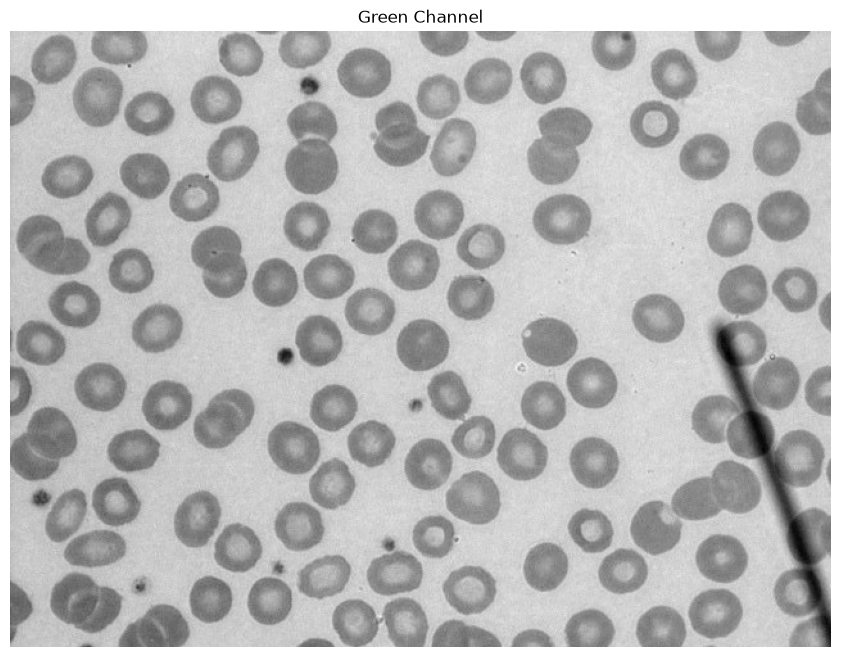

In [13]:
# ============================================================
# CELL 11 — Extract Green Channel
# ============================================================

# OpenCV image format:
# channel 0 = Blue
# channel 1 = Green
# channel 2 = Red

green_channel = sample_image[:, :, 1]

print("Original image shape:", sample_image.shape)
print("Green channel shape:", green_channel.shape)

# Display green channel
plt.figure(figsize=(12, 8))

plt.imshow(green_channel, cmap="gray")

plt.title("Green Channel")

plt.axis("off")
plt.show()

CLAHE image shape: (480, 640)


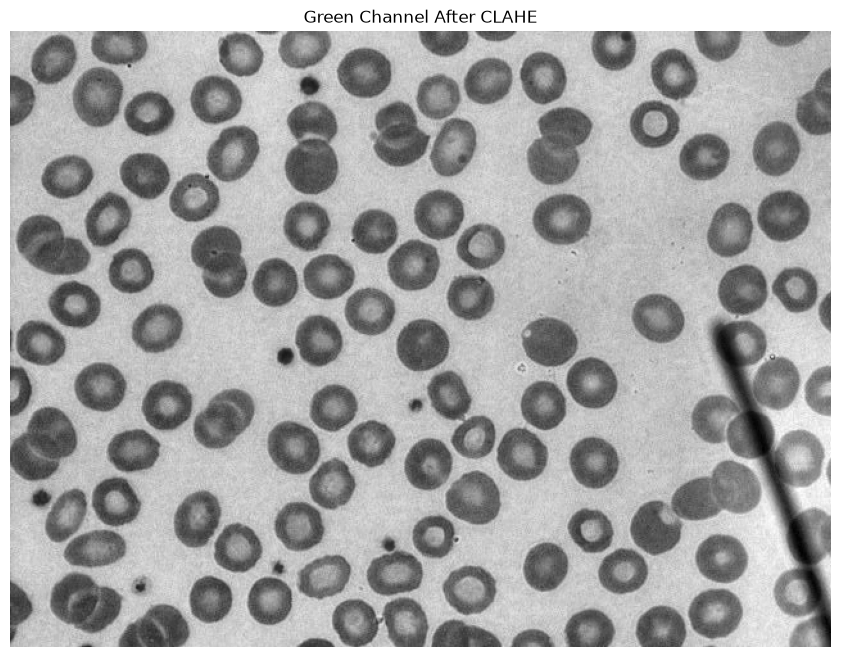

In [14]:
# ============================================================
# CELL 12 — CLAHE Contrast Enhancement
# ============================================================

# Create CLAHE object
# clipLimit controls contrast enhancement.
# tileGridSize divides the image into small regions.
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Apply CLAHE to the green channel
clahe_image = clahe.apply(green_channel)

print("CLAHE image shape:", clahe_image.shape)

# Display result
plt.figure(figsize=(12, 8))

plt.imshow(clahe_image, cmap="gray")

plt.title("Green Channel After CLAHE")

plt.axis("off")
plt.show()

Otsu threshold value: 121.0


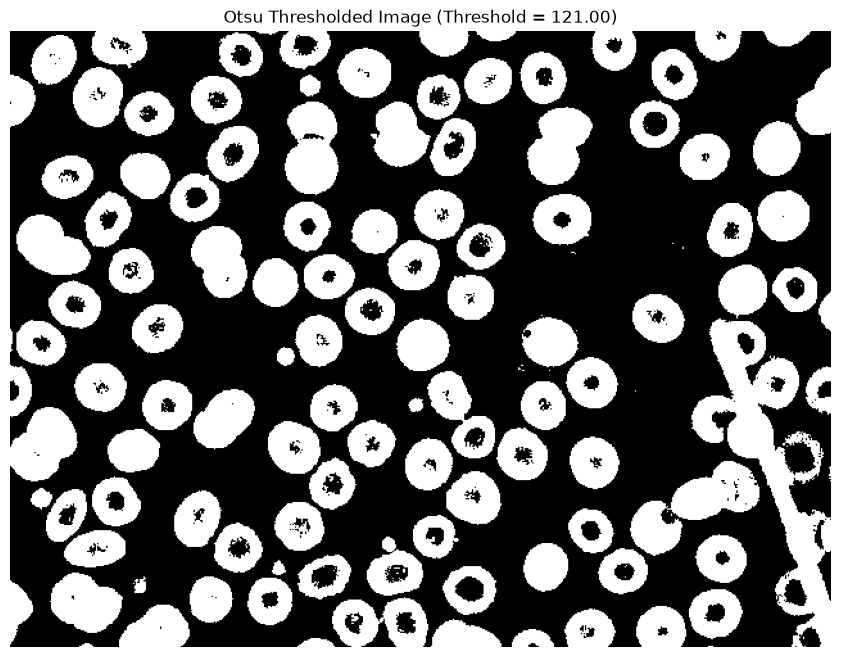

In [15]:
# ============================================================
# CELL 13 — Otsu Thresholding
# ============================================================

# Otsu automatically chooses a threshold value
# to separate darker RBC regions from the lighter background.

otsu_threshold, binary_image = cv2.threshold(
    clahe_image,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Otsu threshold value:", otsu_threshold)

# Display the binary result
plt.figure(figsize=(12, 8))

plt.imshow(binary_image, cmap="gray")

plt.title(
    f"Otsu Thresholded Image (Threshold = {otsu_threshold:.2f})"
)

plt.axis("off")
plt.show()


Total contours detected: 131
Contours after noise filtering: 105


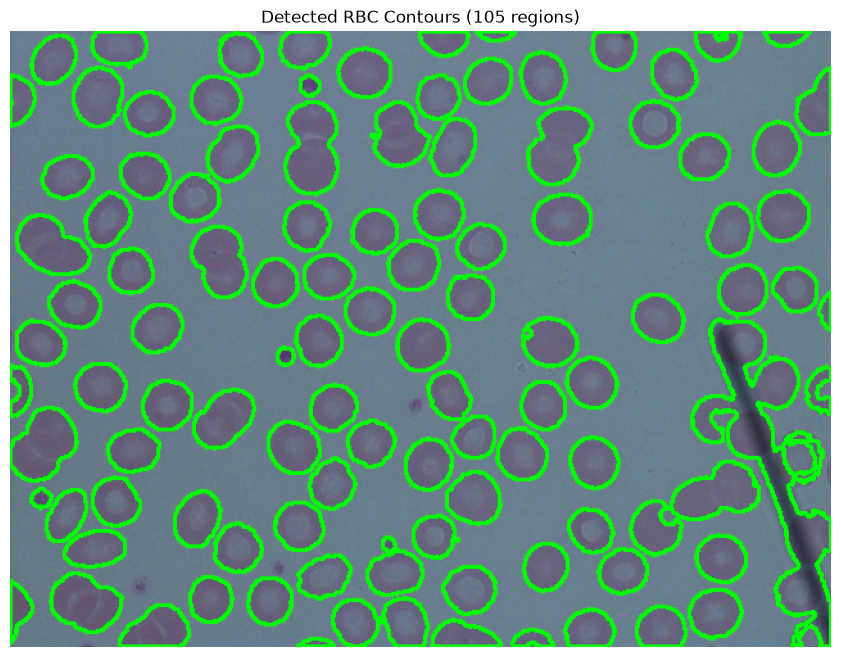

In [16]:
# ============================================================
# CELL 14 — RBC Contour Detection
# ============================================================

# Find the boundaries of white regions in the binary image.
#
# RETR_EXTERNAL:
#     Finds the outer boundary of each detected region.
#
# CHAIN_APPROX_NONE:
#     Keeps all boundary points.
#     This is useful later when we search for concave points.

contours, hierarchy = cv2.findContours(
    binary_image,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

print("Total contours detected:", len(contours))


# ------------------------------------------------------------
# Remove very small noise regions
# ------------------------------------------------------------

MIN_CONTOUR_AREA = 100

filtered_contours = []

for contour in contours:

    area = cv2.contourArea(contour)

    if area >= MIN_CONTOUR_AREA:
        filtered_contours.append(contour)


print("Contours after noise filtering:", len(filtered_contours))


# ------------------------------------------------------------
# Sort contours from largest to smallest
# ------------------------------------------------------------

filtered_contours = sorted(
    filtered_contours,
    key=cv2.contourArea,
    reverse=True
)


# ------------------------------------------------------------
# Display detected contours
# ------------------------------------------------------------

contour_image = sample_image_rgb.copy()

cv2.drawContours(
    contour_image,
    filtered_contours,
    -1,
    (0, 255, 0),
    2
)

plt.figure(figsize=(12, 8))

plt.imshow(contour_image)

plt.title(
    f"Detected RBC Contours "
    f"({len(filtered_contours)} regions)"
)

plt.axis("off")
plt.show()

Largest contour information
----------------------------------------
Area      : 8764.0
Perimeter : 1251.224519252777
Bounding box:
x = 531
y = 224
width = 109
height = 256
Number of boundary points: 1064


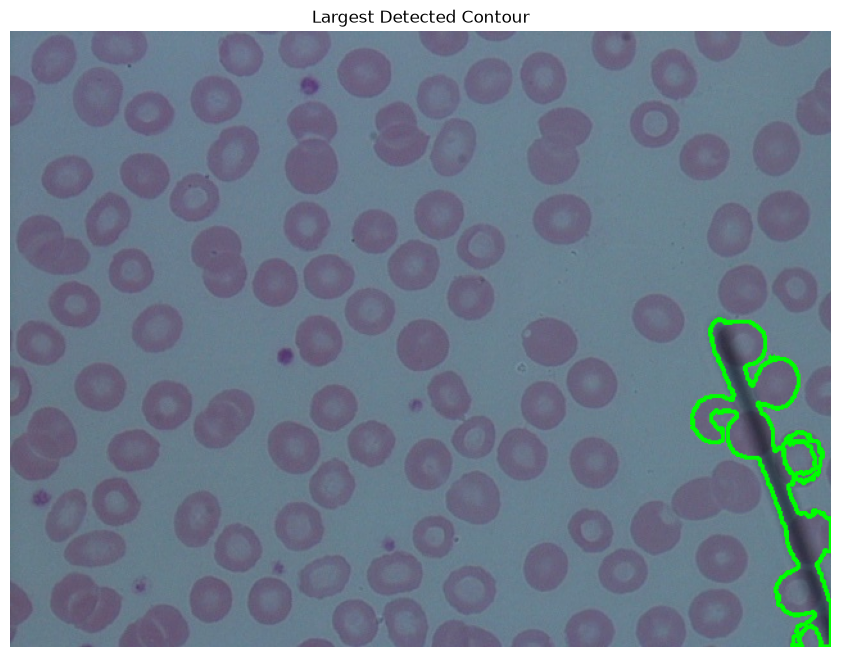

In [17]:
# ============================================================
# CELL 15 — Inspect Largest Contour
# ============================================================

# Make sure we have detected contours
if len(filtered_contours) == 0:
    raise ValueError("No contours were detected. Check Cell 13 and Cell 14.")

# Take the largest detected contour
largest_contour = filtered_contours[0]

# Calculate its area
largest_area = cv2.contourArea(largest_contour)

# Calculate its perimeter
largest_perimeter = cv2.arcLength(
    largest_contour,
    True
)

# Bounding rectangle
x, y, w, h = cv2.boundingRect(largest_contour)

print("Largest contour information")
print("-" * 40)
print("Area      :", largest_area)
print("Perimeter :", largest_perimeter)
print("Bounding box:")
print("x =", x)
print("y =", y)
print("width =", w)
print("height =", h)
print("Number of boundary points:", len(largest_contour))


# ------------------------------------------------------------
# Display only the largest contour
# ------------------------------------------------------------

largest_contour_image = sample_image_rgb.copy()

cv2.drawContours(
    largest_contour_image,
    [largest_contour],
    -1,
    (0, 255, 0),
    2
)

plt.figure(figsize=(12, 8))

plt.imshow(largest_contour_image)

plt.title("Largest Detected Contour")

plt.axis("off")

plt.show()

Contour points shape: (1064, 2)

First 10 boundary points:
[[552 224]
 [551 225]
 [550 225]
 [549 226]
 [548 227]
 [547 227]
 [547 228]
 [547 229]
 [546 230]
 [546 231]]


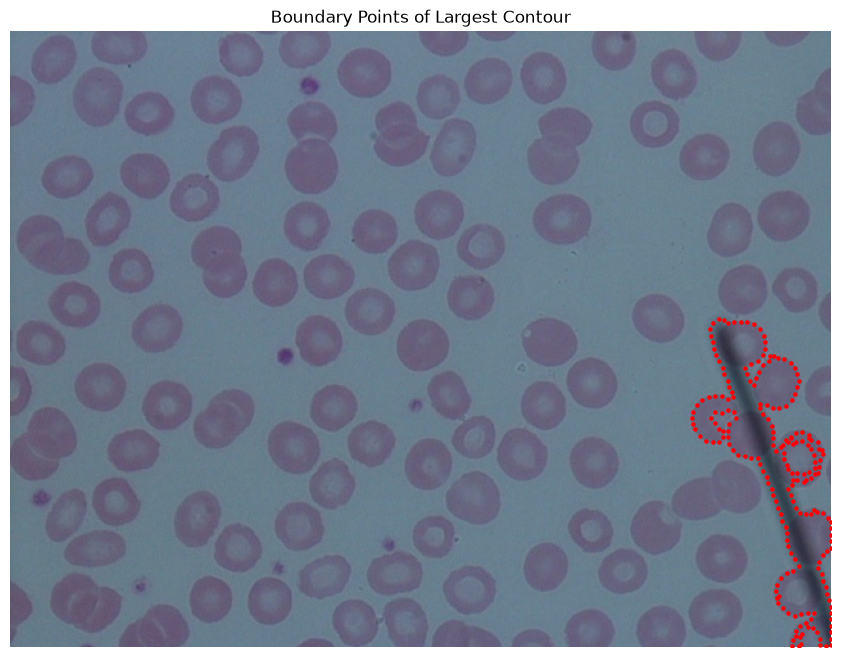

In [18]:
# ============================================================
# CELL 16 — Prepare Contour Boundary
# ============================================================

# OpenCV contour format:
# (number_of_points, 1, 2)
#
# Convert it to:
# (number_of_points, 2)
#
# Each row will contain:
# [x, y]

contour_points = largest_contour.reshape(-1, 2)

print("Contour points shape:", contour_points.shape)

print("\nFirst 10 boundary points:")
print(contour_points[:10])


# ------------------------------------------------------------
# Display the contour boundary points
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

plt.imshow(sample_image_rgb)

# Plot every 5th boundary point so the image
# does not become too crowded.
boundary_sample = contour_points[::5]

plt.scatter(
    boundary_sample[:, 0],
    boundary_sample[:, 1],
    s=5,
    c="red"
)

plt.title(
    "Boundary Points of Largest Contour"
)

plt.axis("off")
plt.show()

In [19]:
# ============================================================
# CELL 17 — Concave Point Detection
# ============================================================
#
# Paper methodology:
# For every boundary point:
#
#   1. Look at points on both sides of the boundary.
#   2. For j = 1 ... k, calculate the midpoint between them.
#   3. Check whether every midpoint lies OUTSIDE the contour.
#   4. If all midpoints are outside, the boundary point is
#      considered a concave point.
#
# We use k = 8 as specified in the project requirements.
# ============================================================

K = 8

# contour_points was created in Cell 16
num_points = len(contour_points)

concave_indices = []


# ------------------------------------------------------------
# Check every boundary point
# ------------------------------------------------------------

for i in range(num_points):

    is_concave = True

    for j in range(1, K + 1):

        # Circular indexing because a contour is closed.
        left_index = (i - j) % num_points
        right_index = (i + j) % num_points

        left_point = contour_points[left_index]
        right_point = contour_points[right_index]

        # Calculate midpoint
        midpoint_x = (
            left_point[0] + right_point[0]
        ) / 2.0

        midpoint_y = (
            left_point[1] + right_point[1]
        ) / 2.0

        # Check whether midpoint is outside contour.
        #
        # < 0  -> outside
        # = 0  -> on contour
        # > 0  -> inside
        result = cv2.pointPolygonTest(
            largest_contour,
            (float(midpoint_x), float(midpoint_y)),
            False
        )

        # The paper criterion requires ALL midpoints
        # to be outside.
        if result >= 0:
            is_concave = False
            break

    if is_concave:
        concave_indices.append(i)


print("K value:", K)
print("Total boundary points:", num_points)
print("Raw concave points detected:", len(concave_indices))

print("\nFirst 20 concave indices:")
print(concave_indices[:20])

K value: 8
Total boundary points: 1064
Raw concave points detected: 115

First 20 concave indices:
[33, 42, 62, 63, 65, 66, 67, 68, 71, 153, 158, 162, 166, 172, 175, 176, 180, 182, 184, 230]


In [20]:
# ============================================================
# CELL 18 — Keep Middle Point of Contiguous Concave Points
# ============================================================

def keep_middle_concave_points(indices, total_points):
    """
    Remove groups of contiguous concave boundary points.

    If several consecutive boundary indices are marked as
    concave, retain only the middle point of that group.

    Circular contour indexing is handled as well.
    """

    if not indices:
        return []

    indices = sorted(set(indices))

    groups = []
    current_group = [indices[0]]

    # --------------------------------------------------------
    # Group consecutive indices
    # --------------------------------------------------------

    for current in indices[1:]:

        previous = current_group[-1]

        if current == previous + 1:
            current_group.append(current)

        else:
            groups.append(current_group)
            current_group = [current]

    groups.append(current_group)

    # --------------------------------------------------------
    # Handle a group crossing the contour boundary
    #
    # Example:
    # [0, 1, 2, 641, 642]
    #
    # These are actually one continuous group because the
    # contour is circular.
    # --------------------------------------------------------

    if len(groups) > 1:

        first_group = groups[0]
        last_group = groups[-1]

        if (
            first_group[0] == 0
            and last_group[-1] == total_points - 1
        ):

            merged_group = last_group + first_group

            groups = groups[1:-1]

            groups.insert(0, merged_group)

    # --------------------------------------------------------
    # Keep only the middle point from every group
    # --------------------------------------------------------

    middle_points = []

    for group in groups:

        middle_index = group[len(group) // 2]

        middle_points.append(middle_index)

    return sorted(middle_points)


# Apply the filtering
filtered_concave_indices = keep_middle_concave_points(
    concave_indices,
    num_points
)

print("Raw concave points:",
      len(concave_indices))

print("After removing contiguous points:",
      len(filtered_concave_indices))

print("\nFiltered concave indices:")
print(filtered_concave_indices)

Raw concave points: 115
After removing contiguous points: 83

Filtered concave indices:
[33, 42, 63, 67, 71, 153, 158, 162, 166, 172, 176, 180, 182, 184, 230, 232, 244, 271, 274, 283, 285, 290, 312, 314, 316, 318, 350, 384, 387, 392, 396, 409, 434, 437, 445, 449, 453, 457, 526, 538, 549, 597, 599, 603, 609, 612, 614, 623, 626, 630, 633, 642, 692, 708, 711, 734, 766, 774, 782, 789, 791, 794, 796, 800, 808, 813, 817, 822, 841, 845, 871, 878, 884, 957, 976, 981, 983, 987, 995, 997, 999, 1053, 1057]


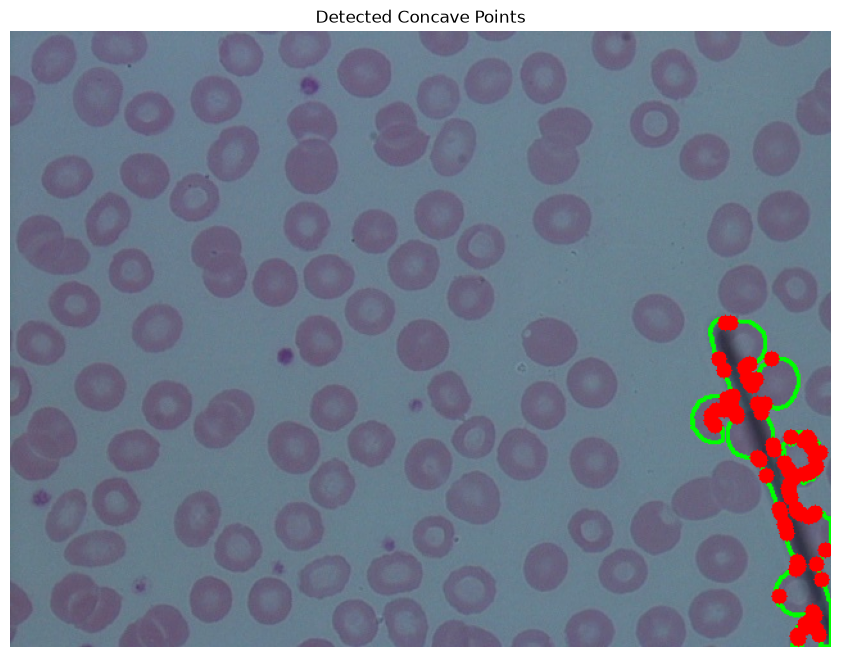

In [21]:
# ============================================================
# CELL 19 — Visualize Detected Concave Points
# ============================================================

concave_visualization = sample_image_rgb.copy()

# Draw the contour
cv2.drawContours(
    concave_visualization,
    [largest_contour],
    -1,
    (0, 255, 0),
    2
)


# ------------------------------------------------------------
# Draw concave points
# ------------------------------------------------------------

for index in filtered_concave_indices:

    x, y = contour_points[index]

    cv2.circle(
        concave_visualization,
        (int(x), int(y)),
        6,
        (255, 0, 0),
        -1
    )


plt.figure(figsize=(12, 8))

plt.imshow(concave_visualization)

plt.title(
    "Detected Concave Points"
)

plt.axis("off")

plt.show()

In [22]:
# ============================================================
# CELL 20 — Create Curves Between Consecutive Concave Points
# ============================================================
#
# Paper methodology:
# After finding concave points, the contour is divided into
# curve sections between consecutive concave points.
#
# These curve sections will later be used for ellipse fitting.
# ============================================================

if len(filtered_concave_indices) < 2:
    print("Not enough concave points to create curves.")

else:

    # Make sure indices are sorted
    sorted_concave_indices = sorted(
        filtered_concave_indices
    )

    curves = []

    total_points = len(contour_points)

    # --------------------------------------------------------
    # Create a curve between every pair of consecutive
    # concave points.
    # --------------------------------------------------------

    for i in range(len(sorted_concave_indices)):

        start_idx = sorted_concave_indices[i]

        # Next point.
        # For the last concave point, connect back to the first.
        end_idx = sorted_concave_indices[
            (i + 1) % len(sorted_concave_indices)
        ]

        # ----------------------------------------------------
        # Normal case:
        # start index < end index
        # ----------------------------------------------------

        if start_idx < end_idx:

            curve = contour_points[
                start_idx:end_idx + 1
            ]

        # ----------------------------------------------------
        # Circular case:
        #
        # Example:
        # start = 600
        # end   = 20
        #
        # The contour continues:
        # 600 → 601 → ... → last → 0 → ... → 20
        # ----------------------------------------------------

        else:

            curve = np.concatenate(
                (
                    contour_points[start_idx:],
                    contour_points[:end_idx + 1]
                ),
                axis=0
            )

        # Only keep curves with enough points
        if len(curve) >= 5:
            curves.append(curve)


    print("Total concave points:",
          len(sorted_concave_indices))

    print("Total usable curves:",
          len(curves))

    print("\nCurve sizes:")

    for i, curve in enumerate(curves):
        print(
            f"Curve {i + 1}: "
            f"{len(curve)} points"
        )

Total concave points: 83
Total usable curves: 61

Curve sizes:
Curve 1: 10 points
Curve 2: 22 points
Curve 3: 5 points
Curve 4: 5 points
Curve 5: 83 points
Curve 6: 6 points
Curve 7: 5 points
Curve 8: 5 points
Curve 9: 7 points
Curve 10: 5 points
Curve 11: 5 points
Curve 12: 47 points
Curve 13: 13 points
Curve 14: 28 points
Curve 15: 10 points
Curve 16: 6 points
Curve 17: 23 points
Curve 18: 33 points
Curve 19: 35 points
Curve 20: 6 points
Curve 21: 5 points
Curve 22: 14 points
Curve 23: 26 points
Curve 24: 9 points
Curve 25: 5 points
Curve 26: 5 points
Curve 27: 5 points
Curve 28: 70 points
Curve 29: 13 points
Curve 30: 12 points
Curve 31: 49 points
Curve 32: 5 points
Curve 33: 7 points
Curve 34: 10 points
Curve 35: 5 points
Curve 36: 10 points
Curve 37: 51 points
Curve 38: 17 points
Curve 39: 24 points
Curve 40: 33 points
Curve 41: 9 points
Curve 42: 9 points
Curve 43: 8 points
Curve 44: 5 points
Curve 45: 9 points
Curve 46: 6 points
Curve 47: 5 points
Curve 48: 6 points
Curve 49: 20

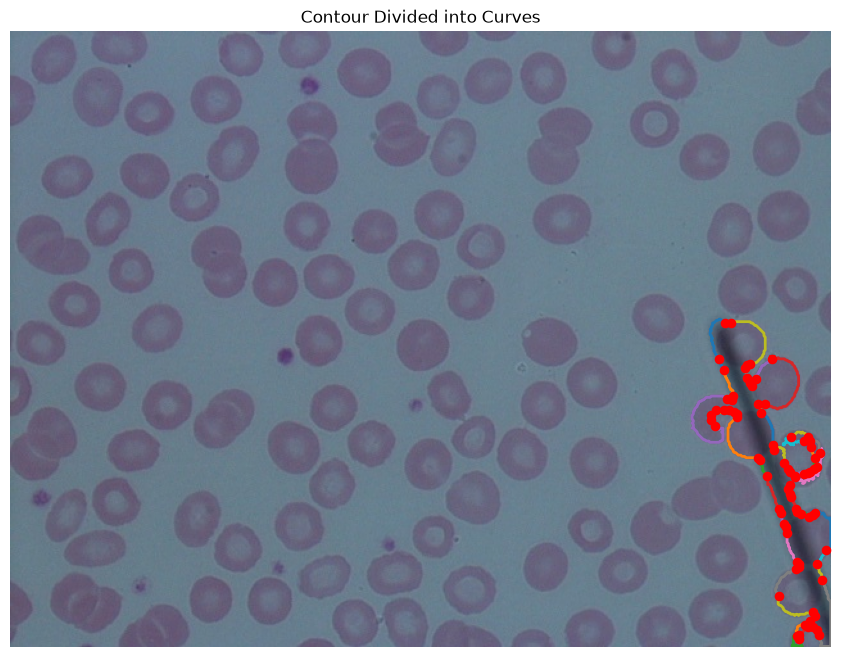

In [23]:
# ============================================================
# CELL 21 — Visualize Contour Curves
# ============================================================

plt.figure(figsize=(12, 8))

plt.imshow(sample_image_rgb)

# Different line styles will separate the curve sections
# visually.
for i, curve in enumerate(curves):

    plt.plot(
        curve[:, 0],
        curve[:, 1],
        linewidth=2,
        label=f"Curve {i + 1}"
    )


# Draw concave points
concave_points = contour_points[
    sorted_concave_indices
]

plt.scatter(
    concave_points[:, 0],
    concave_points[:, 1],
    s=35,
    c="red",
    zorder=5,
    label="Concave points"
)

plt.title(
    "Contour Divided into Curves"
)

plt.axis("off")

# Don't show a huge legend if there are many curves
if len(curves) <= 10:
    plt.legend()

plt.show()

In [24]:
# ============================================================
# CELL 22 — Direct Least-Squares Ellipse Fitting
# ============================================================
#
# Paper methodology:
#
#   a*x^2 + b*x*y + c*y^2 + d*x + e*y + f = 0
#
# with the ellipse constraint:
#
#   4ac - b^2 > 0
#
# This implements the Direct Least-Squares method associated
# with Fitzgibbon et al.
#
# cv2.fitEllipse() is NOT used here.
# ============================================================

import numpy as np
from scipy.linalg import eig


def fit_ellipse_fitzgibbon(points):
    """
    Fit an ellipse to a set of 2D points using the
    direct least-squares ellipse fitting method.

    Parameters
    ----------
    points : numpy.ndarray
        Array of shape (N, 2), containing [x, y] points.

    Returns
    -------
    conic : numpy.ndarray or None
        Six ellipse parameters:
        [a, b, c, d, e, f]

        representing:

        a*x^2 + b*x*y + c*y^2 + d*x + e*y + f = 0
    """

    points = np.asarray(points, dtype=np.float64)

    # Need enough points for a reliable ellipse
    if points.shape[0] < 6:
        return None

    x = points[:, 0]
    y = points[:, 1]

    # --------------------------------------------------------
    # Design matrix
    # --------------------------------------------------------

    D = np.column_stack([
        x ** 2,
        x * y,
        y ** 2,
        x,
        y,
        np.ones_like(x)
    ])

    # Scatter matrix
    S = D.T @ D

    # --------------------------------------------------------
    # Ellipse constraint matrix
    #
    # 4ac - b^2 = 1
    #
    # Matrix form:
    #
    #       [ 0  0  2 ]
    # C  =  [ 0 -1  0 ]
    #       [ 2  0  0 ]
    #
    # --------------------------------------------------------

    C = np.zeros((6, 6))

    C[0, 2] = 2
    C[1, 1] = -1
    C[2, 0] = 2

    # --------------------------------------------------------
    # Solve generalized eigenvalue problem:
    #
    # S*a = lambda*C*a
    # --------------------------------------------------------

    try:

        eigenvalues, eigenvectors = eig(S, C)

    except Exception:
        return None

    valid_vectors = []

    # --------------------------------------------------------
    # Find an eigenvector representing an ellipse
    # --------------------------------------------------------

    for i in range(len(eigenvalues)):

        eigenvalue = eigenvalues[i]

        # Ignore complex / invalid eigenvalues
        if not np.isfinite(eigenvalue.real):
            continue

        if abs(eigenvalue.imag) > 1e-6:
            continue

        vector = eigenvectors[:, i].real

        a = vector[0]
        b = vector[1]
        c = vector[2]

        # Ellipse condition
        ellipse_condition = 4 * a * c - b ** 2

        if ellipse_condition > 0:

            valid_vectors.append(vector)

    if len(valid_vectors) == 0:
        return None

    # Usually there should be one valid ellipse solution.
    conic = valid_vectors[0]

    # Normalize parameters
    if abs(conic[-1]) > 1e-12:
        conic = conic / np.linalg.norm(conic)

    return conic


print("Fitzgibbon ellipse fitting function loaded successfully.")

Fitzgibbon ellipse fitting function loaded successfully.


In [ ]:
# ============================================================
# CELL 23 — Fit Ellipse to Each Curve
# ============================================================

ellipse_results = []

for curve_number, curve in enumerate(curves):

    # Ignore extremely short curves
    if len(curve) < 20:
        continue

    ellipse = fit_ellipse_fitzgibbon(curve)

    if ellipse is not None:

        ellipse_results.append({
            "curve_id": curve_number,
            "points": curve,
            "parameters": ellipse
        })


print("Total curves:", len(curves))
print("Successfully fitted ellipses:",
      len(ellipse_results))

for result in ellipse_results:

    print(
        "Curve",
        result["curve_id"] + 1,
        "→ ellipse fitted"
    )

Total curves: 61
Successfully fitted ellipses: 16
Curve 2 → ellipse fitted
Curve 5 → ellipse fitted
Curve 12 → ellipse fitted
Curve 18 → ellipse fitted
Curve 19 → ellipse fitted
Curve 28 → ellipse fitted
Curve 31 → ellipse fitted
Curve 37 → ellipse fitted
Curve 39 → ellipse fitted
Curve 40 → ellipse fitted
Curve 49 → ellipse fitted
Curve 51 → ellipse fitted
Curve 54 → ellipse fitted
Curve 55 → ellipse fitted
Curve 59 → ellipse fitted
Curve 61 → ellipse fitted


In [36]:
# ============================================================
# CELL 24 — Convert Fitzgibbon Ellipse Parameters
# ============================================================

def ellipse_parameters(conic):
    """
    Convert Fitzgibbon conic coefficients:

        a*x² + b*x*y + c*y² + d*x + e*y + f = 0

    into ellipse properties:
        center
        major axis
        minor axis
        angle
        area
    """

    conic = np.asarray(
        conic,
        dtype=np.float64
    ).flatten()

    # --------------------------------------------------------
    # Validate input
    # --------------------------------------------------------

    if len(conic) != 6:
        return None

    a, b, c, d, e, f = conic


    # --------------------------------------------------------
    # Quadratic matrix
    # --------------------------------------------------------

    Q = np.array([
        [a, b / 2.0],
        [b / 2.0, c]
    ])


    linear = np.array([
        d,
        e
    ])


    # --------------------------------------------------------
    # Make quadratic matrix positive definite
    # --------------------------------------------------------

    eigenvalues = np.linalg.eigvalsh(Q)

    if np.all(eigenvalues < 0):

        conic = -conic

        a, b, c, d, e, f = conic

        Q = np.array([
            [a, b / 2.0],
            [b / 2.0, c]
        ])

        linear = np.array([
            d,
            e
        ])


    # --------------------------------------------------------
    # Check ellipse condition
    # --------------------------------------------------------

    eigenvalues = np.linalg.eigvalsh(Q)

    if np.any(eigenvalues <= 0):
        return None


    # --------------------------------------------------------
    # Calculate center
    # --------------------------------------------------------

    try:

        center = np.linalg.solve(
            Q,
            -linear / 2.0
        )

    except np.linalg.LinAlgError:

        return None


    cx = float(center[0])
    cy = float(center[1])


    # --------------------------------------------------------
    # Evaluate conic at center
    # --------------------------------------------------------

    F_center = (
        a * cx**2
        + b * cx * cy
        + c * cy**2
        + d * cx
        + e * cy
        + f
    )


    # --------------------------------------------------------
    # Valid ellipse requires negative center value
    # --------------------------------------------------------

    if F_center >= 0:
        return None


    # --------------------------------------------------------
    # Eigen decomposition
    # --------------------------------------------------------

    eigenvalues, eigenvectors = np.linalg.eigh(Q)


    # --------------------------------------------------------
    # Semi-axis lengths
    # --------------------------------------------------------

    semi_axes = np.sqrt(
        -F_center / eigenvalues
    )


    if np.any(
        ~np.isfinite(semi_axes)
    ):
        return None


    if np.any(
        semi_axes <= 0
    ):
        return None


    # --------------------------------------------------------
    # Sort axes: major first
    # --------------------------------------------------------

    order = np.argsort(
        semi_axes
    )[::-1]

    semi_axes = semi_axes[order]

    eigenvectors = eigenvectors[
        :, order
    ]


    # --------------------------------------------------------
    # Full axis lengths
    # --------------------------------------------------------

    major_axis = (
        2.0 * semi_axes[0]
    )

    minor_axis = (
        2.0 * semi_axes[1]
    )


    # --------------------------------------------------------
    # Angle of major axis
    # --------------------------------------------------------

    major_vector = eigenvectors[:, 0]

    angle = np.degrees(
        np.arctan2(
            major_vector[1],
            major_vector[0]
        )
    )

    angle = angle % 180.0


    # --------------------------------------------------------
    # Ellipse area
    # --------------------------------------------------------

    area = (
        np.pi
        * semi_axes[0]
        * semi_axes[1]
    )


    return {
        "center": (cx, cy),

        "major_axis": float(
            major_axis
        ),

        "minor_axis": float(
            minor_axis
        ),

        "angle": float(
            angle
        ),

        "area": float(
            area
        )
    }


print(
    "Ellipse parameter conversion loaded successfully."
)

Ellipse parameter conversion loaded successfully.


In [37]:
# ============================================================
# CELL 25 — Calculate Ellipse Properties
# ============================================================

ellipse_properties = []

for result in ellipse_results:

    curve_id = result["curve_id"]
    conic = result["parameters"]

    properties = ellipse_parameters(conic)

    if properties is not None:

        ellipse_properties.append({

            "curve_id": curve_id,

            "points": result["points"],

            "parameters": conic,

            "properties": properties
        })


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("=" * 60)
print("ELLIPSE PROPERTIES")
print("=" * 60)

print(
    "Total fitted ellipses:",
    len(ellipse_results)
)

print(
    "Successfully converted ellipses:",
    len(ellipse_properties)
)


# ------------------------------------------------------------
# Display properties
# ------------------------------------------------------------

for result in ellipse_properties:

    properties = result["properties"]

    print()

    print(
        f"Curve {result['curve_id'] + 1}:"
    )

    print(
        f"  Center = "
        f"({properties['center'][0]:.2f}, "
        f"{properties['center'][1]:.2f})"
    )

    print(
        f"  Major axis = "
        f"{properties['major_axis']:.2f}"
    )

    print(
        f"  Minor axis = "
        f"{properties['minor_axis']:.2f}"
    )

    print(
        f"  Angle = "
        f"{properties['angle']:.2f}"
    )

    print(
        f"  Area = "
        f"{properties['area']:.2f}"
    )

ELLIPSE PROPERTIES
Total fitted ellipses: 16
Successfully converted ellipses: 16

Curve 2:
  Center = (559.81, 274.31)
  Major axis = 15.54
  Minor axis = 1.73
  Angle = 67.75
  Area = 21.09

Curve 5:
  Center = (545.59, 301.39)
  Major axis = 36.55
  Minor axis = 27.10
  Angle = 99.04
  Area = 777.85

Curve 12:
  Center = (576.49, 314.50)
  Major axis = 35.81
  Minor axis = 35.44
  Angle = 16.07
  Area = 996.90

Curve 18:
  Center = (604.98, 430.31)
  Major axis = 24.83
  Minor axis = 12.08
  Angle = 127.94
  Area = 235.50

Curve 19:
  Center = (612.34, 445.56)
  Major axis = 28.33
  Minor axis = 17.39
  Angle = 11.26
  Area = 386.89

Curve 28:
  Center = (633.80, 455.99)
  Major axis = 52.30
  Minor axis = 10.88
  Angle = 86.93
  Area = 446.80

Curve 31:
  Center = (631.20, 389.55)
  Major axis = 33.43
  Minor axis = 16.94
  Angle = 81.97
  Area = 444.67

Curve 37:
  Center = (621.72, 336.71)
  Major axis = 30.14
  Minor axis = 18.89
  Angle = 115.76
  Area = 447.08

Curve 39:
  Cent

In [38]:
# ============================================================
# CELL 26 — Ellipse Verification Thresholds
# ============================================================

# Minimum percentage of ellipse that must be
# inside the original contour.
MIN_INSIDE_RATIO = 0.80


# Minimum percentage of ellipse that must represent
# new area not already covered by accepted ellipses.
MIN_NEW_AREA_RATIO = 0.20


# Minimum ellipse area.
#
# This is a practical threshold for our implementation.
# It can be adjusted after inspecting the dataset.
MIN_ELLIPSE_AREA = 300.0


print("=" * 60)
print("ELLIPSE VERIFICATION THRESHOLDS")
print("=" * 60)

print(
    "Minimum inside ratio:",
    MIN_INSIDE_RATIO
)

print(
    "Minimum new-area ratio:",
    MIN_NEW_AREA_RATIO
)

print(
    "Minimum ellipse area:",
    MIN_ELLIPSE_AREA
)

ELLIPSE VERIFICATION THRESHOLDS
Minimum inside ratio: 0.8
Minimum new-area ratio: 0.2
Minimum ellipse area: 300.0


In [39]:
# ============================================================
# CELL 27 — Create Ellipse Mask Function
# ============================================================

def create_ellipse_mask(image_shape, properties):
    """
    Create a binary mask for a fitted ellipse.

    Parameters
    ----------
    image_shape : tuple
        Shape of the image, e.g. (480, 640)

    properties : dict
        Ellipse properties returned by ellipse_parameters()

    Returns
    -------
    mask : numpy array
        Binary ellipse mask
    """

    # --------------------------------------------------------
    # Create empty mask
    # --------------------------------------------------------

    mask = np.zeros(
        image_shape[:2],
        dtype=np.uint8
    )


    # --------------------------------------------------------
    # Get ellipse center
    # --------------------------------------------------------

    cx, cy = properties["center"]


    center = (
        int(round(cx)),
        int(round(cy))
    )


    # --------------------------------------------------------
    # Get semi-axis lengths
    # --------------------------------------------------------

    major_radius = max(
        1,
        int(round(
            properties["major_axis"] / 2.0
        ))
    )

    minor_radius = max(
        1,
        int(round(
            properties["minor_axis"] / 2.0
        ))
    )


    axes = (
        major_radius,
        minor_radius
    )


    # --------------------------------------------------------
    # Get rotation angle
    # --------------------------------------------------------

    angle = properties["angle"]


    # --------------------------------------------------------
    # Draw filled ellipse
    # --------------------------------------------------------

    cv2.ellipse(
        mask,
        center,
        axes,
        angle,
        0,
        360,
        255,
        -1
    )


    return mask


print(
    "Ellipse mask function loaded successfully."
)

Ellipse mask function loaded successfully.


In [40]:
# ============================================================
# CELL 28 — Verify Fitted Ellipses
# ============================================================

def verify_ellipse(
    properties,
    contour,
    accepted_masks,
    image_shape,
    min_inside_ratio=MIN_INSIDE_RATIO,
    min_new_area_ratio=MIN_NEW_AREA_RATIO,
    min_area=MIN_ELLIPSE_AREA
):
    """
    Verify an ellipse using three criteria:

    1. At least 80% of ellipse area is inside contour
    2. At least 20% of ellipse area is new
    3. Ellipse area is above minimum threshold
    """

    # --------------------------------------------------------
    # Create ellipse mask
    # --------------------------------------------------------

    ellipse_mask = create_ellipse_mask(
        image_shape,
        properties
    )


    # --------------------------------------------------------
    # Create contour mask
    # --------------------------------------------------------

    contour_mask = np.zeros(
        image_shape[:2],
        dtype=np.uint8
    )

    cv2.drawContours(
        contour_mask,
        [contour],
        -1,
        255,
        -1
    )


    # --------------------------------------------------------
    # Calculate ellipse area
    # --------------------------------------------------------

    ellipse_pixels = np.count_nonzero(
        ellipse_mask
    )


    if ellipse_pixels == 0:

        return {
            "accepted": False,
            "reason": "Empty ellipse",
            "ellipse_mask": ellipse_mask,
            "inside_ratio": 0.0,
            "new_area_ratio": 0.0
        }


    # --------------------------------------------------------
    # Criterion 1:
    # Percentage of ellipse inside contour
    # --------------------------------------------------------

    inside_pixels = np.count_nonzero(
        (
            ellipse_mask > 0
        )
        &
        (
            contour_mask > 0
        )
    )


    inside_ratio = (
        inside_pixels
        / ellipse_pixels
    )


    # --------------------------------------------------------
    # Calculate already accepted area
    # --------------------------------------------------------

    if len(accepted_masks) == 0:

        previous_mask = np.zeros(
            image_shape[:2],
            dtype=np.uint8
        )

    else:

        previous_mask = np.zeros(
            image_shape[:2],
            dtype=np.uint8
        )

        for mask in accepted_masks:

            previous_mask = cv2.bitwise_or(
                previous_mask,
                mask
            )


    # --------------------------------------------------------
    # Criterion 2:
    # New area not covered by previous ellipses
    # --------------------------------------------------------

    new_pixels = np.count_nonzero(
        (
            ellipse_mask > 0
        )
        &
        (
            previous_mask == 0
        )
    )


    new_area_ratio = (
        new_pixels
        / ellipse_pixels
    )


    # --------------------------------------------------------
    # Criterion 3:
    # Size threshold
    # --------------------------------------------------------

    area = properties["area"]

    size_ok = (
        area >= min_area
    )


    # --------------------------------------------------------
    # Final decision
    # --------------------------------------------------------

    accepted = (
        inside_ratio >= min_inside_ratio
        and
        new_area_ratio >= min_new_area_ratio
        and
        size_ok
    )


    # --------------------------------------------------------
    # Reason for rejection
    # --------------------------------------------------------

    if accepted:

        reason = "Accepted"

    elif inside_ratio < min_inside_ratio:

        reason = "Less than 80% inside contour"

    elif new_area_ratio < min_new_area_ratio:

        reason = "Less than 20% new area"

    elif not size_ok:

        reason = "Ellipse too small"

    else:

        reason = "Failed verification"


    return {
        "accepted": accepted,

        "reason": reason,

        "ellipse_mask": ellipse_mask,

        "inside_ratio": inside_ratio,

        "new_area_ratio": new_area_ratio,

        "area": area
    }


print(
    "Ellipse verification function loaded successfully."
)

Ellipse verification function loaded successfully.


In [42]:
# ============================================================
# CELL 29 — Verify All Fitted Ellipses
# ============================================================

# ------------------------------------------------------------
# Sort ellipses by area — largest first
# ------------------------------------------------------------

ellipse_properties_sorted = sorted(
    ellipse_properties,
    key=lambda item: item["properties"]["area"],
    reverse=True
)


accepted_ellipses = []
rejected_ellipses = []

accepted_masks = []


# ------------------------------------------------------------
# Verify each ellipse
# ------------------------------------------------------------

for result in ellipse_properties_sorted:

    properties = result["properties"]

    verification = verify_ellipse(
        properties=properties,
        contour=contour,
        accepted_masks=accepted_masks,
        image_shape=sample_image_rgb.shape
    )


    # --------------------------------------------------------
    # Store verification information
    # --------------------------------------------------------

    result["verification"] = verification


    # --------------------------------------------------------
    # Accepted ellipse
    # --------------------------------------------------------

    if verification["accepted"]:

        accepted_ellipses.append(result)

        accepted_masks.append(
            verification["ellipse_mask"]
        )


    # --------------------------------------------------------
    # Rejected ellipse
    # --------------------------------------------------------

    else:

        rejected_ellipses.append(result)


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("=" * 60)
print("ELLIPSE VERIFICATION")
print("=" * 60)

print(
    "Candidate ellipses:",
    len(ellipse_properties_sorted)
)

print(
    "Accepted ellipses:",
    len(accepted_ellipses)
)

print(
    "Rejected ellipses:",
    len(rejected_ellipses)
)


# ------------------------------------------------------------
# Detailed results
# ------------------------------------------------------------

print()
print("Detailed verification:")
print("-" * 60)


for result in ellipse_properties_sorted:

    properties = result["properties"]

    verification = result["verification"]


    print()

    print(
        f"Curve {result['curve_id'] + 1}"
    )

    print(
        f"Area: "
        f"{properties['area']:.2f}"
    )

    print(
        f"Inside contour: "
        f"{verification['inside_ratio'] * 100:.2f}%"
    )

    print(
        f"New area: "
        f"{verification['new_area_ratio'] * 100:.2f}%"
    )

    print(
        f"Accepted: "
        f"{verification['accepted']}"
    )


    if not verification["accepted"]:

        print(
            f"Reason: "
            f"{verification['reason']}"
        )

ELLIPSE VERIFICATION
Candidate ellipses: 16
Accepted ellipses: 0
Rejected ellipses: 16

Detailed verification:
------------------------------------------------------------

Curve 54
Area: 1022.98
Inside contour: 0.00%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 59
Area: 1015.69
Inside contour: 0.00%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 12
Area: 996.90
Inside contour: 0.00%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 5
Area: 777.85
Inside contour: 0.00%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 61
Area: 465.06
Inside contour: 0.00%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 37
Area: 447.08
Inside contour: 0.00%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 28
Area: 446.80
Inside contour: 0.00%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 31
Area:

In [43]:
# ============================================================
# CELL 29 — Correct Ellipse Verification
# ============================================================

# ------------------------------------------------------------
# Rebuild the ORIGINAL contour mask from contour_points
# ------------------------------------------------------------

image_height, image_width = sample_image_rgb.shape[:2]

original_contour_mask = np.zeros(
    (image_height, image_width),
    dtype=np.uint8
)


# contour_points has shape:
# (N, 2)
#
# OpenCV drawContours expects:
# (N, 1, 2)

contour_for_opencv = np.asarray(
    contour_points,
    dtype=np.int32
).reshape(
    (-1, 1, 2)
)


cv2.drawContours(
    original_contour_mask,
    [contour_for_opencv],
    -1,
    255,
    -1
)


print("=" * 60)
print("CONTOUR MASK CHECK")
print("=" * 60)

print(
    "Image shape:",
    sample_image_rgb.shape
)

print(
    "Contour points:",
    len(contour_points)
)

print(
    "Contour mask pixels:",
    np.count_nonzero(
        original_contour_mask
    )
)


# ------------------------------------------------------------
# Sort fitted ellipses by area
# ------------------------------------------------------------

ellipse_properties_sorted = sorted(
    ellipse_properties,
    key=lambda item: item["properties"]["area"],
    reverse=True
)


accepted_ellipses = []
rejected_ellipses = []

accepted_masks = []


# ------------------------------------------------------------
# Verify every ellipse
# ------------------------------------------------------------

for result in ellipse_properties_sorted:

    properties = result["properties"]


    # --------------------------------------------------------
    # Create ellipse mask
    # --------------------------------------------------------

    ellipse_mask = create_ellipse_mask(
        sample_image_rgb.shape,
        properties
    )


    ellipse_pixels = np.count_nonzero(
        ellipse_mask
    )


    # --------------------------------------------------------
    # Calculate overlap with ORIGINAL contour
    # --------------------------------------------------------

    inside_pixels = np.count_nonzero(
        (
            ellipse_mask > 0
        )
        &
        (
            original_contour_mask > 0
        )
    )


    if ellipse_pixels > 0:

        inside_ratio = (
            inside_pixels
            / ellipse_pixels
        )

    else:

        inside_ratio = 0.0


    # --------------------------------------------------------
    # Calculate new area
    # --------------------------------------------------------

    if len(accepted_masks) == 0:

        previous_ellipses_mask = np.zeros(
            sample_image_rgb.shape[:2],
            dtype=np.uint8
        )

    else:

        previous_ellipses_mask = np.zeros(
            sample_image_rgb.shape[:2],
            dtype=np.uint8
        )

        for previous_mask in accepted_masks:

            previous_ellipses_mask = cv2.bitwise_or(
                previous_ellipses_mask,
                previous_mask
            )


    new_pixels = np.count_nonzero(
        (
            ellipse_mask > 0
        )
        &
        (
            previous_ellipses_mask == 0
        )
    )


    if ellipse_pixels > 0:

        new_area_ratio = (
            new_pixels
            / ellipse_pixels
        )

    else:

        new_area_ratio = 0.0


    # --------------------------------------------------------
    # Size criterion
    # --------------------------------------------------------

    area = properties["area"]

    size_ok = (
        area >= MIN_ELLIPSE_AREA
    )


    # --------------------------------------------------------
    # Final verification
    # --------------------------------------------------------

    accepted = (
        inside_ratio >= MIN_INSIDE_RATIO
        and
        new_area_ratio >= MIN_NEW_AREA_RATIO
        and
        size_ok
    )


    # --------------------------------------------------------
    # Reason
    # --------------------------------------------------------

    if accepted:

        reason = "Accepted"

    elif inside_ratio < MIN_INSIDE_RATIO:

        reason = "Less than 80% inside contour"

    elif new_area_ratio < MIN_NEW_AREA_RATIO:

        reason = "Less than 20% new area"

    elif not size_ok:

        reason = "Ellipse too small"

    else:

        reason = "Failed verification"


    # --------------------------------------------------------
    # Save verification information
    # --------------------------------------------------------

    result["verification"] = {

        "accepted": accepted,

        "reason": reason,

        "ellipse_mask": ellipse_mask,

        "inside_ratio": inside_ratio,

        "new_area_ratio": new_area_ratio,

        "area": area
    }


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    if accepted:

        accepted_ellipses.append(
            result
        )

        accepted_masks.append(
            ellipse_mask
        )

    else:

        rejected_ellipses.append(
            result
        )


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print()
print("=" * 60)
print("ELLIPSE VERIFICATION")
print("=" * 60)

print(
    "Candidate ellipses:",
    len(ellipse_properties_sorted)
)

print(
    "Accepted ellipses:",
    len(accepted_ellipses)
)

print(
    "Rejected ellipses:",
    len(rejected_ellipses)
)


# ------------------------------------------------------------
# Detailed results
# ------------------------------------------------------------

print()
print("Detailed verification:")
print("-" * 60)


for result in ellipse_properties_sorted:

    properties = result["properties"]

    verification = result["verification"]


    print()

    print(
        f"Curve {result['curve_id'] + 1}"
    )

    print(
        f"Area: "
        f"{properties['area']:.2f}"
    )

    print(
        f"Inside contour: "
        f"{verification['inside_ratio'] * 100:.2f}%"
    )

    print(
        f"New area: "
        f"{verification['new_area_ratio'] * 100:.2f}%"
    )

    print(
        f"Accepted: "
        f"{verification['accepted']}"
    )

    if not verification["accepted"]:

        print(
            f"Reason: "
            f"{verification['reason']}"
        )

CONTOUR MASK CHECK
Image shape: (480, 640, 3)
Contour points: 1064
Contour mask pixels: 9297

ELLIPSE VERIFICATION
Candidate ellipses: 16
Accepted ellipses: 7
Rejected ellipses: 9

Detailed verification:
------------------------------------------------------------

Curve 54
Area: 1022.98
Inside contour: 95.27%
New area: 100.00%
Accepted: True

Curve 59
Area: 1015.69
Inside contour: 98.88%
New area: 100.00%
Accepted: True

Curve 12
Area: 996.90
Inside contour: 96.19%
New area: 100.00%
Accepted: True

Curve 5
Area: 777.85
Inside contour: 78.69%
New area: 99.88%
Accepted: False
Reason: Less than 80% inside contour

Curve 61
Area: 465.06
Inside contour: 97.51%
New area: 42.83%
Accepted: True

Curve 37
Area: 447.08
Inside contour: 48.68%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curve 28
Area: 446.80
Inside contour: 98.89%
New area: 100.00%
Accepted: True

Curve 31
Area: 444.67
Inside contour: 97.21%
New area: 100.00%
Accepted: True

Curve 19
Area: 386.89
Insid

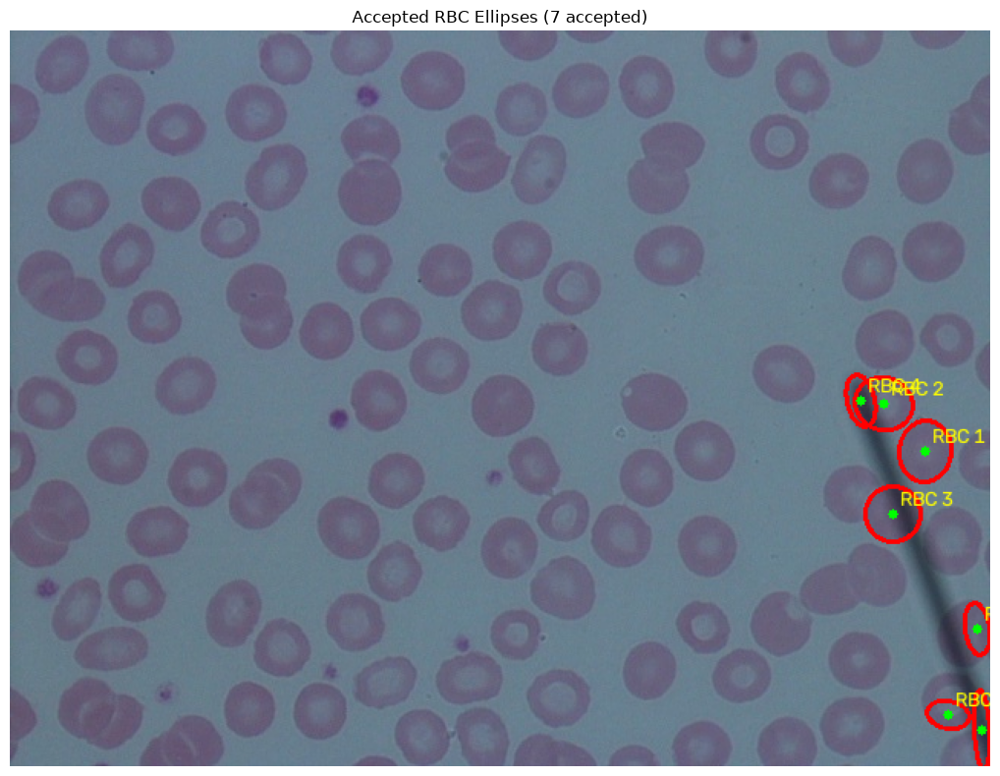

In [44]:
# ============================================================
# CELL 30 — Visualize Accepted Ellipses
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Create visualization image
# ------------------------------------------------------------

visualization = sample_image_rgb.copy()


# ------------------------------------------------------------
# Draw accepted ellipses
# ------------------------------------------------------------

for index, result in enumerate(
    accepted_ellipses
):

    properties = result["properties"]

    cx, cy = properties["center"]

    center = (
        int(round(cx)),
        int(round(cy))
    )


    major_radius = max(
        1,
        int(round(
            properties["major_axis"] / 2
        ))
    )

    minor_radius = max(
        1,
        int(round(
            properties["minor_axis"] / 2
        ))
    )


    axes = (
        major_radius,
        minor_radius
    )


    angle = properties["angle"]


    # --------------------------------------------------------
    # Draw ellipse
    # --------------------------------------------------------

    cv2.ellipse(
        visualization,
        center,
        axes,
        angle,
        0,
        360,
        (255, 0, 0),
        2
    )


    # --------------------------------------------------------
    # Draw center
    # --------------------------------------------------------

    cv2.circle(
        visualization,
        center,
        3,
        (0, 255, 0),
        -1
    )


    # --------------------------------------------------------
    # Add RBC number
    # --------------------------------------------------------

    cv2.putText(
        visualization,
        f"RBC {index + 1}",
        (
            center[0] + 5,
            center[1] - 5
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 255, 0),
        1,
        cv2.LINE_AA
    )


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

plt.imshow(
    visualization
)

plt.title(
    f"Accepted RBC Ellipses "
    f"({len(accepted_ellipses)} accepted)"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [45]:
# ============================================================
# CELL 31 — Accepted RBC Properties
# ============================================================

print("=" * 60)
print("ACCEPTED RBC ELLIPSES")
print("=" * 60)

print(
    "Total accepted RBCs:",
    len(accepted_ellipses)
)


for i, result in enumerate(
    accepted_ellipses
):

    properties = result["properties"]

    cx, cy = properties["center"]

    print()
    print(
        f"RBC {i + 1}"
    )

    print(
        f"  Curve ID   : "
        f"{result['curve_id'] + 1}"
    )

    print(
        f"  Center     : "
        f"({cx:.2f}, {cy:.2f})"
    )

    print(
        f"  Major axis : "
        f"{properties['major_axis']:.2f}"
    )

    print(
        f"  Minor axis : "
        f"{properties['minor_axis']:.2f}"
    )

    print(
        f"  Angle      : "
        f"{properties['angle']:.2f}"
    )

    print(
        f"  Area       : "
        f"{properties['area']:.2f}"
    )

ACCEPTED RBC ELLIPSES
Total accepted RBCs: 7

RBC 1
  Curve ID   : 54
  Center     : (597.29, 273.55)
  Major axis : 39.33
  Minor axis : 33.11
  Angle      : 96.04
  Area       : 1022.98

RBC 2
  Curve ID   : 59
  Center     : (569.99, 242.94)
  Major axis : 37.16
  Minor axis : 34.80
  Angle      : 16.66
  Area       : 1015.69

RBC 3
  Curve ID   : 12
  Center     : (576.49, 314.50)
  Major axis : 35.81
  Minor axis : 35.44
  Angle      : 16.07
  Area       : 996.90

RBC 4
  Curve ID   : 61
  Center     : (554.90, 240.92)
  Major axis : 34.42
  Minor axis : 17.20
  Angle      : 76.97
  Area       : 465.06

RBC 5
  Curve ID   : 28
  Center     : (633.80, 455.99)
  Major axis : 52.30
  Minor axis : 10.88
  Angle      : 86.93
  Area       : 446.80

RBC 6
  Curve ID   : 31
  Center     : (631.20, 389.55)
  Major axis : 33.43
  Minor axis : 16.94
  Angle      : 81.97
  Area       : 444.67

RBC 7
  Curve ID   : 19
  Center     : (612.34, 445.56)
  Major axis : 28.33
  Minor axis : 17.39
  

In [46]:
# ============================================================
# CELL 32 — Identify Remaining Curves
# ============================================================

# Curve IDs that produced accepted ellipses
accepted_curve_ids = {
    result["curve_id"]
    for result in accepted_ellipses
}


# ------------------------------------------------------------
# Curves that were successfully fitted but rejected
# ------------------------------------------------------------

fitted_rejected_curves = []

for result in ellipse_properties:

    curve_id = result["curve_id"]

    if curve_id not in accepted_curve_ids:

        fitted_rejected_curves.append(
            result
        )


# ------------------------------------------------------------
# Print information
# ------------------------------------------------------------

print("=" * 60)
print("REMAINING CURVES")
print("=" * 60)

print(
    "Accepted curves:",
    len(accepted_curve_ids)
)

print(
    "Rejected fitted curves:",
    len(fitted_rejected_curves)
)


print()
print("Rejected fitted curve IDs:")

for result in fitted_rejected_curves:

    print(
        f"Curve {result['curve_id'] + 1}"
        f" → {len(result['points'])} points"
    )

REMAINING CURVES
Accepted curves: 7
Rejected fitted curves: 9

Rejected fitted curve IDs:
Curve 2 → 22 points
Curve 5 → 83 points
Curve 18 → 33 points
Curve 37 → 51 points
Curve 39 → 24 points
Curve 40 → 33 points
Curve 49 → 20 points
Curve 51 → 27 points
Curve 55 → 20 points


In [47]:
# ============================================================
# CELL 33 — Prepare Two-Curve Combinations
# ============================================================

from itertools import combinations


# ------------------------------------------------------------
# Create list of remaining curves
# ------------------------------------------------------------

remaining_curves = [
    result
    for result in fitted_rejected_curves
]


# ------------------------------------------------------------
# Generate every possible pair
# ------------------------------------------------------------

two_curve_pairs = list(
    combinations(
        remaining_curves,
        2
    )
)


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("=" * 60)
print("TWO-CURVE FITTING")
print("=" * 60)

print(
    "Remaining curves:",
    len(remaining_curves)
)

print(
    "Possible two-curve combinations:",
    len(two_curve_pairs)
)


print()
print("Curve pairs:")

for curve_a, curve_b in two_curve_pairs:

    print(
        f"Curve {curve_a['curve_id'] + 1}"
        f" + "
        f"Curve {curve_b['curve_id'] + 1}"
    )

TWO-CURVE FITTING
Remaining curves: 9
Possible two-curve combinations: 36

Curve pairs:
Curve 2 + Curve 5
Curve 2 + Curve 18
Curve 2 + Curve 37
Curve 2 + Curve 39
Curve 2 + Curve 40
Curve 2 + Curve 49
Curve 2 + Curve 51
Curve 2 + Curve 55
Curve 5 + Curve 18
Curve 5 + Curve 37
Curve 5 + Curve 39
Curve 5 + Curve 40
Curve 5 + Curve 49
Curve 5 + Curve 51
Curve 5 + Curve 55
Curve 18 + Curve 37
Curve 18 + Curve 39
Curve 18 + Curve 40
Curve 18 + Curve 49
Curve 18 + Curve 51
Curve 18 + Curve 55
Curve 37 + Curve 39
Curve 37 + Curve 40
Curve 37 + Curve 49
Curve 37 + Curve 51
Curve 37 + Curve 55
Curve 39 + Curve 40
Curve 39 + Curve 49
Curve 39 + Curve 51
Curve 39 + Curve 55
Curve 40 + Curve 49
Curve 40 + Curve 51
Curve 40 + Curve 55
Curve 49 + Curve 51
Curve 49 + Curve 55
Curve 51 + Curve 55


In [48]:
# ============================================================
# CELL 34 — Combine Two Curves
# ============================================================

def combine_two_curves(curve_a, curve_b):
    """
    Combine the boundary points from two curves.

    Duplicate points are removed while preserving
    the available coordinate information.
    """

    points_a = np.asarray(
        curve_a["points"],
        dtype=np.int32
    )

    points_b = np.asarray(
        curve_b["points"],
        dtype=np.int32
    )


    # --------------------------------------------------------
    # Combine
    # --------------------------------------------------------

    combined = np.vstack(
        [
            points_a,
            points_b
        ]
    )


    # --------------------------------------------------------
    # Remove duplicate points
    # --------------------------------------------------------

    combined_unique = np.unique(
        combined,
        axis=0
    )


    return combined_unique


print(
    "Two-curve combination function loaded successfully."
)

Two-curve combination function loaded successfully.


In [49]:
# ============================================================
# CELL 35 — Test Two-Curve Combination
# ============================================================

# ------------------------------------------------------------
# Select the first pair
# ------------------------------------------------------------

curve_a, curve_b = two_curve_pairs[0]


# ------------------------------------------------------------
# Combine them
# ------------------------------------------------------------

test_combined_points = combine_two_curves(
    curve_a,
    curve_b
)


# ------------------------------------------------------------
# Print information
# ------------------------------------------------------------

print("=" * 60)
print("TWO-CURVE COMBINATION TEST")
print("=" * 60)

print(
    "Curve A:",
    curve_a["curve_id"] + 1
)

print(
    "Curve A points:",
    len(curve_a["points"])
)

print(
    "Curve B:",
    curve_b["curve_id"] + 1
)

print(
    "Curve B points:",
    len(curve_b["points"])
)

print(
    "Combined unique points:",
    len(test_combined_points)
)

print()
print(
    "Combined points shape:",
    test_combined_points.shape
)

TWO-CURVE COMBINATION TEST
Curve A: 2
Curve A points: 22
Curve B: 5
Curve B points: 83
Combined unique points: 105

Combined points shape: (105, 2)


In [50]:
# ============================================================
# CELL 36 — Fit Ellipses to All Two-Curve Combinations
# ============================================================

two_curve_ellipse_results = []


# ------------------------------------------------------------
# Process every possible pair
# ------------------------------------------------------------

for curve_a, curve_b in two_curve_pairs:

    # --------------------------------------------------------
    # Combine the two curves
    # --------------------------------------------------------

    combined_points = combine_two_curves(
        curve_a,
        curve_b
    )


    # --------------------------------------------------------
    # Need enough points for ellipse fitting
    # --------------------------------------------------------

    if len(combined_points) < 6:

        continue


    # --------------------------------------------------------
    # Fit ellipse using Fitzgibbon method
    # --------------------------------------------------------

    ellipse = fit_ellipse_fitzgibbon(
        combined_points
    )


    # --------------------------------------------------------
    # Skip if fitting failed
    # --------------------------------------------------------

    if ellipse is None:

        continue


    # --------------------------------------------------------
    # Convert ellipse parameters
    # --------------------------------------------------------

    properties = ellipse_parameters(
        ellipse
    )


    # --------------------------------------------------------
    # Skip invalid ellipse
    # --------------------------------------------------------

    if properties is None:

        continue


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    two_curve_ellipse_results.append({

        "curve_a":
            curve_a["curve_id"],

        "curve_b":
            curve_b["curve_id"],

        "points":
            combined_points,

        "parameters":
            ellipse,

        "properties":
            properties
    })


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("=" * 60)
print("TWO-CURVE ELLIPSE FITTING")
print("=" * 60)

print(
    "Total curve pairs:",
    len(two_curve_pairs)
)

print(
    "Successfully fitted ellipses:",
    len(two_curve_ellipse_results)
)


# ------------------------------------------------------------
# Display fitted candidates
# ------------------------------------------------------------

for result in two_curve_ellipse_results:

    properties = result["properties"]

    print()

    print(
        f"Curves "
        f"{result['curve_a'] + 1} + "
        f"{result['curve_b'] + 1}"
    )

    print(
        f"  Major axis: "
        f"{properties['major_axis']:.2f}"
    )

    print(
        f"  Minor axis: "
        f"{properties['minor_axis']:.2f}"
    )

    print(
        f"  Area: "
        f"{properties['area']:.2f}"
    )

TWO-CURVE ELLIPSE FITTING
Total curve pairs: 36
Successfully fitted ellipses: 36

Curves 2 + 5
  Major axis: 49.60
  Minor axis: 26.03
  Area: 1014.12

Curves 2 + 18
  Major axis: 174.70
  Minor axis: 33.92
  Area: 4653.94

Curves 2 + 37
  Major axis: 159.59
  Minor axis: 54.84
  Area: 6874.16

Curves 2 + 39
  Major axis: 77.18
  Minor axis: 22.33
  Area: 1353.29

Curves 2 + 40
  Major axis: 77.91
  Minor axis: 22.72
  Area: 1390.47

Curves 2 + 49
  Major axis: 78.38
  Minor axis: 9.95
  Area: 612.60

Curves 2 + 51
  Major axis: 65.15
  Minor axis: 12.27
  Area: 627.87

Curves 2 + 55
  Major axis: 43.65
  Minor axis: 21.82
  Area: 747.85

Curves 5 + 18
  Major axis: 157.56
  Minor axis: 36.14
  Area: 4472.30

Curves 5 + 37
  Major axis: 110.20
  Minor axis: 43.03
  Area: 3724.53

Curves 5 + 39
  Major axis: 88.92
  Minor axis: 39.14
  Area: 2733.52

Curves 5 + 40
  Major axis: 84.45
  Minor axis: 38.55
  Area: 2557.09

Curves 5 + 49
  Major axis: 76.55
  Minor axis: 36.25
  Area: 2179.

In [51]:
# ============================================================
# CELL 37 — Verify Two-Curve Ellipses
# ============================================================

verified_two_curve_ellipses = []

rejected_two_curve_ellipses = []


# ------------------------------------------------------------
# Verify every two-curve candidate
# ------------------------------------------------------------

for result in two_curve_ellipse_results:

    properties = result["properties"]


    # --------------------------------------------------------
    # Create ellipse mask
    # --------------------------------------------------------

    ellipse_mask = create_ellipse_mask(
        sample_image_rgb.shape,
        properties
    )


    ellipse_pixels = np.count_nonzero(
        ellipse_mask
    )


    if ellipse_pixels == 0:

        continue


    # --------------------------------------------------------
    # Criterion 1
    #
    # At least 80% of ellipse must be inside
    # the original overlapping contour.
    # --------------------------------------------------------

    inside_pixels = np.count_nonzero(
        (
            ellipse_mask > 0
        )
        &
        (
            original_contour_mask > 0
        )
    )


    inside_ratio = (
        inside_pixels
        / ellipse_pixels
    )


    # --------------------------------------------------------
    # Criterion 2
    #
    # At least 20% must be new area.
    #
    # Here we compare against the ellipses that were
    # already accepted from single curves.
    # --------------------------------------------------------

    if len(accepted_masks) == 0:

        previous_mask = np.zeros(
            sample_image_rgb.shape[:2],
            dtype=np.uint8
        )

    else:

        previous_mask = np.zeros(
            sample_image_rgb.shape[:2],
            dtype=np.uint8
        )

        for mask in accepted_masks:

            previous_mask = cv2.bitwise_or(
                previous_mask,
                mask
            )


    new_pixels = np.count_nonzero(
        (
            ellipse_mask > 0
        )
        &
        (
            previous_mask == 0
        )
    )


    new_area_ratio = (
        new_pixels
        / ellipse_pixels
    )


    # --------------------------------------------------------
    # Criterion 3
    #
    # Minimum ellipse size
    # --------------------------------------------------------

    area = properties["area"]

    size_ok = (
        area >= MIN_ELLIPSE_AREA
    )


    # --------------------------------------------------------
    # Final decision
    # --------------------------------------------------------

    accepted = (
        inside_ratio >= MIN_INSIDE_RATIO
        and
        new_area_ratio >= MIN_NEW_AREA_RATIO
        and
        size_ok
    )


    # --------------------------------------------------------
    # Determine rejection reason
    # --------------------------------------------------------

    if accepted:

        reason = "Accepted"

    elif inside_ratio < MIN_INSIDE_RATIO:

        reason = "Less than 80% inside contour"

    elif new_area_ratio < MIN_NEW_AREA_RATIO:

        reason = "Less than 20% new area"

    elif not size_ok:

        reason = "Ellipse too small"

    else:

        reason = "Failed verification"


    # --------------------------------------------------------
    # Store verification information
    # --------------------------------------------------------

    result["verification"] = {

        "accepted": accepted,

        "reason": reason,

        "ellipse_mask": ellipse_mask,

        "inside_ratio": inside_ratio,

        "new_area_ratio": new_area_ratio,

        "area": area
    }


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    if accepted:

        verified_two_curve_ellipses.append(
            result
        )

    else:

        rejected_two_curve_ellipses.append(
            result
        )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 60)
print("TWO-CURVE ELLIPSE VERIFICATION")
print("=" * 60)

print(
    "Two-curve candidates:",
    len(two_curve_ellipse_results)
)

print(
    "Accepted:",
    len(verified_two_curve_ellipses)
)

print(
    "Rejected:",
    len(rejected_two_curve_ellipses)
)


# ------------------------------------------------------------
# Detailed results
# ------------------------------------------------------------

print()
print("Detailed verification:")
print("-" * 60)


for result in two_curve_ellipse_results:

    properties = result["properties"]

    verification = result["verification"]


    print()

    print(
        f"Curves "
        f"{result['curve_a'] + 1} + "
        f"{result['curve_b'] + 1}"
    )

    print(
        f"Area: "
        f"{properties['area']:.2f}"
    )

    print(
        f"Inside contour: "
        f"{verification['inside_ratio'] * 100:.2f}%"
    )

    print(
        f"New area: "
        f"{verification['new_area_ratio'] * 100:.2f}%"
    )

    print(
        f"Accepted: "
        f"{verification['accepted']}"
    )

    if not verification["accepted"]:

        print(
            f"Reason: "
            f"{verification['reason']}"
        )

TWO-CURVE ELLIPSE VERIFICATION
Two-curve candidates: 36
Accepted: 4
Rejected: 32

Detailed verification:
------------------------------------------------------------

Curves 2 + 5
Area: 1014.12
Inside contour: 63.64%
New area: 100.00%
Accepted: False
Reason: Less than 80% inside contour

Curves 2 + 18
Area: 4653.94
Inside contour: 30.07%
New area: 84.56%
Accepted: False
Reason: Less than 80% inside contour

Curves 2 + 37
Area: 6874.16
Inside contour: 57.93%
New area: 60.52%
Accepted: False
Reason: Less than 80% inside contour

Curves 2 + 39
Area: 1353.29
Inside contour: 62.75%
New area: 75.56%
Accepted: False
Reason: Less than 80% inside contour

Curves 2 + 40
Area: 1390.47
Inside contour: 67.69%
New area: 75.38%
Accepted: False
Reason: Less than 80% inside contour

Curves 2 + 49
Area: 612.60
Inside contour: 92.32%
New area: 61.45%
Accepted: True

Curves 2 + 51
Area: 627.87
Inside contour: 96.91%
New area: 64.51%
Accepted: True

Curves 2 + 55
Area: 747.85
Inside contour: 75.89%
New are

In [52]:
# ============================================================
# CELL 38 — Combine Final Accepted Ellipses
# ============================================================

final_ellipses = []

# ------------------------------------------------------------
# Add accepted single-curve ellipses
# ------------------------------------------------------------

for result in accepted_ellipses:

    final_ellipses.append(
        result
    )


# ------------------------------------------------------------
# Add accepted two-curve ellipses
# ------------------------------------------------------------

for result in verified_two_curve_ellipses:

    final_ellipses.append(
        result
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 60)
print("FINAL RBC ELLIPSES")
print("=" * 60)

print(
    "Single-curve accepted:",
    len(accepted_ellipses)
)

print(
    "Two-curve accepted:",
    len(verified_two_curve_ellipses)
)

print(
    "TOTAL FINAL ELLIPSES:",
    len(final_ellipses)
)

FINAL RBC ELLIPSES
Single-curve accepted: 7
Two-curve accepted: 4
TOTAL FINAL ELLIPSES: 11


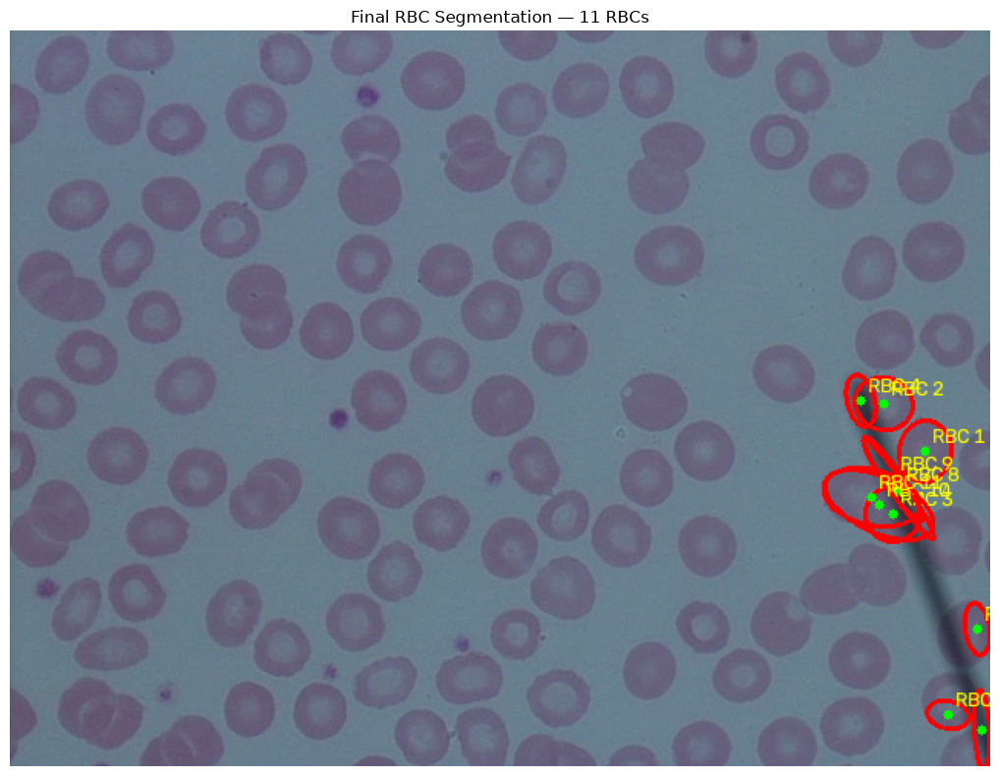

In [53]:
# ============================================================
# CELL 39 — Visualize Final RBC Segmentation
# ============================================================

final_visualization = sample_image_rgb.copy()

for index, result in enumerate(final_ellipses):

    properties = result["properties"]

    cx, cy = properties["center"]

    center = (
        int(round(cx)),
        int(round(cy))
    )

    axes = (
        max(1, int(round(
            properties["major_axis"] / 2
        ))),
        max(1, int(round(
            properties["minor_axis"] / 2
        )))
    )

    angle = properties["angle"]

    # Draw ellipse
    cv2.ellipse(
        final_visualization,
        center,
        axes,
        angle,
        0,
        360,
        (255, 0, 0),
        2
    )

    # Draw center
    cv2.circle(
        final_visualization,
        center,
        3,
        (0, 255, 0),
        -1
    )

    # RBC number
    cv2.putText(
        final_visualization,
        f"RBC {index + 1}",
        (
            center[0] + 5,
            center[1] - 5
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 255, 0),
        1,
        cv2.LINE_AA
    )


plt.figure(figsize=(12, 8))

plt.imshow(final_visualization)

plt.title(
    f"Final RBC Segmentation — "
    f"{len(final_ellipses)} RBCs"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [54]:
# ============================================================
# CELL 40 — Final Segmentation Summary
# ============================================================

print("=" * 60)
print("FINAL SEGMENTATION SUMMARY")
print("=" * 60)

print(
    "Original contour curves:",
    len(curves)
)

print(
    "Single-curve accepted:",
    len(accepted_ellipses)
)

print(
    "Two-curve accepted:",
    len(verified_two_curve_ellipses)
)

print(
    "Final detected RBCs:",
    len(final_ellipses)
)

print()

print("RBC details:")
print("-" * 60)

for i, result in enumerate(final_ellipses):

    properties = result["properties"]

    cx, cy = properties["center"]

    print(
        f"RBC {i + 1:02d} | "
        f"Center=({cx:.1f}, {cy:.1f}) | "
        f"Major={properties['major_axis']:.2f} | "
        f"Minor={properties['minor_axis']:.2f} | "
        f"Area={properties['area']:.2f}"
    )

FINAL SEGMENTATION SUMMARY
Original contour curves: 61
Single-curve accepted: 7
Two-curve accepted: 4
Final detected RBCs: 11

RBC details:
------------------------------------------------------------
RBC 01 | Center=(597.3, 273.5) | Major=39.33 | Minor=33.11 | Area=1022.98
RBC 02 | Center=(570.0, 242.9) | Major=37.16 | Minor=34.80 | Area=1015.69
RBC 03 | Center=(576.5, 314.5) | Major=35.81 | Minor=35.44 | Area=996.90
RBC 04 | Center=(554.9, 240.9) | Major=34.42 | Minor=17.20 | Area=465.06
RBC 05 | Center=(633.8, 456.0) | Major=52.30 | Minor=10.88 | Area=446.80
RBC 06 | Center=(631.2, 389.6) | Major=33.43 | Minor=16.94 | Area=444.67
RBC 07 | Center=(612.3, 445.6) | Major=28.33 | Minor=17.39 | Area=386.89
RBC 08 | Center=(580.1, 299.5) | Major=78.38 | Minor=9.95 | Area=612.60
RBC 09 | Center=(576.4, 292.1) | Major=65.15 | Minor=12.27 | Area=627.87
RBC 10 | Center=(566.8, 308.9) | Major=76.55 | Minor=36.25 | Area=2179.30
RBC 11 | Center=(562.0, 304.2) | Major=63.93 | Minor=35.51 | Area=1

In [55]:
# ============================================================
# CELL 41 — Remove Duplicate / Highly Overlapping Ellipses
# ============================================================

def calculate_mask_iou(mask_a, mask_b):
    """
    Calculate Intersection over Union (IoU)
    between two binary masks.
    """

    mask_a = mask_a > 0
    mask_b = mask_b > 0

    intersection = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    union = np.logical_or(
        mask_a,
        mask_b
    ).sum()

    if union == 0:
        return 0.0

    return intersection / union


# ------------------------------------------------------------
# Create masks for all final ellipses
# ------------------------------------------------------------

ellipse_items = []

for result in final_ellipses:

    properties = result["properties"]

    mask = create_ellipse_mask(
        sample_image_rgb.shape,
        properties
    )

    ellipse_items.append({
        "result": result,
        "mask": mask,
        "area": properties["area"]
    })


# ------------------------------------------------------------
# Sort by ellipse area
# Larger, more complete ellipses are considered first.
# ------------------------------------------------------------

ellipse_items.sort(
    key=lambda x: x["area"],
    reverse=True
)


# ------------------------------------------------------------
# Remove highly overlapping ellipses
# ------------------------------------------------------------

IOU_THRESHOLD = 0.50

deduplicated_ellipses = []


for candidate in ellipse_items:

    candidate_mask = candidate["mask"]

    duplicate = False

    for accepted in deduplicated_ellipses:

        accepted_mask = accepted["mask"]

        iou = calculate_mask_iou(
            candidate_mask,
            accepted_mask
        )

        if iou >= IOU_THRESHOLD:

            duplicate = True
            break


    if not duplicate:

        deduplicated_ellipses.append(
            candidate
        )


# ------------------------------------------------------------
# Extract final results
# ------------------------------------------------------------

final_unique_ellipses = [
    item["result"]
    for item in deduplicated_ellipses
]


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 60)
print("ELLIPSE DEDUPLICATION")
print("=" * 60)

print(
    "Before deduplication:",
    len(final_ellipses)
)

print(
    "After deduplication:",
    len(final_unique_ellipses)
)

print(
    "Removed:",
    len(final_ellipses)
    -
    len(final_unique_ellipses)
)

ELLIPSE DEDUPLICATION
Before deduplication: 11
After deduplication: 9
Removed: 2


In [56]:
# ============================================================
# CELL 42 — Inspect Unique RBC Ellipses
# ============================================================

print("=" * 60)
print("UNIQUE RBC ELLIPSES")
print("=" * 60)

for i, result in enumerate(
    final_unique_ellipses
):

    properties = result["properties"]

    cx, cy = properties["center"]

    print(
        f"RBC {i + 1:02d} | "
        f"Center=({cx:.1f}, {cy:.1f}) | "
        f"Major={properties['major_axis']:.2f} | "
        f"Minor={properties['minor_axis']:.2f} | "
        f"Area={properties['area']:.2f}"
    )

UNIQUE RBC ELLIPSES
RBC 01 | Center=(566.8, 308.9) | Major=76.55 | Minor=36.25 | Area=2179.30
RBC 02 | Center=(597.3, 273.5) | Major=39.33 | Minor=33.11 | Area=1022.98
RBC 03 | Center=(570.0, 242.9) | Major=37.16 | Minor=34.80 | Area=1015.69
RBC 04 | Center=(576.5, 314.5) | Major=35.81 | Minor=35.44 | Area=996.90
RBC 05 | Center=(576.4, 292.1) | Major=65.15 | Minor=12.27 | Area=627.87
RBC 06 | Center=(554.9, 240.9) | Major=34.42 | Minor=17.20 | Area=465.06
RBC 07 | Center=(633.8, 456.0) | Major=52.30 | Minor=10.88 | Area=446.80
RBC 08 | Center=(631.2, 389.6) | Major=33.43 | Minor=16.94 | Area=444.67
RBC 09 | Center=(612.3, 445.6) | Major=28.33 | Minor=17.39 | Area=386.89


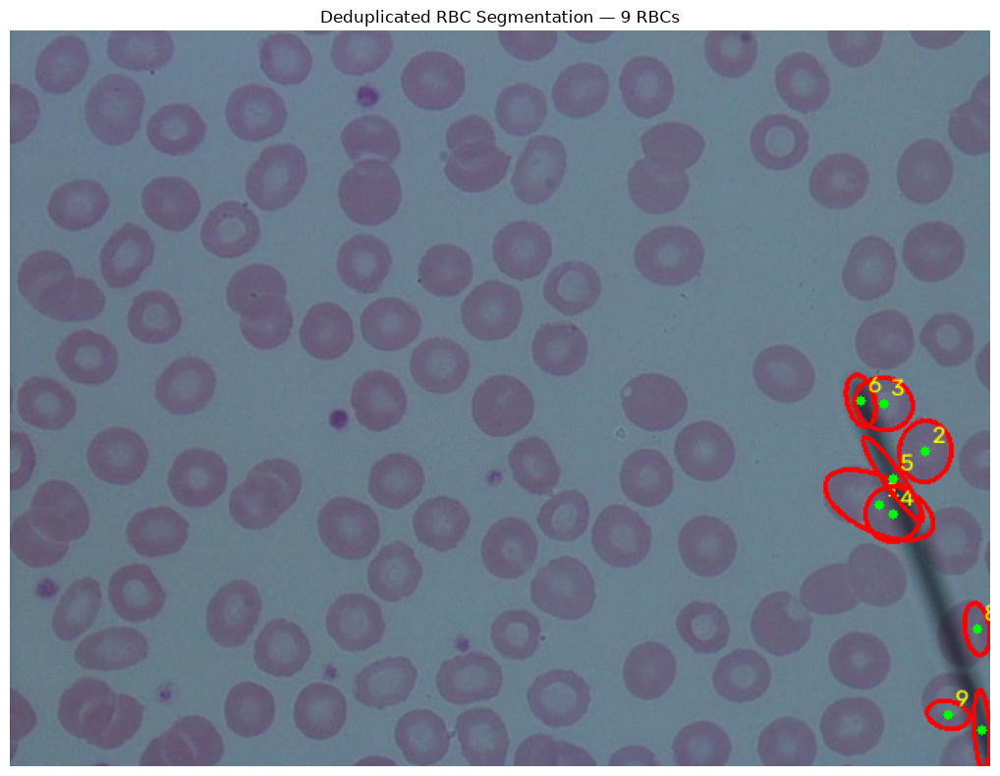

In [57]:
# ============================================================
# CELL 43 — Visualize Deduplicated RBCs
# ============================================================

unique_visualization = sample_image_rgb.copy()


for index, result in enumerate(
    final_unique_ellipses
):

    properties = result["properties"]

    cx, cy = properties["center"]

    center = (
        int(round(cx)),
        int(round(cy))
    )

    axes = (
        max(
            1,
            int(round(
                properties["major_axis"] / 2
            ))
        ),
        max(
            1,
            int(round(
                properties["minor_axis"] / 2
            ))
        )
    )

    angle = properties["angle"]


    # --------------------------------------------------------
    # Draw ellipse
    # --------------------------------------------------------

    cv2.ellipse(
        unique_visualization,
        center,
        axes,
        angle,
        0,
        360,
        (255, 0, 0),
        2
    )


    # --------------------------------------------------------
    # Draw center
    # --------------------------------------------------------

    cv2.circle(
        unique_visualization,
        center,
        3,
        (0, 255, 0),
        -1
    )


    # --------------------------------------------------------
    # Draw RBC number
    # --------------------------------------------------------

    cv2.putText(
        unique_visualization,
        f"{index + 1}",
        (
            center[0] + 5,
            center[1] - 5
        ),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 0),
        1,
        cv2.LINE_AA
    )


plt.figure(
    figsize=(12, 8)
)

plt.imshow(
    unique_visualization
)

plt.title(
    f"Deduplicated RBC Segmentation — "
    f"{len(final_unique_ellipses)} RBCs"
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [58]:
# ============================================================
# CELL 44 — Final RBC Overlap Analysis
# ============================================================

print("=" * 60)
print("FINAL RBC OVERLAP ANALYSIS")
print("=" * 60)

print(
    "Final unique ellipses:",
    len(final_unique_ellipses)
)

print()


# ------------------------------------------------------------
# Calculate pairwise IoU
# ------------------------------------------------------------

for i in range(
    len(deduplicated_ellipses)
):

    for j in range(
        i + 1,
        len(deduplicated_ellipses)
    ):

        mask_i = deduplicated_ellipses[i]["mask"]
        mask_j = deduplicated_ellipses[j]["mask"]

        iou = calculate_mask_iou(
            mask_i,
            mask_j
        )

        if iou > 0.20:

            result_i = (
                deduplicated_ellipses[i]["result"]
            )

            result_j = (
                deduplicated_ellipses[j]["result"]
            )

            print(
                f"RBC {i + 1} ↔ RBC {j + 1}"
            )

            print(
                f"  IoU: {iou:.3f}"
            )

            print(
                f"  Area A: "
                f"{result_i['properties']['area']:.2f}"
            )

            print(
                f"  Area B: "
                f"{result_j['properties']['area']:.2f}"
            )

            print()

FINAL RBC OVERLAP ANALYSIS
Final unique ellipses: 9

RBC 1 ↔ RBC 4
  IoU: 0.456
  Area A: 2179.30
  Area B: 996.90

RBC 3 ↔ RBC 6
  IoU: 0.231
  Area A: 1015.69
  Area B: 465.06



In [59]:
# ============================================================
# CELL 45 — Ellipse Shape Quality Check
# ============================================================

print("=" * 60)
print("ELLIPSE SHAPE QUALITY")
print("=" * 60)


for i, result in enumerate(
    final_unique_ellipses
):

    properties = result["properties"]

    major = properties["major_axis"]
    minor = properties["minor_axis"]

    if minor > 0:

        aspect_ratio = (
            major / minor
        )

    else:

        aspect_ratio = float("inf")


    print()

    print(
        f"RBC {i + 1}"
    )

    print(
        f"  Major axis : {major:.2f}"
    )

    print(
        f"  Minor axis : {minor:.2f}"
    )

    print(
        f"  Aspect ratio: "
        f"{aspect_ratio:.2f}"
    )

    print(
        f"  Area       : "
        f"{properties['area']:.2f}"
    )

ELLIPSE SHAPE QUALITY

RBC 1
  Major axis : 76.55
  Minor axis : 36.25
  Aspect ratio: 2.11
  Area       : 2179.30

RBC 2
  Major axis : 39.33
  Minor axis : 33.11
  Aspect ratio: 1.19
  Area       : 1022.98

RBC 3
  Major axis : 37.16
  Minor axis : 34.80
  Aspect ratio: 1.07
  Area       : 1015.69

RBC 4
  Major axis : 35.81
  Minor axis : 35.44
  Aspect ratio: 1.01
  Area       : 996.90

RBC 5
  Major axis : 65.15
  Minor axis : 12.27
  Aspect ratio: 5.31
  Area       : 627.87

RBC 6
  Major axis : 34.42
  Minor axis : 17.20
  Aspect ratio: 2.00
  Area       : 465.06

RBC 7
  Major axis : 52.30
  Minor axis : 10.88
  Aspect ratio: 4.81
  Area       : 446.80

RBC 8
  Major axis : 33.43
  Minor axis : 16.94
  Aspect ratio: 1.97
  Area       : 444.67

RBC 9
  Major axis : 28.33
  Minor axis : 17.39
  Aspect ratio: 1.63
  Area       : 386.89


In [61]:
# ============================================================
# CELL 46 — Match Detected RBCs With Ground-Truth Labels
# ============================================================

import math


# ------------------------------------------------------------
# RBC class names
# ------------------------------------------------------------

CLASS_NAMES = {
    0: "Normal cell",
    1: "Macrocyte",
    2: "Microcyte",
    3: "Spherocyte",
    4: "Target cell",
    5: "Stomatocyte",
    6: "Ovalocyte",
    7: "Teardrop",
    8: "Burr cell",
    9: "Schistocyte",
    10: "Uncategorized",
    11: "Hypochromia"
}


# ------------------------------------------------------------
# Check annotation format
# ------------------------------------------------------------

print("=" * 60)
print("CHECKING ANNOTATION FORMAT")
print("=" * 60)

print("Annotation type:", type(annotations))

if len(annotations) > 0:
    print("First annotation:", annotations[0])
    print("First annotation type:", type(annotations[0]))

print()


# ------------------------------------------------------------
# Convert annotations into standard format
# ------------------------------------------------------------

ground_truth = []


for annotation in annotations:

    # --------------------------------------------------------
    # CASE 1: annotation is a dictionary
    # --------------------------------------------------------

    if isinstance(annotation, dict):

        # Try common possible dictionary keys
        if all(
            key in annotation
            for key in ["x", "y", "class_id"]
        ):

            x = int(annotation["x"])
            y = int(annotation["y"])
            class_id = int(annotation["class_id"])

        elif all(
            key in annotation
            for key in ["x", "y", "class"]
        ):

            x = int(annotation["x"])
            y = int(annotation["y"])
            class_id = int(annotation["class"])

        else:

            print(
                "Unknown annotation dictionary:",
                annotation
            )

            continue


    # --------------------------------------------------------
    # CASE 2: annotation is list / tuple / NumPy array
    # --------------------------------------------------------

    else:

        x = int(annotation[0])
        y = int(annotation[1])
        class_id = int(annotation[2])


    # --------------------------------------------------------
    # Store standardized annotation
    # --------------------------------------------------------

    ground_truth.append({

        "x": x,

        "y": y,

        "class_id": class_id
    })


print("Total ground-truth annotations:",
      len(ground_truth))

print()

print("First 5 standardized annotations:")

for item in ground_truth[:5]:

    print(item)

CHECKING ANNOTATION FORMAT
Annotation type: <class 'list'>
First annotation: {'x': 594, 'y': 95, 'class_id': 0, 'class_name': 'Normal cell'}
First annotation type: <class 'dict'>

Total ground-truth annotations: 117

First 5 standardized annotations:
{'x': 594, 'y': 95, 'class_id': 0}
{'x': 601, 'y': 151, 'class_id': 0}
{'x': 556, 'y': 153, 'class_id': 0}
{'x': 548, 'y': 99, 'class_id': 0}
{'x': 508, 'y': 77, 'class_id': 0}


In [62]:
# ============================================================
# CELL 47 — Match Detected RBCs With Ground Truth
# ============================================================

MATCH_DISTANCE_THRESHOLD = 25

matched_detections = []

used_annotations = set()


for detection_index, result in enumerate(
    final_unique_ellipses
):

    properties = result["properties"]

    cx, cy = properties["center"]

    best_index = None
    best_distance = float("inf")


    # --------------------------------------------------------
    # Find nearest unused ground-truth annotation
    # --------------------------------------------------------

    for annotation_index, gt in enumerate(
        ground_truth
    ):

        if annotation_index in used_annotations:
            continue


        dx = cx - gt["x"]
        dy = cy - gt["y"]

        distance = math.sqrt(
            dx ** 2 + dy ** 2
        )


        if distance < best_distance:

            best_distance = distance
            best_index = annotation_index


    # --------------------------------------------------------
    # Check whether distance is acceptable
    # --------------------------------------------------------

    if (
        best_index is not None
        and
        best_distance <= MATCH_DISTANCE_THRESHOLD
    ):

        gt = ground_truth[best_index]

        used_annotations.add(best_index)

        matched = True

        class_id = gt["class_id"]

        class_name = CLASS_NAMES.get(
            class_id,
            "Unknown"
        )

    else:

        matched = False

        class_id = None

        class_name = "No match"


    # --------------------------------------------------------
    # Save result
    # --------------------------------------------------------

    matched_detections.append({

        "detection_id":
            detection_index + 1,

        "center_x":
            cx,

        "center_y":
            cy,

        "distance":
            best_distance,

        "matched":
            matched,

        "class_id":
            class_id,

        "class_name":
            class_name,

        "result":
            result
    })


# ------------------------------------------------------------
# Print matching results
# ------------------------------------------------------------

print("=" * 60)
print("DETECTED RBC ↔ GROUND TRUTH")
print("=" * 60)


for item in matched_detections:

    print()

    print(
        f"RBC {item['detection_id']}"
    )

    print(
        f"  Center: "
        f"({item['center_x']:.2f}, "
        f"{item['center_y']:.2f})"
    )

    print(
        f"  Distance: "
        f"{item['distance']:.2f}"
    )

    print(
        f"  Matched: "
        f"{item['matched']}"
    )

    print(
        f"  Class ID: "
        f"{item['class_id']}"
    )

    print(
        f"  Class: "
        f"{item['class_name']}"
    )

DETECTED RBC ↔ GROUND TRUTH

RBC 1
  Center: (566.81, 308.92)
  Distance: 14.07
  Matched: True
  Class ID: 0
  Class: Normal cell

RBC 2
  Center: (597.29, 273.55)
  Distance: 4.45
  Matched: True
  Class ID: 0
  Class: Normal cell

RBC 3
  Center: (569.99, 242.94)
  Distance: 10.28
  Matched: True
  Class ID: 0
  Class: Normal cell

RBC 4
  Center: (576.49, 314.50)
  Distance: 39.80
  Matched: False
  Class ID: None
  Class: No match

RBC 5
  Center: (576.36, 292.08)
  Distance: 33.37
  Matched: False
  Class ID: None
  Class: No match

RBC 6
  Center: (554.90, 240.92)
  Distance: 43.55
  Matched: False
  Class ID: None
  Class: No match

RBC 7
  Center: (633.80, 455.99)
  Distance: 33.54
  Matched: False
  Class ID: None
  Class: No match

RBC 8
  Center: (631.20, 389.55)
  Distance: 6.56
  Matched: True
  Class ID: 0
  Class: Normal cell

RBC 9
  Center: (612.34, 445.56)
  Distance: 11.85
  Matched: True
  Class ID: 0
  Class: Normal cell


In [63]:
# ============================================================
# CELL 48 — Detection Matching Rate
# ============================================================

total_detected = len(
    matched_detections
)

matched_count = sum(
    item["matched"]
    for item in matched_detections
)

unmatched_count = (
    total_detected - matched_count
)


if total_detected > 0:

    matching_rate = (
        matched_count /
        total_detected
    ) * 100

else:

    matching_rate = 0.0


print("=" * 60)
print("SEGMENTATION VALIDATION")
print("=" * 60)

print(
    "Total detected RBCs :",
    total_detected
)

print(
    "Matched RBCs         :",
    matched_count
)

print(
    "Unmatched RBCs       :",
    unmatched_count
)

print(
    f"Matching rate        : "
    f"{matching_rate:.2f}%"
)

SEGMENTATION VALIDATION
Total detected RBCs : 9
Matched RBCs         : 5
Unmatched RBCs       : 4
Matching rate        : 55.56%


In [64]:
# ============================================================
# CELL 49 — BUILD RBC CLASSIFICATION DATASET
# ============================================================

from pathlib import Path
import cv2
import numpy as np


# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

CLASS_NAMES = {
    0: "Normal",
    1: "Macrocyte",
    2: "Microcyte",
    3: "Spherocyte",
    4: "Target_Cell",
    5: "Stomatocyte",
    6: "Ovalocyte",
    7: "Teardrop",
    8: "Burr_Cell",
    9: "Schistocyte",
    10: "Uncategorized",
    11: "Hypochromia"
}


# ------------------------------------------------------------
# Crop size
# ------------------------------------------------------------

CROP_SIZE = 72

HALF_SIZE = CROP_SIZE // 2


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

RBC_CROP_DIR = PROJECT_ROOT / "data" / "rbc_crops"


RBC_CROP_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Create class folders
# ------------------------------------------------------------

for class_id, class_name in CLASS_NAMES.items():

    class_folder = (
        RBC_CROP_DIR /
        f"{class_id}_{class_name}"
    )

    class_folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 60)
print("RBC CROP DATASET SETUP")
print("=" * 60)

print(
    "Output directory:",
    RBC_CROP_DIR
)

print(
    "Crop size:",
    CROP_SIZE,
    "x",
    CROP_SIZE
)

RBC CROP DATASET SETUP
Output directory: c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_crops
Crop size: 72 x 72


In [65]:
# ============================================================
# CELL 50 — EXTRACT ALL LABELED RBC CROPS
# ============================================================

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Counters
# ------------------------------------------------------------

total_images_processed = 0
total_annotations = 0
total_crops_saved = 0

skipped_images = 0
skipped_annotations = 0


# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

class_counts = {
    class_id: 0
    for class_id in CLASS_NAMES
}


# ------------------------------------------------------------
# Process every label file
# ------------------------------------------------------------

label_files = sorted(
    LABEL_DIR.glob("*.txt"),
    key=lambda p: int(p.stem)
)


print("=" * 60)
print("EXTRACTING RBC CROPS")
print("=" * 60)

print(
    "Label files found:",
    len(label_files)
)

print(
    "Crop size:",
    f"{CROP_SIZE} x {CROP_SIZE}"
)

print()


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------

for label_file in tqdm(
    label_files,
    desc="Processing images"
):

    image_file = (
        IMAGE_DIR /
        f"{label_file.stem}.jpg"
    )


    # --------------------------------------------------------
    # Check corresponding image
    # --------------------------------------------------------

    if not image_file.exists():

        skipped_images += 1

        continue


    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image = cv2.imread(
        str(image_file)
    )


    if image is None:

        skipped_images += 1

        continue


    total_images_processed += 1


    height, width = image.shape[:2]


    # --------------------------------------------------------
    # Read annotations
    # --------------------------------------------------------

    with open(
        label_file,
        "r",
        encoding="utf-8"
    ) as f:

        lines = f.readlines()


    # --------------------------------------------------------
    # Process each RBC annotation
    # --------------------------------------------------------

    for annotation_number, line in enumerate(lines):

        line = line.strip()


        if not line:
            continue


        parts = line.split()


        # Expected format:
        #
        # x y class_id
        #
        # Example:
        #
        # 594 95 0
        # ----------------------------------------------------

        if len(parts) < 3:

            skipped_annotations += 1

            continue


        try:

            x = int(float(parts[0]))
            y = int(float(parts[1]))
            class_id = int(float(parts[2]))

        except ValueError:

            skipped_annotations += 1

            continue


        # ----------------------------------------------------
        # Check class
        # ----------------------------------------------------

        if class_id not in CLASS_NAMES:

            skipped_annotations += 1

            continue


        total_annotations += 1


        # ----------------------------------------------------
        # Calculate crop coordinates
        # ----------------------------------------------------

        x1 = x - HALF_SIZE
        y1 = y - HALF_SIZE

        x2 = x + HALF_SIZE
        y2 = y + HALF_SIZE


        # ----------------------------------------------------
        # Skip crops touching image boundaries
        # ----------------------------------------------------

        if (
            x1 < 0
            or
            y1 < 0
            or
            x2 > width
            or
            y2 > height
        ):

            skipped_annotations += 1

            continue


        # ----------------------------------------------------
        # Extract crop
        # ----------------------------------------------------

        crop = image[
            y1:y2,
            x1:x2
        ]


        # ----------------------------------------------------
        # Verify crop size
        # ----------------------------------------------------

        if crop.shape[0] != CROP_SIZE:

            skipped_annotations += 1

            continue


        if crop.shape[1] != CROP_SIZE:

            skipped_annotations += 1

            continue


        # ----------------------------------------------------
        # Class output directory
        # ----------------------------------------------------

        class_folder = (
            RBC_CROP_DIR /
            f"{class_id}_{CLASS_NAMES[class_id]}"
        )


        # ----------------------------------------------------
        # Create unique filename
        # ----------------------------------------------------

        filename = (
            f"{label_file.stem}"
            f"_rbc_{annotation_number + 1}"
            f"_class_{class_id}.png"
        )


        output_path = (
            class_folder /
            filename
        )


        # ----------------------------------------------------
        # Save crop
        # ----------------------------------------------------

        success = cv2.imwrite(
            str(output_path),
            crop
        )


        if success:

            total_crops_saved += 1

            class_counts[class_id] += 1

        else:

            skipped_annotations += 1


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print()
print("=" * 60)
print("RBC CROP EXTRACTION COMPLETE")
print("=" * 60)

print(
    "Images processed:",
    total_images_processed
)

print(
    "Valid annotations:",
    total_annotations
)

print(
    "Crops saved:",
    total_crops_saved
)

print(
    "Skipped images:",
    skipped_images
)

print(
    "Skipped annotations:",
    skipped_annotations
)


# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

print()
print("CLASS DISTRIBUTION")
print("-" * 60)

for class_id, class_name in CLASS_NAMES.items():

    print(
        f"{class_id:2d} | "
        f"{class_name:15s} | "
        f"{class_counts[class_id]}"
    )

c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


EXTRACTING RBC CROPS
Label files found: 591
Crop size: 72 x 72



Processing images: 100%|██████████| 591/591 [00:39<00:00, 14.94it/s]


RBC CROP EXTRACTION COMPLETE
Images processed: 591
Valid annotations: 21054
Crops saved: 17707
Skipped images: 0
Skipped annotations: 3347

CLASS DISTRIBUTION
------------------------------------------------------------
 0 | Normal          | 5200
 1 | Macrocyte       | 641
 2 | Microcyte       | 385
 3 | Spherocyte      | 2903
 4 | Target_Cell     | 2300
 5 | Stomatocyte     | 1681
 6 | Ovalocyte       | 1808
 7 | Teardrop        | 267
 8 | Burr_Cell       | 663
 9 | Schistocyte     | 784
10 | Uncategorized   | 159
11 | Hypochromia     | 916


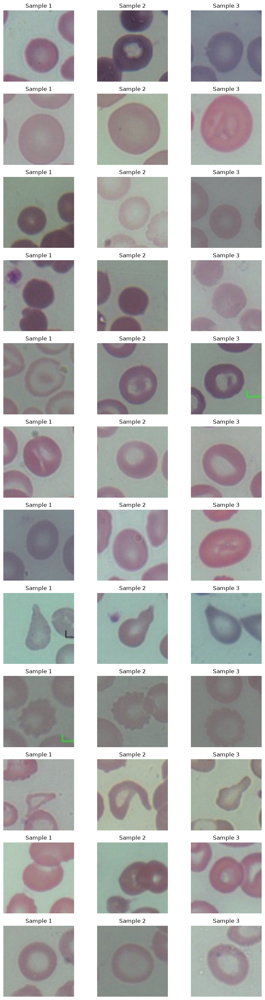

In [67]:
# ============================================================
# CELL 51 — VISUALIZE RBC CROPS FROM ALL 12 CLASSES
# ============================================================

import random
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Number of classes
# ------------------------------------------------------------

NUM_CLASSES = len(CLASS_NAMES)


# ------------------------------------------------------------
# Number of samples per class
# ------------------------------------------------------------

SAMPLES_PER_CLASS = 3


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    NUM_CLASSES,
    SAMPLES_PER_CLASS,
    figsize=(9, 30)
)


# ------------------------------------------------------------
# Visualize each class
# ------------------------------------------------------------

for class_id, class_name in CLASS_NAMES.items():

    class_folder = (
        RBC_CROP_DIR /
        f"{class_id}_{class_name}"
    )


    # --------------------------------------------------------
    # Get crop files
    # --------------------------------------------------------

    crop_files = list(
        class_folder.glob("*.png")
    )


    # --------------------------------------------------------
    # Random samples
    # --------------------------------------------------------

    selected_files = random.sample(
        crop_files,
        min(
            SAMPLES_PER_CLASS,
            len(crop_files)
        )
    )


    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    for column in range(
        SAMPLES_PER_CLASS
    ):

        ax = axes[
            class_id,
            column
        ]


        if column >= len(selected_files):

            ax.axis("off")

            continue


        crop = cv2.imread(
            str(selected_files[column])
        )


        if crop is None:

            ax.axis("off")

            continue


        crop = cv2.cvtColor(
            crop,
            cv2.COLOR_BGR2RGB
        )


        ax.imshow(
            crop
        )

        ax.axis("off")


        if column == 0:

            ax.set_ylabel(
                f"{class_id} - {class_name}",
                fontsize=10
            )


        ax.set_title(
            f"Sample {column + 1}"
        )


plt.tight_layout()

plt.show()

RBC CLASS DISTRIBUTION
 class_id    class_name  count
        0        Normal   5200
        1     Macrocyte    641
        2     Microcyte    385
        3    Spherocyte   2903
        4   Target_Cell   2300
        5   Stomatocyte   1681
        6     Ovalocyte   1808
        7      Teardrop    267
        8     Burr_Cell    663
        9   Schistocyte    784
       10 Uncategorized    159
       11   Hypochromia    916

Largest class: 5200
Smallest class: 159
Imbalance ratio: 32.70:1


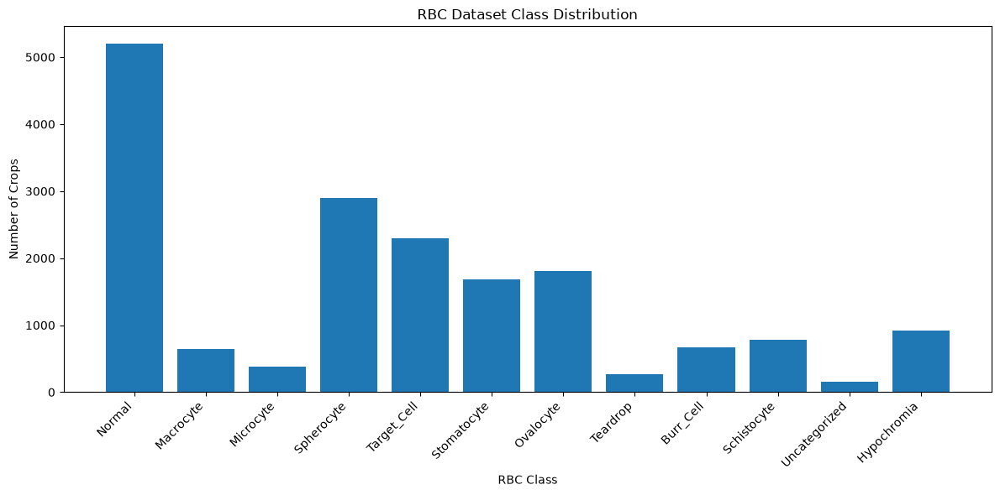

In [68]:
# ============================================================
# CELL 52 — CLASS DISTRIBUTION ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Count images in each class folder
# ------------------------------------------------------------

class_distribution = []

for class_id, class_name in CLASS_NAMES.items():

    class_folder = (
        RBC_CROP_DIR /
        f"{class_id}_{class_name}"
    )

    count = len(
        list(class_folder.glob("*.png"))
    )

    class_distribution.append({
        "class_id": class_id,
        "class_name": class_name,
        "count": count
    })


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

class_df = pd.DataFrame(
    class_distribution
)


# ------------------------------------------------------------
# Print distribution
# ------------------------------------------------------------

print("=" * 60)
print("RBC CLASS DISTRIBUTION")
print("=" * 60)

print(
    class_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

maximum = class_df["count"].max()
minimum = class_df["count"].min()

imbalance_ratio = (
    maximum / minimum
)


print()
print("=" * 60)

print(
    "Largest class:",
    maximum
)

print(
    "Smallest class:",
    minimum
)

print(
    f"Imbalance ratio: "
    f"{imbalance_ratio:.2f}:1"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    class_df["class_name"],
    class_df["count"]
)

plt.xlabel(
    "RBC Class"
)

plt.ylabel(
    "Number of Crops"
)

plt.title(
    "RBC Dataset Class Distribution"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [69]:
# ============================================================
# CELL 53 — IMAGE-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from collections import defaultdict
import shutil


# ------------------------------------------------------------
# Split ratios
# ------------------------------------------------------------

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

SPLIT_DIR = PROJECT_ROOT / "data" / "rbc_dataset"

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"


for split_dir in [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]:

    split_dir.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Create class folders
# ------------------------------------------------------------

for class_id, class_name in CLASS_NAMES.items():

    folder_name = (
        f"{class_id}_{class_name}"
    )

    (TRAIN_DIR / folder_name).mkdir(
        parents=True,
        exist_ok=True
    )

    (VAL_DIR / folder_name).mkdir(
        parents=True,
        exist_ok=True
    )

    (TEST_DIR / folder_name).mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Collect all crops
# ------------------------------------------------------------

all_files = []

for class_id, class_name in CLASS_NAMES.items():

    class_folder = (
        RBC_CROP_DIR /
        f"{class_id}_{class_name}"
    )

    for image_path in class_folder.glob("*.png"):

        all_files.append({
            "path": image_path,
            "class_id": class_id,
            "class_name": class_name
        })


print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)

print(
    "Total crops:",
    len(all_files)
)


# ------------------------------------------------------------
# Stratified split
# ------------------------------------------------------------

paths = [
    item["path"]
    for item in all_files
]

labels = [
    item["class_id"]
    for item in all_files
]


# First: 70% train, 30% temporary
train_paths, temp_paths, train_labels, temp_labels = (
    train_test_split(
        paths,
        labels,
        test_size=0.30,
        stratify=labels,
        random_state=42
    )
)


# Second: split temporary into 15% validation
# and 15% test

val_paths, test_paths, val_labels, test_labels = (
    train_test_split(
        temp_paths,
        temp_labels,
        test_size=0.50,
        stratify=temp_labels,
        random_state=42
    )
)


print()
print("Train samples:",
      len(train_paths))

print("Validation samples:",
      len(val_paths))

print("Test samples:",
      len(test_paths))


# ------------------------------------------------------------
# Copy files
# ------------------------------------------------------------

def copy_split(
    paths,
    destination
):

    for source_path in paths:

        class_id = int(
            source_path.name
            .split("_class_")[-1]
            .replace(".png", "")
        )

        class_name = CLASS_NAMES[
            class_id
        ]

        folder_name = (
            f"{class_id}_{class_name}"
        )

        destination_folder = (
            destination /
            folder_name
        )

        destination_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(
            source_path,
            destination_folder /
            source_path.name
        )


print()
print("Copying training data...")

copy_split(
    train_paths,
    TRAIN_DIR
)


print("Copying validation data...")

copy_split(
    val_paths,
    VAL_DIR
)


print("Copying test data...")

copy_split(
    test_paths,
    TEST_DIR
)


print()
print("=" * 60)
print("SPLIT COMPLETE")
print("=" * 60)

print(
    "Train directory:",
    TRAIN_DIR
)

print(
    "Validation directory:",
    VAL_DIR
)

print(
    "Test directory:",
    TEST_DIR
)

DATASET SPLIT
Total crops: 17707

Train samples: 12394
Validation samples: 2656
Test samples: 2657

Copying training data...
Copying validation data...
Copying test data...

SPLIT COMPLETE
Train directory: c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset\train
Validation directory: c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset\val
Test directory: c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset\test


In [70]:
# ============================================================
# CELL 54 — LEAKAGE-SAFE SMEAR-LEVEL DATASET SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from collections import defaultdict
import shutil


# ------------------------------------------------------------
# Final split directory
# ------------------------------------------------------------

FINAL_SPLIT_DIR = (
    PROJECT_ROOT /
    "data" /
    "rbc_dataset_final"
)

FINAL_TRAIN_DIR = FINAL_SPLIT_DIR / "train"
FINAL_VAL_DIR   = FINAL_SPLIT_DIR / "val"
FINAL_TEST_DIR  = FINAL_SPLIT_DIR / "test"


# ------------------------------------------------------------
# Remove previous split if it exists
# ------------------------------------------------------------

if FINAL_SPLIT_DIR.exists():

    shutil.rmtree(
        FINAL_SPLIT_DIR
    )


# ------------------------------------------------------------
# Create directories
# ------------------------------------------------------------

for split_dir in [
    FINAL_TRAIN_DIR,
    FINAL_VAL_DIR,
    FINAL_TEST_DIR
]:

    split_dir.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Create class folders
# ------------------------------------------------------------

for class_id, class_name in CLASS_NAMES.items():

    folder_name = (
        f"{class_id}_{class_name}"
    )

    (
        FINAL_TRAIN_DIR /
        folder_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        FINAL_VAL_DIR /
        folder_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        FINAL_TEST_DIR /
        folder_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Find all original smear IDs
# ------------------------------------------------------------

smear_ids = set()

for class_id, class_name in CLASS_NAMES.items():

    class_folder = (
        RBC_CROP_DIR /
        f"{class_id}_{class_name}"
    )

    for image_path in class_folder.glob("*.png"):

        # Example:
        # 1_rbc_5_class_0.png
        #
        # Smear ID = 1

        smear_id = (
            image_path.name
            .split("_rbc_")[0]
        )

        smear_ids.add(
            smear_id
        )


smear_ids = sorted(
    smear_ids,
    key=lambda x: int(x)
)


print("=" * 60)
print("SMEAR-LEVEL DATASET SPLIT")
print("=" * 60)

print(
    "Unique smear images:",
    len(smear_ids)
)


# ------------------------------------------------------------
# 70 / 15 / 15 split
# ------------------------------------------------------------

train_smears, temp_smears = train_test_split(
    smear_ids,
    test_size=0.30,
    random_state=42
)


val_smears, test_smears = train_test_split(
    temp_smears,
    test_size=0.50,
    random_state=42
)


train_smears = set(train_smears)
val_smears = set(val_smears)
test_smears = set(test_smears)


print()
print(
    "Train smear images:",
    len(train_smears)
)

print(
    "Validation smear images:",
    len(val_smears)
)

print(
    "Test smear images:",
    len(test_smears)
)


# ------------------------------------------------------------
# Verify no overlap
# ------------------------------------------------------------

print()

print(
    "Train ∩ Validation:",
    len(
        train_smears &
        val_smears
    )
)

print(
    "Train ∩ Test:",
    len(
        train_smears &
        test_smears
    )
)

print(
    "Validation ∩ Test:",
    len(
        val_smears &
        test_smears
    )
)


# ------------------------------------------------------------
# Copy crops according to smear ID
# ------------------------------------------------------------

split_counts = {
    "train": 0,
    "val": 0,
    "test": 0
}


for class_id, class_name in CLASS_NAMES.items():

    class_folder = (
        RBC_CROP_DIR /
        f"{class_id}_{class_name}"
    )

    for image_path in class_folder.glob("*.png"):

        smear_id = (
            image_path.name
            .split("_rbc_")[0]
        )


        # ----------------------------------------------------
        # Determine split
        # ----------------------------------------------------

        if smear_id in train_smears:

            destination_root = (
                FINAL_TRAIN_DIR
            )

            split_name = "train"


        elif smear_id in val_smears:

            destination_root = (
                FINAL_VAL_DIR
            )

            split_name = "val"


        elif smear_id in test_smears:

            destination_root = (
                FINAL_TEST_DIR
            )

            split_name = "test"


        else:

            continue


        # ----------------------------------------------------
        # Destination
        # ----------------------------------------------------

        destination_folder = (
            destination_root /
            f"{class_id}_{class_name}"
        )


        shutil.copy2(
            image_path,
            destination_folder /
            image_path.name
        )


        split_counts[
            split_name
        ] += 1


# ------------------------------------------------------------
# Final results
# ------------------------------------------------------------

print()
print("=" * 60)
print("FINAL SPLIT COMPLETE")
print("=" * 60)

print(
    "Train crops:",
    split_counts["train"]
)

print(
    "Validation crops:",
    split_counts["val"]
)

print(
    "Test crops:",
    split_counts["test"]
)

print(
    "Total:",
    sum(split_counts.values())
)

print()
print(
    "Final dataset:",
    FINAL_SPLIT_DIR
)

SMEAR-LEVEL DATASET SPLIT
Unique smear images: 589

Train smear images: 412
Validation smear images: 88
Test smear images: 89

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

FINAL SPLIT COMPLETE
Train crops: 11937
Validation crops: 2908
Test crops: 2862
Total: 17707

Final dataset: c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final


In [71]:
# ============================================================
# CELL 55 — FINAL TRAIN / VAL / TEST DISTRIBUTION
# ============================================================

def count_split_samples(split_dir):

    counts = {}

    for class_id, class_name in CLASS_NAMES.items():

        folder = (
            split_dir /
            f"{class_id}_{class_name}"
        )

        counts[
            class_name
        ] = len(
            list(folder.glob("*.png"))
        )

    return counts


train_counts = count_split_samples(
    FINAL_TRAIN_DIR
)

val_counts = count_split_samples(
    FINAL_VAL_DIR
)

test_counts = count_split_samples(
    FINAL_TEST_DIR
)


print("=" * 70)
print("FINAL DATASET DISTRIBUTION")
print("=" * 70)

print(
    f"{'Class':<18}"
    f"{'Train':>10}"
    f"{'Val':>10}"
    f"{'Test':>10}"
)

print("-" * 70)


for class_name in CLASS_NAMES.values():

    print(
        f"{class_name:<18}"
        f"{train_counts[class_name]:>10}"
        f"{val_counts[class_name]:>10}"
        f"{test_counts[class_name]:>10}"
    )


print("-" * 70)

print(
    f"{'TOTAL':<18}"
    f"{sum(train_counts.values()):>10}"
    f"{sum(val_counts.values()):>10}"
    f"{sum(test_counts.values()):>10}"
)

FINAL DATASET DISTRIBUTION
Class                  Train       Val      Test
----------------------------------------------------------------------
Normal                  3367       920       913
Macrocyte                459       112        70
Microcyte                229        69        87
Spherocyte              1671       791       441
Target_Cell             1796       258       246
Stomatocyte             1121       315       245
Ovalocyte               1283       113       412
Teardrop                 206        34        27
Burr_Cell                444        69       150
Schistocyte              581       110        93
Uncategorized            110        23        26
Hypochromia              670        94       152
----------------------------------------------------------------------
TOTAL                  11937      2908      2862


In [6]:
# ============================================================
# CELL 72 — CHECK FINAL DATASET FOLDERS
# ============================================================

from pathlib import Path

print("=" * 60)
print("FINAL DATASET FOLDER CHECK")
print("=" * 60)

train_classes = sorted([
    p.name for p in TRAIN_DIR.iterdir()
    if p.is_dir()
])

val_classes = sorted([
    p.name for p in VAL_DIR.iterdir()
    if p.is_dir()
])

test_classes = sorted([
    p.name for p in TEST_DIR.iterdir()
    if p.is_dir()
])

print("\nTrain classes:")
for name in train_classes:
    print(" ", name)

print("\nValidation classes:")
for name in val_classes:
    print(" ", name)

print("\nTest classes:")
for name in test_classes:
    print(" ", name)

print("\nNumber of train classes:", len(train_classes))
print("Number of val classes:", len(val_classes))
print("Number of test classes:", len(test_classes))

if train_classes == val_classes == test_classes:
    print("\n✅ All three splits have identical class folders.")
else:
    print("\n❌ WARNING: Class folders do not match.")

FINAL DATASET FOLDER CHECK

Train classes:
  0_Normal
  10_Uncategorized
  11_Hypochromia
  1_Macrocyte
  2_Microcyte
  3_Spherocyte
  4_Target_Cell
  5_Stomatocyte
  6_Ovalocyte
  7_Teardrop
  8_Burr_Cell
  9_Schistocyte

Validation classes:
  0_Normal
  10_Uncategorized
  11_Hypochromia
  1_Macrocyte
  2_Microcyte
  3_Spherocyte
  4_Target_Cell
  5_Stomatocyte
  6_Ovalocyte
  7_Teardrop
  8_Burr_Cell
  9_Schistocyte

Test classes:
  0_Normal
  10_Uncategorized
  11_Hypochromia
  1_Macrocyte
  2_Microcyte
  3_Spherocyte
  4_Target_Cell
  5_Stomatocyte
  6_Ovalocyte
  7_Teardrop
  8_Burr_Cell
  9_Schistocyte

Number of train classes: 12
Number of val classes: 12
Number of test classes: 12

✅ All three splits have identical class folders.


In [7]:
# ============================================================
# CELL 73 — TENSORFLOW DATA PIPELINE
# ============================================================

import tensorflow as tf

print("=" * 60)
print("TENSORFLOW DATA PIPELINE")
print("=" * 60)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# IMPORTANT:
# Keep the same folder/class order for Train, Validation and Test
CLASS_NAMES = [
    "0_Normal",
    "1_Macrocyte",
    "2_Microcyte",
    "3_Spherocyte",
    "4_Target_Cell",
    "5_Stomatocyte",
    "6_Ovalocyte",
    "7_Teardrop",
    "8_Burr_Cell",
    "9_Schistocyte",
    "10_Uncategorized",
    "11_Hypochromia"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

# ------------------------------------------------------------
# Load training dataset
# ------------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# ------------------------------------------------------------
# Load validation dataset
# ------------------------------------------------------------

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------------------------
# Load test dataset
# ------------------------------------------------------------

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print()
print("Datasets loaded successfully!")

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

print()
print("Class names:")
print(train_ds.class_names)

TENSORFLOW DATA PIPELINE
Image size: (224, 224)
Batch size: 32
Number of classes: 12
Found 11937 files belonging to 12 classes.
Found 2908 files belonging to 12 classes.
Found 2862 files belonging to 12 classes.

Datasets loaded successfully!
Train batches: 374
Val batches  : 91
Test batches : 90

Class names:
['0_Normal', '1_Macrocyte', '2_Microcyte', '3_Spherocyte', '4_Target_Cell', '5_Stomatocyte', '6_Ovalocyte', '7_Teardrop', '8_Burr_Cell', '9_Schistocyte', '10_Uncategorized', '11_Hypochromia']


In [8]:
# ============================================================
# CELL 74 — OPTIMIZE TENSORFLOW DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

print("=" * 60)
print("DATA PIPELINE OPTIMIZATION")
print("=" * 60)

print("✅ Training dataset  : Prefetch enabled")
print("✅ Validation dataset: Prefetch enabled")
print("✅ Test dataset      : Prefetch enabled")
print("AUTOTUNE             :", AUTOTUNE)

DATA PIPELINE OPTIMIZATION
✅ Training dataset  : Prefetch enabled
✅ Validation dataset: Prefetch enabled
✅ Test dataset      : Prefetch enabled
AUTOTUNE             : -1


In [9]:
# ============================================================
# CELL 75 — VERIFY ONE TRAINING BATCH
# ============================================================

images, labels = next(iter(train_ds))

print("=" * 60)
print("TRAINING BATCH CHECK")
print("=" * 60)

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Image data type   :", images.dtype)
print("Label data type   :", labels.dtype)

print()
print("Pixel minimum     :", tf.reduce_min(images).numpy())
print("Pixel maximum     :", tf.reduce_max(images).numpy())

print()
print("First 10 labels   :", labels[:10].numpy())

TRAINING BATCH CHECK
Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Image data type   : <dtype: 'float32'>
Label data type   : <dtype: 'int32'>

Pixel minimum     : 50.10173
Pixel maximum     : 209.83224

First 10 labels   : [4 0 5 6 6 0 2 3 0 3]


In [3]:
# ============================================================
# CELL 76 — DATA AUGMENTATION + NORMALIZATION
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers

print("=" * 60)
print("DATA AUGMENTATION + NORMALIZATION")
print("=" * 60)

# ------------------------------------------------------------
# Data augmentation
# ------------------------------------------------------------

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip(
        mode="horizontal"
    ),

    layers.RandomRotation(
        factor=0.08
    ),

    layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
], name="rbc_augmentation")


# ------------------------------------------------------------
# Normalization
# ------------------------------------------------------------

normalization = layers.Rescaling(
    1.0 / 255.0,
    name="pixel_normalization"
)


print("✅ Random horizontal flip")
print("✅ Random rotation")
print("✅ Random zoom")
print("✅ Random translation")
print("✅ Pixel normalization: 0–255 → 0–1")

DATA AUGMENTATION + NORMALIZATION
✅ Random horizontal flip
✅ Random rotation
✅ Random zoom
✅ Random translation
✅ Pixel normalization: 0–255 → 0–1


In [6]:
# ============================================================
# CELL 78A — RECREATE VARIABLES AFTER KERNEL RESTART
# ============================================================

from pathlib import Path
import numpy as np
import tensorflow as tf

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT"
)

FINAL_DATASET_DIR = (
    PROJECT_ROOT / "data" / "rbc_dataset_final"
)

TRAIN_DIR = FINAL_DATASET_DIR / "train"
VAL_DIR = FINAL_DATASET_DIR / "val"
TEST_DIR = FINAL_DATASET_DIR / "test"

# ------------------------------------------------------------
# Classes
# ------------------------------------------------------------

CLASS_NAMES = [
    "0_Normal",
    "1_Macrocyte",
    "2_Microcyte",
    "3_Spherocyte",
    "4_Target_Cell",
    "5_Stomatocyte",
    "6_Ovalocyte",
    "7_Teardrop",
    "8_Burr_Cell",
    "9_Schistocyte",
    "10_Uncategorized",
    "11_Hypochromia"
]

NUM_CLASSES = len(CLASS_NAMES)

# ------------------------------------------------------------
# Image configuration
# ------------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# ------------------------------------------------------------
# Recreate TensorFlow datasets
# ------------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------------------------
# Optimize pipeline
# ------------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# ------------------------------------------------------------
# Recreate augmentation
# ------------------------------------------------------------

from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
], name="rbc_augmentation")

# ------------------------------------------------------------
# Recreate normalization
# ------------------------------------------------------------

normalization = layers.Rescaling(
    1.0 / 255.0,
    name="pixel_normalization"
)

print("=" * 60)
print("RESTART-SAFE PROJECT SETUP")
print("=" * 60)

print("Train samples : 11937")
print("Validation    : 2908")
print("Test samples  : 2862")
print("Classes       :", NUM_CLASSES)
print("Image size    :", IMG_SIZE)
print("Batch size    :", BATCH_SIZE)

print()
print("✅ All required variables recreated.")

Found 11937 files belonging to 12 classes.
Found 2908 files belonging to 12 classes.
Found 2862 files belonging to 12 classes.
RESTART-SAFE PROJECT SETUP
Train samples : 11937
Validation    : 2908
Test samples  : 2862
Classes       : 12
Image size    : (224, 224)
Batch size    : 32

✅ All required variables recreated.


In [7]:
# ============================================================
# CELL 78 — CLASS WEIGHTS WITHOUT SCIKIT-LEARN
# ============================================================

import numpy as np

print("=" * 60)
print("CALCULATING CLASS WEIGHTS")
print("=" * 60)

# Count samples in each class
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

for _, labels in train_ds.unbatch():
    class_id = int(labels.numpy())
    class_counts[class_id] += 1

# Balanced class-weight formula
total_samples = int(np.sum(class_counts))

CLASS_WEIGHTS = {}

for class_id in range(NUM_CLASSES):

    if class_counts[class_id] > 0:
        weight = total_samples / (
            NUM_CLASSES * class_counts[class_id]
        )
    else:
        weight = 0.0

    CLASS_WEIGHTS[class_id] = float(weight)

# Display results
print()

for class_id, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_id:2d} | "
        f"{class_name:<20} | "
        f"Samples: {class_counts[class_id]:5d} | "
        f"Weight: {CLASS_WEIGHTS[class_id]:.4f}"
    )

print()
print("Total training samples:", total_samples)
print("Number of classes:", NUM_CLASSES)

print()
print("✅ Class weights calculated using NumPy.")

CALCULATING CLASS WEIGHTS

 0 | 0_Normal             | Samples:  3367 | Weight: 0.2954
 1 | 1_Macrocyte          | Samples:   459 | Weight: 2.1672
 2 | 2_Microcyte          | Samples:   229 | Weight: 4.3439
 3 | 3_Spherocyte         | Samples:  1671 | Weight: 0.5953
 4 | 4_Target_Cell        | Samples:  1796 | Weight: 0.5539
 5 | 5_Stomatocyte        | Samples:  1121 | Weight: 0.8874
 6 | 6_Ovalocyte          | Samples:  1283 | Weight: 0.7753
 7 | 7_Teardrop           | Samples:   206 | Weight: 4.8289
 8 | 8_Burr_Cell          | Samples:   444 | Weight: 2.2404
 9 | 9_Schistocyte        | Samples:   581 | Weight: 1.7121
10 | 10_Uncategorized     | Samples:   110 | Weight: 9.0432
11 | 11_Hypochromia       | Samples:   670 | Weight: 1.4847

Total training samples: 11937
Number of classes: 12

✅ Class weights calculated using NumPy.


In [8]:
# ============================================================
# CELL 79 — MODEL STORAGE SETUP
# ============================================================

from pathlib import Path

MODEL_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR = MODEL_DIR / "checkpoints"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_rbc_model.keras"
FINAL_MODEL_PATH = MODEL_DIR / "final_rbc_model.keras"

print("=" * 60)
print("MODEL STORAGE SETUP")
print("=" * 60)

print("Model directory     :", MODEL_DIR)
print("Checkpoint directory:", CHECKPOINT_DIR)
print("Best model          :", BEST_MODEL_PATH)
print("Final model         :", FINAL_MODEL_PATH)

print()
print("✅ Model storage ready.")

MODEL STORAGE SETUP
Model directory     : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models
Checkpoint directory: C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\checkpoints
Best model          : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras
Final model         : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\final_rbc_model.keras

✅ Model storage ready.


In [9]:
# ============================================================
# CELL 80 — BUILD RBC CLASSIFICATION MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models

print("=" * 60)
print("BUILDING RBC CLASSIFICATION MODEL")
print("=" * 60)

# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------

inputs = layers.Input(
    shape=(224, 224, 3),
    name="rbc_input"
)

# ------------------------------------------------------------
# DATA AUGMENTATION
# ------------------------------------------------------------

x = data_augmentation(inputs)

# ------------------------------------------------------------
# NORMALIZATION
# ------------------------------------------------------------

x = normalization(x)

# ------------------------------------------------------------
# PRETRAINED MOBILENETV2
# ------------------------------------------------------------

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

print()
print("MobileNetV2 loaded successfully.")
print("Pretrained layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

# ------------------------------------------------------------
# FEATURE EXTRACTION
# ------------------------------------------------------------

x = base_model(
    x,
    training=False
)

# ------------------------------------------------------------
# CLASSIFICATION HEAD
# ------------------------------------------------------------

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.BatchNormalization(
    name="batch_normalization"
)(x)

x = layers.Dropout(
    0.35,
    name="dropout_1"
)(x)

x = layers.Dense(
    256,
    activation="relu",
    name="dense_256"
)(x)

x = layers.Dropout(
    0.25,
    name="dropout_2"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="rbc_class_output"
)(x)

# ------------------------------------------------------------
# FINAL MODEL
# ------------------------------------------------------------

model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="RBC_MobileNetV2_Classifier"
)

print()
print("=" * 60)
print("MODEL CREATED")
print("=" * 60)

print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)
print("Classes     :", NUM_CLASSES)

print()
print("Total parameters:", f"{model.count_params():,}")

BUILDING RBC CLASSIFICATION MODEL
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

MobileNetV2 loaded successfully.
Pretrained layers: 154
Trainable: False

MODEL CREATED
Input shape : (None, 224, 224, 3)
Output shape: (None, 12)
Classes     : 12

Total parameters: 2,594,124


In [10]:
# ============================================================
# CELL 81 — COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("=" * 60)
print("MODEL COMPILED")
print("=" * 60)

print("Optimizer    : Adam")
print("Learning rate: 0.001")
print("Loss         : Sparse Categorical Crossentropy")
print("Metric       : Accuracy")

print()
print("✅ Model compilation complete.")

MODEL COMPILED
Optimizer    : Adam
Learning rate: 0.001
Loss         : Sparse Categorical Crossentropy
Metric       : Accuracy

✅ Model compilation complete.


In [11]:
# ============================================================
# CELL 82 — MODEL SUMMARY
# ============================================================

model.summary()

Model: "RBC_MobileNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rbc_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rbc_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rbc_class_output (Dense)        │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,124 (9.90 MB)

 Trainable params: 333,580 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [12]:
# ============================================================
# CELL 83 — TRAINING CALLBACKS
# ============================================================

import tensorflow as tf

print("=" * 60)
print("SETTING UP TRAINING CALLBACKS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Save best model automatically
# ------------------------------------------------------------

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# ------------------------------------------------------------
# 2. Stop training if validation accuracy stops improving
# ------------------------------------------------------------

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# 3. Reduce learning rate when validation accuracy plateaus
# ------------------------------------------------------------

reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# ------------------------------------------------------------
# 4. Save training history/log
# ------------------------------------------------------------

csv_logger_callback = tf.keras.callbacks.CSVLogger(
    str(MODEL_DIR / "training_history.csv"),
    append=True
)

# ------------------------------------------------------------
# Callback list
# ------------------------------------------------------------

callbacks = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback,
    csv_logger_callback
]

print()
print("✅ Checkpoint callback ready")
print("✅ Early stopping ready")
print("✅ Learning-rate reduction ready")
print("✅ Training history logging ready")

print()
print("Best model will be saved to:")
print(BEST_MODEL_PATH)

SETTING UP TRAINING CALLBACKS

✅ Checkpoint callback ready
✅ Early stopping ready
✅ Learning-rate reduction ready
✅ Training history logging ready

Best model will be saved to:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras


In [13]:
# ============================================================
# CELL 84 — VERIFY CLASS WEIGHTS
# ============================================================

print("=" * 60)
print("CLASS WEIGHTS VERIFICATION")
print("=" * 60)

for class_id, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_id:2d} | "
        f"{class_name:<20} | "
        f"{CLASS_WEIGHTS[class_id]:.4f}"
    )

print()
print("Total classes:", len(CLASS_WEIGHTS))
print("Expected classes:", NUM_CLASSES)

assert len(CLASS_WEIGHTS) == NUM_CLASSES

print()
print("✅ Class weights are ready for training.")

CLASS WEIGHTS VERIFICATION
 0 | 0_Normal             | 0.2954
 1 | 1_Macrocyte          | 2.1672
 2 | 2_Microcyte          | 4.3439
 3 | 3_Spherocyte         | 0.5953
 4 | 4_Target_Cell        | 0.5539
 5 | 5_Stomatocyte        | 0.8874
 6 | 6_Ovalocyte          | 0.7753
 7 | 7_Teardrop           | 4.8289
 8 | 8_Burr_Cell          | 2.2404
 9 | 9_Schistocyte        | 1.7121
10 | 10_Uncategorized     | 9.0432
11 | 11_Hypochromia       | 1.4847

Total classes: 12
Expected classes: 12

✅ Class weights are ready for training.


In [14]:
# ============================================================
# CELL 85 — TRAIN RBC CLASSIFIER
# ============================================================

print("=" * 60)
print("STARTING RBC MODEL TRAINING")
print("=" * 60)

print()
print("Training samples   : 11937")
print("Validation samples : 2908")
print("Batch size         :", BATCH_SIZE)
print("Number of classes  :", NUM_CLASSES)
print("Maximum epochs     : 15")
print()

history = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=15,

    class_weight=CLASS_WEIGHTS,

    callbacks=callbacks,

    verbose=1
)

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

STARTING RBC MODEL TRAINING

Training samples   : 11937
Validation samples : 2908
Batch size         : 32
Number of classes  : 12
Maximum epochs     : 15

Epoch 1/15


c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4995 - loss: 1.5540
Epoch 1: val_accuracy improved from None to 0.65922, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras

Epoch 1: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - accuracy: 0.4995 - loss: 1.5540 - val_accuracy: 0.6592 - val_loss: 1.0479 - learning_rate: 0.0010
Epoch 2/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5694 - loss: 1.1966
Epoch 2: val_accuracy improved from 0.65922 to 0.67675, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras

Epoch 2: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 675s 2s/step - accuracy: 0.5694 - loss: 1.1966 - val_accuracy: 0.6768 - val_loss: 1.0086 - learning_rate: 0.0010
Epoch 3/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s

In [15]:
 # ============================================================
# CELL 86 — LOAD BEST SAVED MODEL
# ============================================================

import tensorflow as tf

print("=" * 60)
print("LOADING BEST SAVED RBC MODEL")
print("=" * 60)

print("Path:")
print(BEST_MODEL_PATH)

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print()
print("✅ Best model loaded successfully.")

print()
print("Model name :", best_model.name)
print("Input shape:", best_model.input_shape)
print("Output shape:", best_model.output_shape)

LOADING BEST SAVED RBC MODEL
Path:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras

✅ Best model loaded successfully.

Model name : RBC_MobileNetV2_Classifier
Input shape: (None, 224, 224, 3)
Output shape: (None, 12)


In [16]:
# ============================================================
# CELL 87 — TEST SET EVALUATION
# ============================================================

print("=" * 60)
print("EVALUATING BEST MODEL ON TEST SET")
print("=" * 60)

test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print()
print("=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

EVALUATING BEST MODEL ON TEST SET
90/90 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7299 - loss: 0.8047

TEST RESULTS
Test Loss     : 0.8047
Test Accuracy : 72.99%


In [17]:
# ============================================================
# CELL 88 — GENERATE TEST PREDICTIONS
# ============================================================

import numpy as np
import tensorflow as tf

print("=" * 60)
print("GENERATING TEST PREDICTIONS")
print("=" * 60)

# ------------------------------------------------------------
# Get predictions
# ------------------------------------------------------------

y_prob = best_model.predict(
    test_ds,
    verbose=1
)

# Predicted class
y_pred = np.argmax(
    y_prob,
    axis=1
)

# ------------------------------------------------------------
# Get ground-truth labels
# ------------------------------------------------------------

y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

print()
print("Prediction array shape :", y_prob.shape)
print("Predicted labels shape :", y_pred.shape)
print("True labels shape      :", y_true.shape)

print()
print("Number of test samples :", len(y_true))

print()
print("✅ Test predictions generated.")

GENERATING TEST PREDICTIONS
90/90 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step

Prediction array shape : (2862, 12)
Predicted labels shape : (2862,)
True labels shape      : (2862,)

Number of test samples : 2862

✅ Test predictions generated.


In [18]:
# ============================================================
# CELL 89 — MANUAL ACCURACY VERIFICATION
# ============================================================

correct_predictions = np.sum(
    y_true == y_pred
)

total_predictions = len(y_true)

manual_accuracy = (
    correct_predictions /
    total_predictions
)

print("=" * 60)
print("MANUAL TEST ACCURACY")
print("=" * 60)

print("Correct predictions :", correct_predictions)
print("Total predictions   :", total_predictions)

print(
    f"Accuracy            : {manual_accuracy * 100:.2f}%"
)

print()
print("Keras accuracy      :", f"{test_accuracy * 100:.2f}%")

print()
print("✅ Accuracy verification complete.")

MANUAL TEST ACCURACY
Correct predictions : 2089
Total predictions   : 2862
Accuracy            : 72.99%

Keras accuracy      : 72.99%

✅ Accuracy verification complete.


In [19]:
# ============================================================
# CELL 90 — CLASSIFICATION REPORT
# ============================================================

print("=" * 90)
print("RBC CLASSIFICATION REPORT")
print("=" * 90)

print(
    f"{'Class':<20}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1-Score':>12}"
    f"{'Support':>12}"
)

print("-" * 90)

all_metrics = {}

for class_id, class_name in enumerate(CLASS_NAMES):

    # True positives
    tp = np.sum(
        (y_true == class_id) &
        (y_pred == class_id)
    )

    # False positives
    fp = np.sum(
        (y_true != class_id) &
        (y_pred == class_id)
    )

    # False negatives
    fn = np.sum(
        (y_true == class_id) &
        (y_pred != class_id)
    )

    # Support
    support = np.sum(
        y_true == class_id
    )

    # Precision
    if tp + fp > 0:
        precision = tp / (tp + fp)
    else:
        precision = 0.0

    # Recall
    if tp + fn > 0:
        recall = tp / (tp + fn)
    else:
        recall = 0.0

    # F1
    if precision + recall > 0:
        f1 = (
            2 * precision * recall /
            (precision + recall)
        )
    else:
        f1 = 0.0

    all_metrics[class_id] = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    }

    print(
        f"{class_name:<20}"
        f"{precision:>11.4f}"
        f"{recall:>11.4f}"
        f"{f1:>11.4f}"
        f"{support:>11d}"
    )

print("-" * 90)

# Macro averages
macro_precision = np.mean([
    x["precision"]
    for x in all_metrics.values()
])

macro_recall = np.mean([
    x["recall"]
    for x in all_metrics.values()
])

macro_f1 = np.mean([
    x["f1"]
    for x in all_metrics.values()
])

print(
    f"{'MACRO AVG':<20}"
    f"{macro_precision:>11.4f}"
    f"{macro_recall:>11.4f}"
    f"{macro_f1:>11.4f}"
)

print()
print("✅ Classification report generated.")

RBC CLASSIFICATION REPORT
Class                  Precision      Recall    F1-Score     Support
------------------------------------------------------------------------------------------
0_Normal                 0.8685     0.6440     0.7396        913
1_Macrocyte              0.4183     0.9143     0.5740         70
2_Microcyte              0.4077     0.6092     0.4885         87
3_Spherocyte             0.8578     0.8345     0.8460        441
4_Target_Cell            0.7812     0.7114     0.7447        246
5_Stomatocyte            0.6467     0.9265     0.7617        245
6_Ovalocyte              0.8311     0.7646     0.7965        412
7_Teardrop               0.4151     0.8148     0.5500         27
8_Burr_Cell              0.7987     0.8467     0.8220        150
9_Schistocyte            0.6667     0.5591     0.6082         93
10_Uncategorized         0.4524     0.7308     0.5588         26
11_Hypochromia           0.4225     0.5197     0.4661        152
----------------------------------

CONFUSION MATRIX

[[588  55  35  36  17  74  32   1  18   4   6  47]
 [  2  64   0   0   1   0   0   0   0   0   0   3]
 [ 10   0  53   7   2   1   2   2   3   3   0   4]
 [ 20   4  24 368   0   0   6   2   7   8   2   0]
 [  9  11   0   0 175  14   2   2   1   6   0  26]
 [  0   1   2   0   0 227   4   1   0   1   1   8]
 [ 26   9   5   7   5  10 315  14   1   2   3  15]
 [  0   0   0   1   0   0   2  22   0   2   0   0]
 [  8   4   1   5   0   0   1   0 127   0   1   3]
 [  4   0   3   4   2   1  10   9   2  52   6   0]
 [  0   0   1   1   1   0   2   0   0   0  19   2]
 [ 10   5   6   0  21  24   3   0   0   0   4  79]]


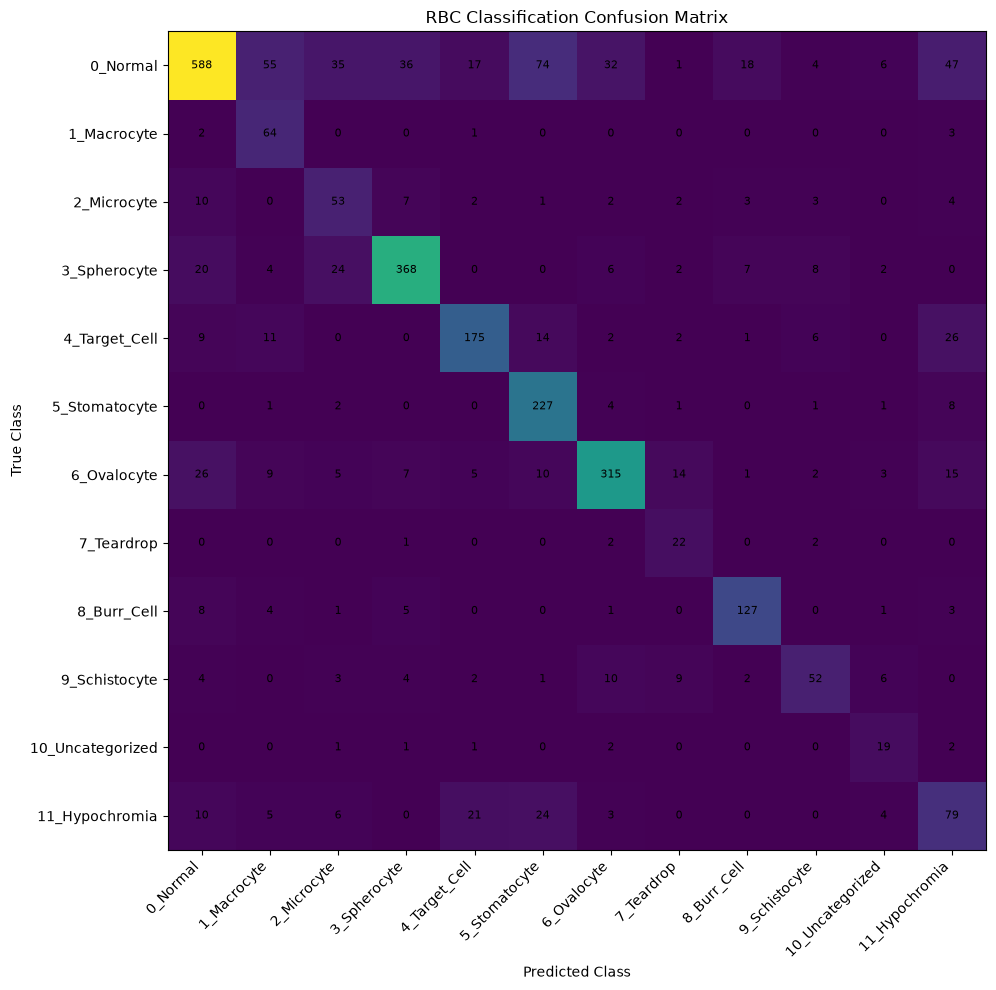

In [21]:
# ============================================================
# CELL 91 — CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create confusion matrix
# ------------------------------------------------------------

confusion_matrix = np.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=np.int32
)

for true_label, predicted_label in zip(
    y_true,
    y_pred
):

    confusion_matrix[
        true_label,
        predicted_label
    ] += 1

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print()
print(confusion_matrix)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 10)
)

im = ax.imshow(
    confusion_matrix,
    interpolation="nearest"
)

ax.set_title(
    "RBC Classification Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

# Add numbers
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 92 — CLASS-WISE ACCURACY
# ============================================================

print("=" * 70)
print("CLASS-WISE ACCURACY")
print("=" * 70)

class_accuracies = {}

for class_id, class_name in enumerate(CLASS_NAMES):

    total_class_samples = np.sum(
        y_true == class_id
    )

    correct_class_samples = np.sum(
        (y_true == class_id) &
        (y_pred == class_id)
    )

    if total_class_samples > 0:

        accuracy = (
            correct_class_samples /
            total_class_samples
        )

    else:

        accuracy = 0.0

    class_accuracies[class_id] = accuracy

    print(
        f"{class_name:<20} : "
        f"{accuracy * 100:6.2f}% "
        f"({correct_class_samples}/"
        f"{total_class_samples})"
    )

print()
print("✅ Class-wise accuracy calculated.")

CLASS-WISE ACCURACY
0_Normal             :  64.40% (588/913)
1_Macrocyte          :  91.43% (64/70)
2_Microcyte          :  60.92% (53/87)
3_Spherocyte         :  83.45% (368/441)
4_Target_Cell        :  71.14% (175/246)
5_Stomatocyte        :  92.65% (227/245)
6_Ovalocyte          :  76.46% (315/412)
7_Teardrop           :  81.48% (22/27)
8_Burr_Cell          :  84.67% (127/150)
9_Schistocyte        :  55.91% (52/93)
10_Uncategorized     :  73.08% (19/26)
11_Hypochromia       :  51.97% (79/152)

✅ Class-wise accuracy calculated.


In [23]:
# ============================================================
# CELL 93 — SAVE FINAL RBC MODEL
# ============================================================

print("=" * 60)
print("SAVING FINAL RBC MODEL")
print("=" * 60)

# best_model was loaded from the best checkpoint
best_model.save(
    FINAL_MODEL_PATH
)

print()
print("✅ Final model saved successfully.")

print()
print("Final model:")
print(FINAL_MODEL_PATH)

print()
print("Best checkpoint:")
print(BEST_MODEL_PATH)

SAVING FINAL RBC MODEL

✅ Final model saved successfully.

Final model:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\final_rbc_model.keras

Best checkpoint:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\best_rbc_model.keras


In [36]:
# ============================================================
# CELL 94 — LOAD FINAL SAVED RBC MODEL
# ============================================================

import tensorflow as tf
import numpy as np

print("=" * 60)
print("LOADING FINAL SAVED RBC MODEL")
print("=" * 60)

final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

print()
print("✅ Final model loaded successfully.")

print("Model name  :", final_model.name)
print("Input shape :", final_model.input_shape)
print("Output shape:", final_model.output_shape)

print()
print("Model path:")
print(FINAL_MODEL_PATH)

LOADING FINAL SAVED RBC MODEL

✅ Final model loaded successfully.
Model name  : RBC_MobileNetV2_Classifier
Input shape : (None, 224, 224, 3)
Output shape: (None, 12)

Model path:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\final_rbc_model.keras


In [39]:
# ============================================================
# CELL 100 — CLASS-WISE ACCURACY
# ============================================================

print("=" * 75)
print("CLASS-WISE ACCURACY")
print("=" * 75)

class_accuracy = {}

for class_id, class_name in enumerate(CLASS_NAMES):

    total_samples = np.sum(
        y_true == class_id
    )

    correct_samples = np.sum(
        (y_true == class_id) &
        (y_pred == class_id)
    )

    accuracy = (
        correct_samples / total_samples
        if total_samples > 0
        else 0
    )

    class_accuracy[class_id] = accuracy

    print(
        f"{class_id:2d} | "
        f"{class_name:<20} | "
        f"{correct_samples:4d}/"
        f"{total_samples:4d} | "
        f"{accuracy * 100:6.2f}%"
    )

print()
print("✅ Class-wise accuracy calculated.")

CLASS-WISE ACCURACY
 0 | 0_Normal             |  588/ 913 |  64.40%
 1 | 1_Macrocyte          |   64/  70 |  91.43%
 2 | 2_Microcyte          |   53/  87 |  60.92%
 3 | 3_Spherocyte         |  368/ 441 |  83.45%
 4 | 4_Target_Cell        |  175/ 246 |  71.14%
 5 | 5_Stomatocyte        |  227/ 245 |  92.65%
 6 | 6_Ovalocyte          |  315/ 412 |  76.46%
 7 | 7_Teardrop           |   22/  27 |  81.48%
 8 | 8_Burr_Cell          |  127/ 150 |  84.67%
 9 | 9_Schistocyte        |   52/  93 |  55.91%
10 | 10_Uncategorized     |   19/  26 |  73.08%
11 | 11_Hypochromia       |   79/ 152 |  51.97%

✅ Class-wise accuracy calculated.


In [40]:
# ============================================================
# CELL 101 — BEST AND WORST PERFORMING CLASSES
# ============================================================

print("=" * 70)
print("BEST AND WORST PERFORMING RBC CLASSES")
print("=" * 70)

sorted_classes = sorted(
    class_accuracy.items(),
    key=lambda x: x[1],
    reverse=True
)

print()
print("TOP 5 CLASSES")
print("-" * 70)

for class_id, accuracy in sorted_classes[:5]:

    print(
        f"{CLASS_NAMES[class_id]:<22}"
        f"{accuracy * 100:6.2f}%"
    )

print()
print("BOTTOM 5 CLASSES")
print("-" * 70)

for class_id, accuracy in sorted_classes[-5:]:

    print(
        f"{CLASS_NAMES[class_id]:<22}"
        f"{accuracy * 100:6.2f}%"
    )

print()
print("✅ Class performance ranking complete.")

BEST AND WORST PERFORMING RBC CLASSES

TOP 5 CLASSES
----------------------------------------------------------------------
5_Stomatocyte          92.65%
1_Macrocyte            91.43%
8_Burr_Cell            84.67%
3_Spherocyte           83.45%
7_Teardrop             81.48%

BOTTOM 5 CLASSES
----------------------------------------------------------------------
4_Target_Cell          71.14%
0_Normal               64.40%
2_Microcyte            60.92%
9_Schistocyte          55.91%
11_Hypochromia         51.97%

✅ Class performance ranking complete.


In [42]:
# ============================================================
# CELL 102 — MOST COMMON MISCLASSIFICATIONS
# ============================================================

print("=" * 80)
print("MOST COMMON MISCLASSIFICATIONS")
print("=" * 80)

errors = []

for true_class in range(NUM_CLASSES):

    for predicted_class in range(NUM_CLASSES):

        if true_class == predicted_class:
            continue

        count = confusion_matrix[
            true_class,
            predicted_class
        ]

        if count > 0:

            errors.append(
                (
                    count,
                    true_class,
                    predicted_class
                )
            )

# Sort highest error first
errors.sort(
    reverse=True
)

print()

for count, true_class, predicted_class in errors[:15]:

    print(
        f"{CLASS_NAMES[true_class]:<20}"
        f" → "
        f"{CLASS_NAMES[predicted_class]:<20}"
        f": {count}"
    )

print()
print("✅ Misclassification analysis complete.")

MOST COMMON MISCLASSIFICATIONS

0_Normal             → 5_Stomatocyte       : 74
0_Normal             → 1_Macrocyte         : 55
0_Normal             → 11_Hypochromia      : 47
0_Normal             → 3_Spherocyte        : 36
0_Normal             → 2_Microcyte         : 35
0_Normal             → 6_Ovalocyte         : 32
6_Ovalocyte          → 0_Normal            : 26
4_Target_Cell        → 11_Hypochromia      : 26
11_Hypochromia       → 5_Stomatocyte       : 24
3_Spherocyte         → 2_Microcyte         : 24
11_Hypochromia       → 4_Target_Cell       : 21
3_Spherocyte         → 0_Normal            : 20
0_Normal             → 8_Burr_Cell         : 18
0_Normal             → 4_Target_Cell       : 17
6_Ovalocyte          → 11_Hypochromia      : 15

✅ Misclassification analysis complete.


In [43]:
# ============================================================
# CELL 103 — PREDICTION CONFIDENCE ANALYSIS
# ============================================================

print("=" * 70)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 70)

# Highest probability for each image
confidence = np.max(
    y_prob,
    axis=1
)

correct_mask = (
    y_true == y_pred
)

incorrect_mask = (
    y_true != y_pred
)

print()

print(
    f"Overall average confidence : "
    f"{np.mean(confidence) * 100:.2f}%"
)

if np.sum(correct_mask) > 0:

    print(
        f"Correct prediction confidence : "
        f"{np.mean(confidence[correct_mask]) * 100:.2f}%"
    )

if np.sum(incorrect_mask) > 0:

    print(
        f"Incorrect prediction confidence : "
        f"{np.mean(confidence[incorrect_mask]) * 100:.2f}%"
    )

print()
print("Confidence distribution:")

print(
    f"< 50%   : "
    f"{np.sum(confidence < 0.50)}"
)

print(
    f"50–70%  : "
    f"{np.sum((confidence >= 0.50) & (confidence < 0.70))}"
)

print(
    f"70–90%  : "
    f"{np.sum((confidence >= 0.70) & (confidence < 0.90))}"
)

print(
    f">= 90%  : "
    f"{np.sum(confidence >= 0.90)}"
)

print()
print("✅ Confidence analysis complete.")

PREDICTION CONFIDENCE ANALYSIS

Overall average confidence : 73.55%
Correct prediction confidence : 79.10%
Incorrect prediction confidence : 58.57%

Confidence distribution:
< 50%   : 536
50–70%  : 669
70–90%  : 719
>= 90%  : 938

✅ Confidence analysis complete.


In [45]:
# ============================================================
# CELL 104 — SAVE MOBILENETV2 ANALYSIS
# ============================================================

import csv
from pathlib import Path

print("=" * 60)
print("SAVING MOBILENETV2 ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Recalculate class metrics
# ------------------------------------------------------------

class_metrics = {}

for class_id, class_name in enumerate(CLASS_NAMES):

    # True Positives
    tp = np.sum(
        (y_true == class_id) &
        (y_pred == class_id)
    )

    # False Positives
    fp = np.sum(
        (y_true != class_id) &
        (y_pred == class_id)
    )

    # False Negatives
    fn = np.sum(
        (y_true == class_id) &
        (y_pred != class_id)
    )

    # Support
    support = np.sum(
        y_true == class_id
    )

    # Precision
    if (tp + fp) > 0:
        precision = tp / (tp + fp)
    else:
        precision = 0.0

    # Recall
    if (tp + fn) > 0:
        recall = tp / (tp + fn)
    else:
        recall = 0.0

    # F1-score
    if (precision + recall) > 0:
        f1 = (
            2 * precision * recall /
            (precision + recall)
        )
    else:
        f1 = 0.0

    # Class accuracy
    if support > 0:
        accuracy = tp / support
    else:
        accuracy = 0.0

    class_metrics[class_id] = {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "accuracy": accuracy
    }


# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

ANALYSIS_PATH = (
    MODEL_DIR /
    "mobilenetv2_class_analysis.csv"
)

with open(
    ANALYSIS_PATH,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow([
        "Class ID",
        "Class Name",
        "Precision",
        "Recall",
        "F1 Score",
        "Support",
        "Accuracy"
    ])

    for class_id, class_name in enumerate(
        CLASS_NAMES
    ):

        writer.writerow([
            class_id,
            class_name,
            f"{class_metrics[class_id]['precision']:.4f}",
            f"{class_metrics[class_id]['recall']:.4f}",
            f"{class_metrics[class_id]['f1']:.4f}",
            class_metrics[class_id]["support"],
            f"{class_metrics[class_id]['accuracy']:.4f}"
        ])


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print()
print("Analysis file:")
print(ANALYSIS_PATH)

print()
print("Classes saved:", len(class_metrics))

print()
print("Macro Precision:",
      f"{np.mean([x['precision'] for x in class_metrics.values()]) * 100:.2f}%")

print("Macro Recall   :",
      f"{np.mean([x['recall'] for x in class_metrics.values()]) * 100:.2f}%")

print("Macro F1       :",
      f"{np.mean([x['f1'] for x in class_metrics.values()]) * 100:.2f}%")

print()
print("✅ MobileNetV2 analysis saved successfully.")

SAVING MOBILENETV2 ANALYSIS

Analysis file:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\mobilenetv2_class_analysis.csv

Classes saved: 12

Macro Precision: 63.06%
Macro Recall   : 73.96%
Macro F1       : 66.30%

✅ MobileNetV2 analysis saved successfully.


In [47]:
# ============================================================
# CELL 105 — MOBILENETV2 FINAL BASELINE SUMMARY
# ============================================================

import tensorflow as tf
import numpy as np

print("=" * 70)
print("MOBILENETV2 — FINAL BASELINE SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load saved model
# ------------------------------------------------------------

print()
print("Loading saved model...")

final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

print("✅ Model loaded successfully.")


# ------------------------------------------------------------
# 2. Evaluate on test dataset
# ------------------------------------------------------------

print()
print("Evaluating on test dataset...")

final_test_loss, final_test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)


# ------------------------------------------------------------
# 3. Calculate macro metrics
# ------------------------------------------------------------

# class_metrics should already exist from Cell 104.
# If it doesn't, calculate it again.

if "class_metrics" not in globals():

    print()
    print("Recalculating class metrics...")

    class_metrics = {}

    for class_id, class_name in enumerate(CLASS_NAMES):

        tp = np.sum(
            (y_true == class_id) &
            (y_pred == class_id)
        )

        fp = np.sum(
            (y_true != class_id) &
            (y_pred == class_id)
        )

        fn = np.sum(
            (y_true == class_id) &
            (y_pred != class_id)
        )

        support = np.sum(
            y_true == class_id
        )

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0.0
        )

        f1 = (
            2 * precision * recall /
            (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        class_metrics[class_id] = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support
        }


# ------------------------------------------------------------
# Macro averages
# ------------------------------------------------------------

macro_precision = np.mean([
    x["precision"]
    for x in class_metrics.values()
])

macro_recall = np.mean([
    x["recall"]
    for x in class_metrics.values()
])

macro_f1 = np.mean([
    x["f1"]
    for x in class_metrics.values()
])


# ------------------------------------------------------------
# 4. Final report
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL MOBILENETV2 RESULTS")
print("=" * 70)

print()

print("Model             : MobileNetV2")
print("Number of classes :", NUM_CLASSES)

print()
print("Dataset:")
print("Training samples  : 11937")
print("Validation samples: 2908")
print("Test samples      : 2862")

print()
print("Performance:")
print(
    f"Test Loss         : "
    f"{final_test_loss:.4f}"
)

print(
    f"Test Accuracy     : "
    f"{final_test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision   : "
    f"{macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall      : "
    f"{macro_recall * 100:.2f}%"
)

print(
    f"Macro F1          : "
    f"{macro_f1 * 100:.2f}%"
)

print()
print("Saved model:")
print(FINAL_MODEL_PATH)

print()
print("Analysis CSV:")
print(ANALYSIS_PATH)

print()
print("=" * 70)
print("✅ MOBILENETV2 BASELINE ANALYSIS COMPLETE")
print("=" * 70)

MOBILENETV2 — FINAL BASELINE SUMMARY

Loading saved model...


✅ Model loaded successfully.

Evaluating on test dataset...
90/90 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.7299 - loss: 0.8047

FINAL MOBILENETV2 RESULTS

Model             : MobileNetV2
Number of classes : 12

Dataset:
Training samples  : 11937
Validation samples: 2908
Test samples      : 2862

Performance:
Test Loss         : 0.8047
Test Accuracy     : 72.99%
Macro Precision   : 63.06%
Macro Recall      : 73.96%
Macro F1          : 66.30%

Saved model:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\final_rbc_model.keras

Analysis CSV:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\mobilenetv2_class_analysis.csv

✅ MOBILENETV2 BASELINE ANALYSIS COMPLETE


In [48]:
# ============================================================
# CELL 106 — VISUALIZATION SETUP
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Create visualization directory
# ------------------------------------------------------------

VIS_DIR = MODEL_DIR / "visualizations"
VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 60)
print("MOBILENETV2 VISUALIZATION SETUP")
print("=" * 60)

print()
print("Visualization directory:")
print(VIS_DIR)

print()
print("Test samples :", len(y_true))
print("Classes      :", NUM_CLASSES)

print()
print("✅ Visualization setup complete.")

MOBILENETV2 VISUALIZATION SETUP

Visualization directory:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations

Test samples : 2862
Classes      : 12

✅ Visualization setup complete.


CONFUSION MATRIX


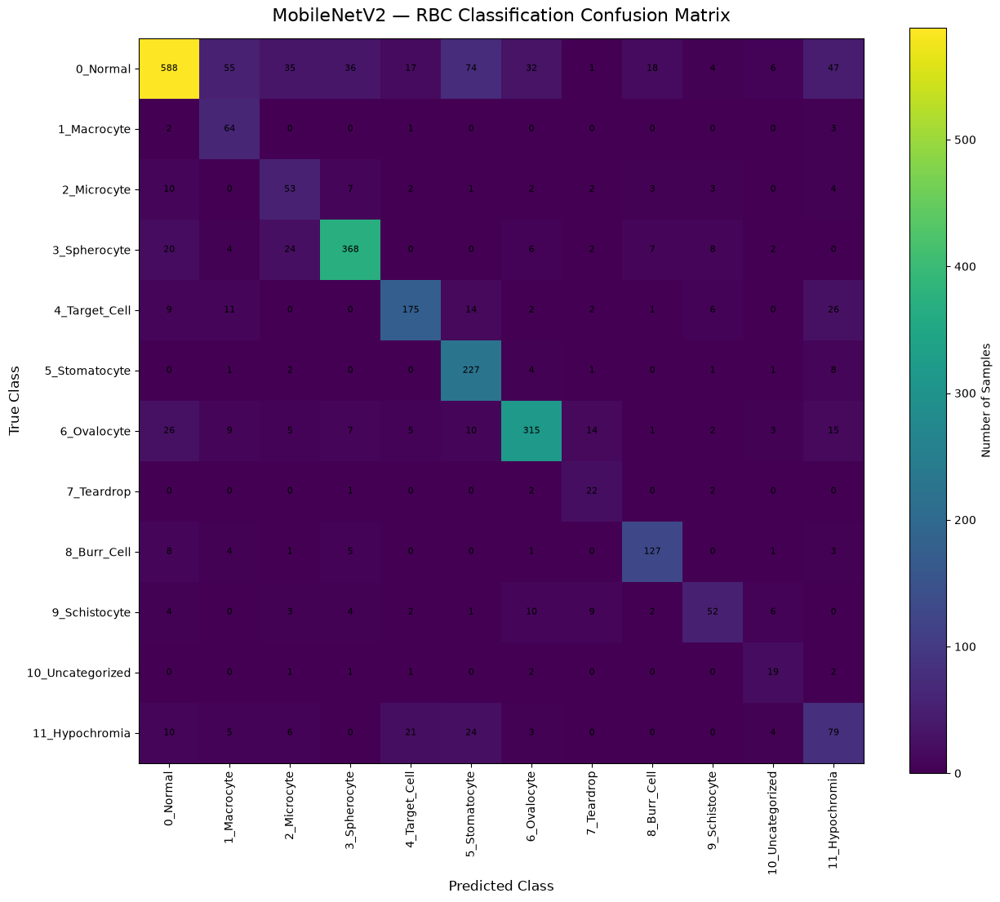


Saved:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations\01_confusion_matrix.png

✅ Confusion matrix saved.


In [49]:
# ============================================================
# CELL 107 — CONFUSION MATRIX
# ============================================================

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

# ------------------------------------------------------------
# Create confusion matrix
# ------------------------------------------------------------

confusion_matrix = np.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=np.int32
)

for true_label, predicted_label in zip(
    y_true,
    y_pred
):

    confusion_matrix[
        true_label,
        predicted_label
    ] += 1


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 11)
)

im = ax.imshow(
    confusion_matrix,
    interpolation="nearest"
)

ax.set_title(
    "MobileNetV2 — RBC Classification Confusion Matrix",
    fontsize=16,
    pad=15
)

ax.set_xlabel(
    "Predicted Class",
    fontsize=12
)

ax.set_ylabel(
    "True Class",
    fontsize=12
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=90
)

ax.set_yticklabels(
    CLASS_NAMES
)

# ------------------------------------------------------------
# Add numbers inside cells
# ------------------------------------------------------------

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        value = confusion_matrix[i, j]

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(
    im,
    ax=ax,
    label="Number of Samples"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

cm_path = (
    VIS_DIR /
    "01_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(cm_path)

print()
print("✅ Confusion matrix saved.")

CLASS-WISE ACCURACY


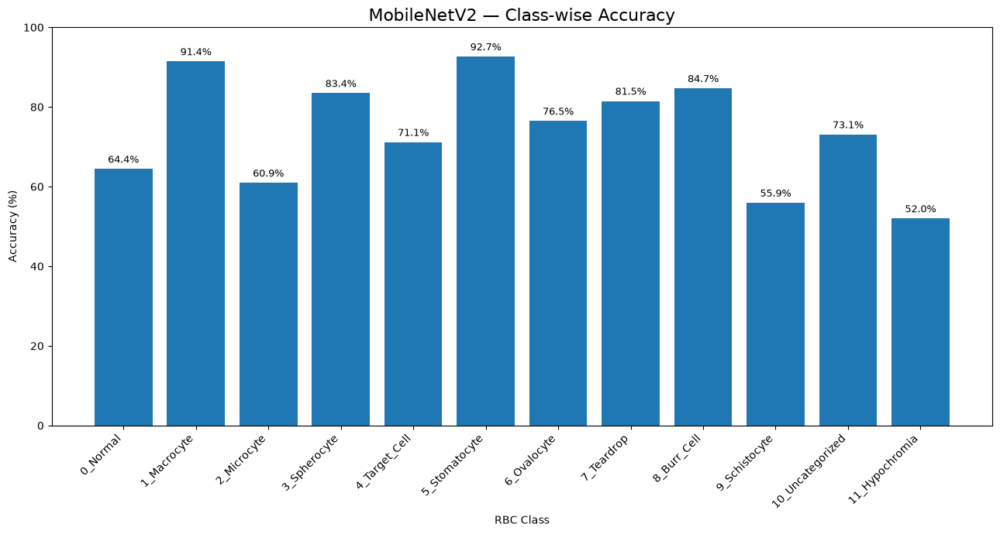


Saved:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations\02_class_wise_accuracy.png

✅ Class-wise accuracy visualization saved.


In [50]:
# ============================================================
# CELL 108 — CLASS-WISE ACCURACY
# ============================================================

print("=" * 60)
print("CLASS-WISE ACCURACY")
print("=" * 60)

class_accuracy = []

for class_id in range(NUM_CLASSES):

    total = np.sum(
        y_true == class_id
    )

    correct = np.sum(
        (y_true == class_id) &
        (y_pred == class_id)
    )

    accuracy = (
        correct / total
        if total > 0
        else 0
    )

    class_accuracy.append(
        accuracy * 100
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 7)
)

bars = ax.bar(
    CLASS_NAMES,
    class_accuracy
)

ax.set_title(
    "MobileNetV2 — Class-wise Accuracy",
    fontsize=16
)

ax.set_xlabel(
    "RBC Class"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.set_ylim(
    0,
    100
)

plt.xticks(
    rotation=45,
    ha="right"
)

# ------------------------------------------------------------
# Add values
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    class_accuracy
):

    ax.text(
        bar.get_x() +
        bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

accuracy_path = (
    VIS_DIR /
    "02_class_wise_accuracy.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(accuracy_path)

print()
print("✅ Class-wise accuracy visualization saved.")

PRECISION / RECALL / F1 SCORE


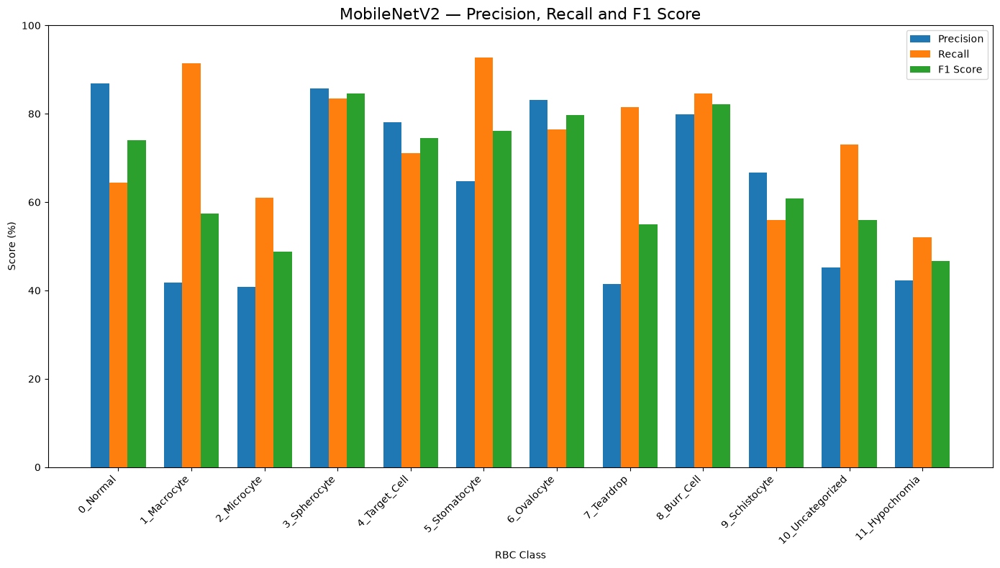


Saved:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations\03_precision_recall_f1.png

✅ Precision/Recall/F1 visualization saved.


In [51]:
# ============================================================
# CELL 109 — PRECISION RECALL F1 VISUALIZATION
# ============================================================

print("=" * 60)
print("PRECISION / RECALL / F1 SCORE")
print("=" * 60)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

precision_values = []
recall_values = []
f1_values = []

for class_id in range(NUM_CLASSES):

    tp = np.sum(
        (y_true == class_id) &
        (y_pred == class_id)
    )

    fp = np.sum(
        (y_true != class_id) &
        (y_pred == class_id)
    )

    fn = np.sum(
        (y_true == class_id) &
        (y_pred != class_id)
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    precision_values.append(
        precision * 100
    )

    recall_values.append(
        recall * 100
    )

    f1_values.append(
        f1 * 100
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

x = np.arange(NUM_CLASSES)

width = 0.25

fig, ax = plt.subplots(
    figsize=(14, 8)
)

ax.bar(
    x - width,
    precision_values,
    width,
    label="Precision"
)

ax.bar(
    x,
    recall_values,
    width,
    label="Recall"
)

ax.bar(
    x + width,
    f1_values,
    width,
    label="F1 Score"
)

ax.set_title(
    "MobileNetV2 — Precision, Recall and F1 Score",
    fontsize=16
)

ax.set_xlabel(
    "RBC Class"
)

ax.set_ylabel(
    "Score (%)"
)

ax.set_ylim(
    0,
    100
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.legend()

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

metrics_path = (
    VIS_DIR /
    "03_precision_recall_f1.png"
)

plt.savefig(
    metrics_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(metrics_path)

print()
print("✅ Precision/Recall/F1 visualization saved.")

PREDICTION CONFIDENCE DISTRIBUTION


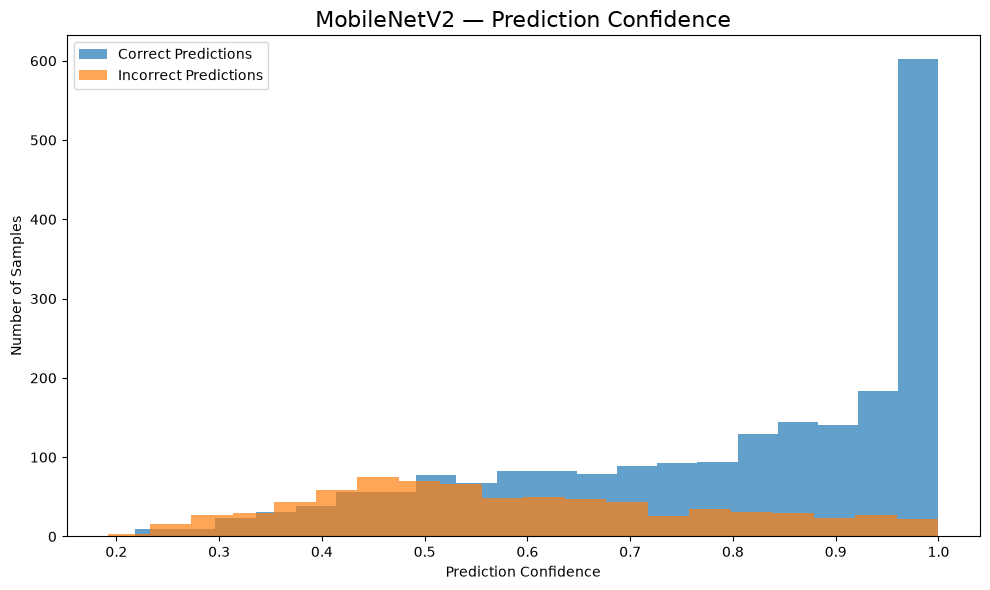


Average confidence: 73.55%

Saved:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations\04_prediction_confidence.png

✅ Confidence visualization saved.


In [52]:
# ============================================================
# CELL 110 — PREDICTION CONFIDENCE DISTRIBUTION
# ============================================================

print("=" * 60)
print("PREDICTION CONFIDENCE DISTRIBUTION")
print("=" * 60)

# ------------------------------------------------------------
# Get confidence
# ------------------------------------------------------------

confidence = np.max(
    y_prob,
    axis=1
)

correct_mask = (
    y_true == y_pred
)

incorrect_mask = (
    y_true != y_pred
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    confidence[correct_mask],
    bins=20,
    alpha=0.7,
    label="Correct Predictions"
)

ax.hist(
    confidence[incorrect_mask],
    bins=20,
    alpha=0.7,
    label="Incorrect Predictions"
)

ax.set_title(
    "MobileNetV2 — Prediction Confidence",
    fontsize=16
)

ax.set_xlabel(
    "Prediction Confidence"
)

ax.set_ylabel(
    "Number of Samples"
)

ax.legend()

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

confidence_path = (
    VIS_DIR /
    "04_prediction_confidence.png"
)

plt.savefig(
    confidence_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print(
    f"Average confidence: "
    f"{np.mean(confidence) * 100:.2f}%"
)

print()
print("Saved:")
print(confidence_path)

print()
print("✅ Confidence visualization saved.")

SAMPLE RBC PREDICTIONS


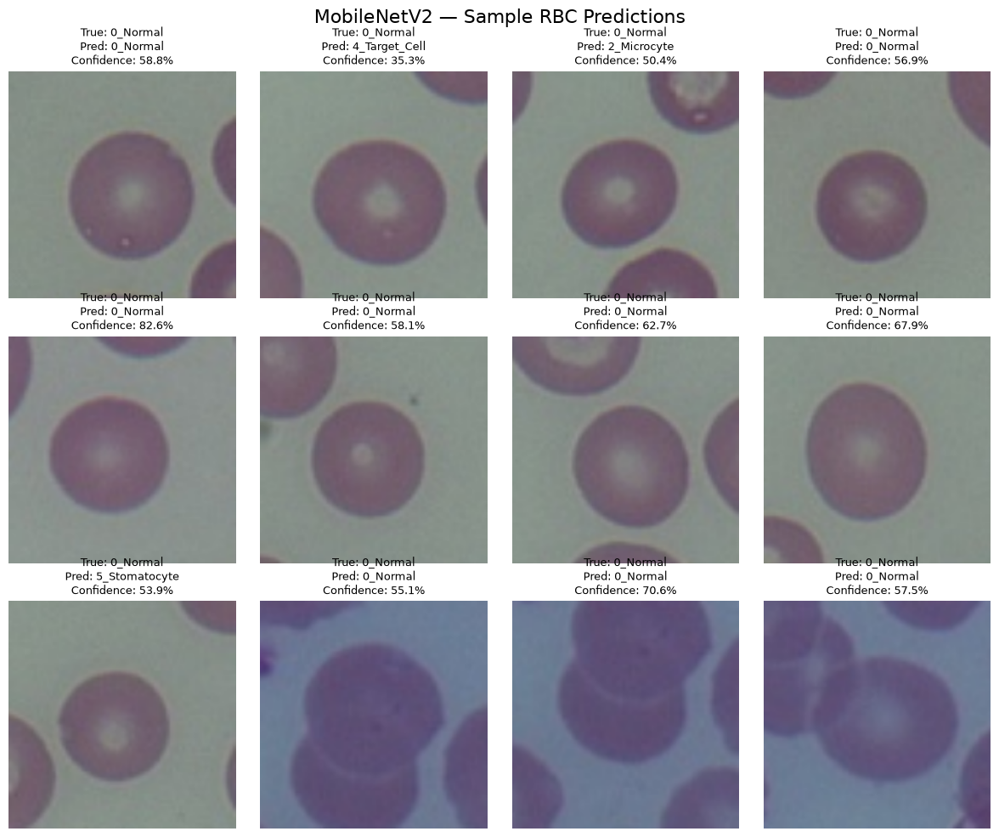


Saved:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations\05_sample_predictions.png

✅ Sample prediction visualization saved.


In [53]:
# ============================================================
# CELL 111 — SAMPLE TEST PREDICTIONS
# ============================================================

print("=" * 60)
print("SAMPLE RBC PREDICTIONS")
print("=" * 60)

# ------------------------------------------------------------
# Collect sample images
# ------------------------------------------------------------

sample_images = []
sample_labels = []

for images, labels in test_ds.take(2):

    for image, label in zip(
        images,
        labels
    ):

        sample_images.append(
            image.numpy()
        )

        sample_labels.append(
            int(label.numpy())
        )

        if len(sample_images) >= 12:
            break

    if len(sample_images) >= 12:
        break


# ------------------------------------------------------------
# Predictions for samples
# ------------------------------------------------------------

sample_images_array = np.array(
    sample_images
)

sample_probabilities = final_model.predict(
    sample_images_array,
    verbose=0
)

sample_predictions = np.argmax(
    sample_probabilities,
    axis=1
)

sample_confidence = np.max(
    sample_probabilities,
    axis=1
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 10)
)

axes = axes.flatten()

for i in range(12):

    image = sample_images[i]

    true_id = sample_labels[i]

    pred_id = sample_predictions[i]

    confidence_value = (
        sample_confidence[i] * 100
    )

    axes[i].imshow(
        image.astype("uint8")
    )

    axes[i].set_title(
        f"True: {CLASS_NAMES[true_id]}\n"
        f"Pred: {CLASS_NAMES[pred_id]}\n"
        f"Confidence: {confidence_value:.1f}%",
        fontsize=9
    )

    axes[i].axis("off")


plt.suptitle(
    "MobileNetV2 — Sample RBC Predictions",
    fontsize=16
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

samples_path = (
    VIS_DIR /
    "05_sample_predictions.png"
)

plt.savefig(
    samples_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved:")
print(samples_path)

print()
print("✅ Sample prediction visualization saved.")

TRAINING HISTORY VISUALIZATION


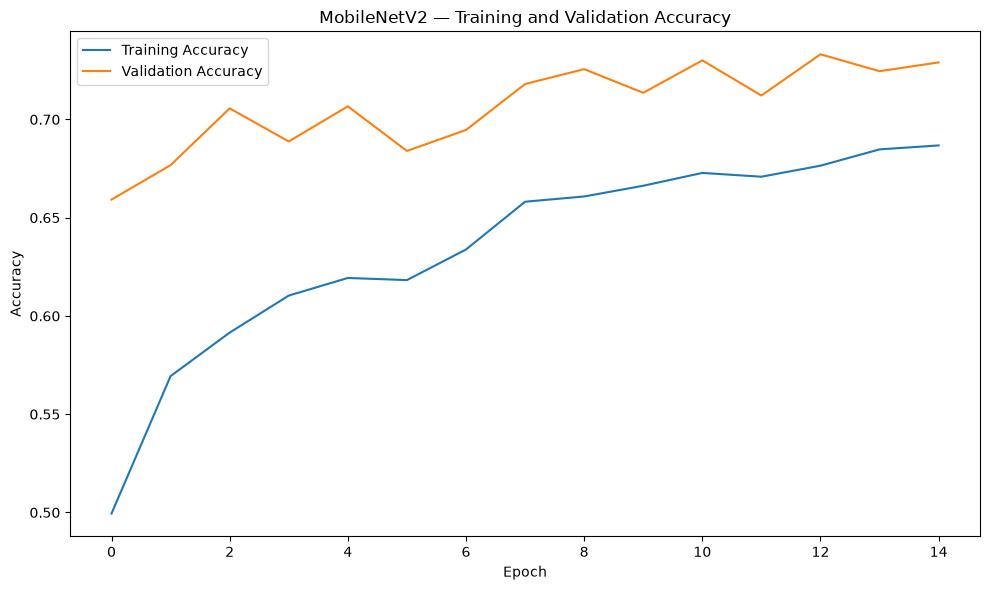

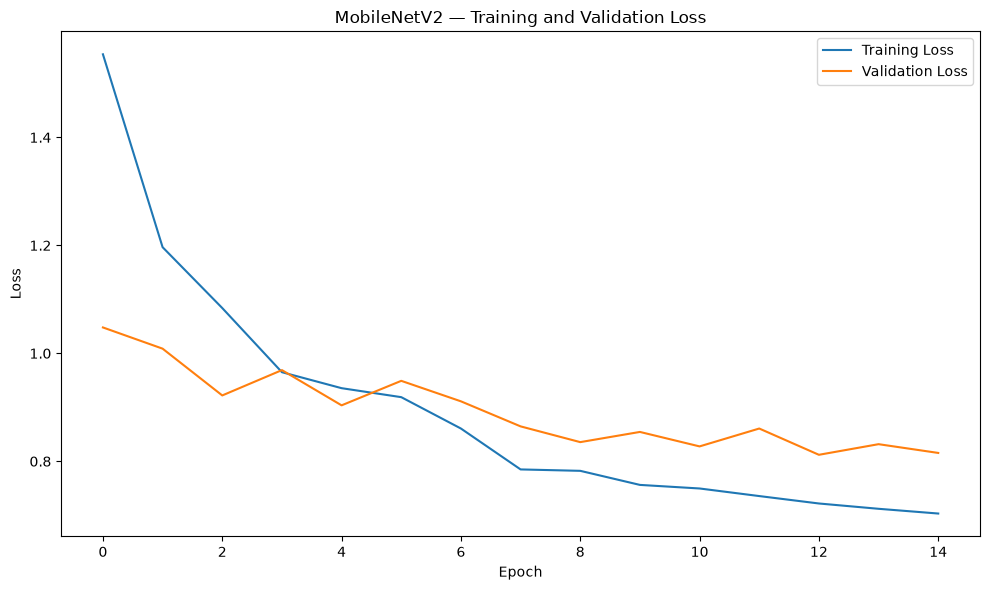


✅ Training history visualization complete.


In [54]:
# ============================================================
# CELL 112 — TRAINING HISTORY VISUALIZATION
# ============================================================

print("=" * 60)
print("TRAINING HISTORY VISUALIZATION")
print("=" * 60)

if "history" not in globals():

    print()
    print("⚠️ Training history is not available")
    print()
    print("This is okay.")
    print("The saved model and test analysis are unaffected.")

else:

    history_data = history.history

    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    if "accuracy" in history_data:

        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

        ax.plot(
            history_data["accuracy"],
            label="Training Accuracy"
        )

        if "val_accuracy" in history_data:

            ax.plot(
                history_data["val_accuracy"],
                label="Validation Accuracy"
            )

        ax.set_title(
            "MobileNetV2 — Training and Validation Accuracy"
        )

        ax.set_xlabel(
            "Epoch"
        )

        ax.set_ylabel(
            "Accuracy"
        )

        ax.legend()

        plt.tight_layout()

        history_acc_path = (
            VIS_DIR /
            "06_training_validation_accuracy.png"
        )

        plt.savefig(
            history_acc_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    if "loss" in history_data:

        fig, ax = plt.subplots(
            figsize=(10, 6)
        )

        ax.plot(
            history_data["loss"],
            label="Training Loss"
        )

        if "val_loss" in history_data:

            ax.plot(
                history_data["val_loss"],
                label="Validation Loss"
            )

        ax.set_title(
            "MobileNetV2 — Training and Validation Loss"
        )

        ax.set_xlabel(
            "Epoch"
        )

        ax.set_ylabel(
            "Loss"
        )

        ax.legend()

        plt.tight_layout()

        history_loss_path = (
            VIS_DIR /
            "07_training_validation_loss.png"
        )

        plt.savefig(
            history_loss_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    print()
    print("✅ Training history visualization complete.")

In [55]:
# ============================================================
# CELL 113 — VISUALIZATION FILE CHECK
# ============================================================

print("=" * 60)
print("MOBILENETV2 VISUALIZATION FILES")
print("=" * 60)

visualization_files = list(
    VIS_DIR.glob("*.png")
)

print()

for file in sorted(
    visualization_files
):

    size_kb = (
        file.stat().st_size / 1024
    )

    print(
        f"✅ {file.name:<45}"
        f"{size_kb:>8.1f} KB"
    )

print()

print(
    f"Total visualizations: "
    f"{len(visualization_files)}"
)

print()
print("Directory:")
print(VIS_DIR)

MOBILENETV2 VISUALIZATION FILES

✅ 01_confusion_matrix.png                         346.6 KB
✅ 02_class_wise_accuracy.png                      204.2 KB
✅ 03_precision_recall_f1.png                      186.8 KB
✅ 04_prediction_confidence.png                     97.4 KB
✅ 05_sample_predictions.png                       863.6 KB
✅ 06_training_validation_accuracy.png             151.4 KB
✅ 07_training_validation_loss.png                 136.0 KB

Total visualizations: 7

Directory:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations


# NEW EFFICIENTNET-B1 EXPERIMENT

In [24]:
# ============================================================
# CELL 94 — EFFICIENTNET-B1 EXPERIMENT SETUP
# ============================================================

from pathlib import Path
import tensorflow as tf
import numpy as np

print("=" * 60)
print("EFFICIENTNET-B1 EXPERIMENT")
print("=" * 60)

# ------------------------------------------------------------
# Experiment directory
# ------------------------------------------------------------

EFFICIENTNET_DIR = MODEL_DIR / "efficientnet_b1"

EFFICIENTNET_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_EFFICIENTNET_PATH = (
    EFFICIENTNET_DIR /
    "best_efficientnet_b1.keras"
)

FINAL_EFFICIENTNET_PATH = (
    EFFICIENTNET_DIR /
    "final_efficientnet_b1.keras"
)

HISTORY_PATH = (
    EFFICIENTNET_DIR /
    "training_history.csv"
)

print("Experiment directory:")
print(EFFICIENTNET_DIR)

print()
print("Best model:")
print(BEST_EFFICIENTNET_PATH)

print()
print("Final model:")
print(FINAL_EFFICIENTNET_PATH)

print()
print("Training samples : 11937")
print("Validation       : 2908")
print("Test             : 2862")
print("Classes          :", NUM_CLASSES)
print("Image size       : 224 x 224")

print()
print("✅ EfficientNet-B1 experiment ready.")

EFFICIENTNET-B1 EXPERIMENT
Experiment directory:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1

Best model:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Final model:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\final_efficientnet_b1.keras

Training samples : 11937
Validation       : 2908
Test             : 2862
Classes          : 12
Image size       : 224 x 224

✅ EfficientNet-B1 experiment ready.


In [25]:
# ============================================================
# CELL 95 — PAPER-STYLE DATA AUGMENTATION
# ============================================================

from tensorflow.keras import layers

print("=" * 60)
print("PAPER-STYLE AUGMENTATION")
print("=" * 60)

efficientnet_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            mode="horizontal"
        ),

        layers.RandomRotation(
            factor=0.10
        )
    ],
    name="efficientnet_rbc_augmentation"
)

print("✅ Random horizontal flip")
print("✅ Random rotation")
print()
print("No random zoom")
print("No random translation")
print()
print("✅ Augmentation configured.")

PAPER-STYLE AUGMENTATION
✅ Random horizontal flip
✅ Random rotation

No random zoom
No random translation

✅ Augmentation configured.


In [26]:
# ============================================================
# CELL 96 — BUILD EFFICIENTNET-B1
# ============================================================

from tensorflow.keras import layers, models

print("=" * 60)
print("BUILDING EFFICIENTNET-B1 MODEL")
print("=" * 60)

# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

inputs = layers.Input(
    shape=(224, 224, 3),
    name="rbc_input"
)

# ------------------------------------------------------------
# Augmentation
# ------------------------------------------------------------

x = efficientnet_augmentation(inputs)

# ------------------------------------------------------------
# EfficientNet-B1
# ------------------------------------------------------------

base_model = tf.keras.applications.EfficientNetB1(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained backbone initially
base_model.trainable = False

print()
print("EfficientNet-B1 loaded.")
print("Number of backbone layers:", len(base_model.layers))
print("Backbone trainable:", base_model.trainable)

# ------------------------------------------------------------
# Feature extraction
# ------------------------------------------------------------

x = base_model(
    x,
    training=False
)

# ------------------------------------------------------------
# Classification head
# ------------------------------------------------------------

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.30,
    name="dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="rbc_classifier"
)(x)

# ------------------------------------------------------------
# Complete model
# ------------------------------------------------------------

efficientnet_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="RBC_EfficientNetB1"
)

print()
print("=" * 60)
print("MODEL CREATED")
print("=" * 60)

print("Input shape :", efficientnet_model.input_shape)
print("Output shape:", efficientnet_model.output_shape)

print(
    "Total parameters:",
    f"{efficientnet_model.count_params():,}"
)

BUILDING EFFICIENTNET-B1 MODEL
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 48s 2us/step

EfficientNet-B1 loaded.
Number of backbone layers: 340
Backbone trainable: False

MODEL CREATED
Input shape : (None, 224, 224, 3)
Output shape: (None, 12)
Total parameters: 6,590,611


In [27]:
# ============================================================
# CELL 97 — COMPILE EFFICIENTNET-B1
# ============================================================

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("=" * 60)
print("EFFICIENTNET-B1 COMPILED")
print("=" * 60)

print("Optimizer     : Adam")
print("Learning rate : 0.001")
print("Loss          : Sparse Categorical Crossentropy")
print("Metric        : Accuracy")

print()
print("✅ Model compiled.")

EFFICIENTNET-B1 COMPILED
Optimizer     : Adam
Learning rate : 0.001
Loss          : Sparse Categorical Crossentropy
Metric        : Accuracy

✅ Model compiled.


In [28]:
# ============================================================
# CELL 98 — EFFICIENTNET-B1 SUMMARY
# ============================================================

efficientnet_model.summary()

Model: "RBC_EfficientNetB1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rbc_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_rbc_augmentation   │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rbc_classifier (Dense)          │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,590,611 (25.14 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 6,575,239 (25.08 MB)

In [29]:
# ============================================================
# CELL 99 — PAPER LEARNING RATE SCHEDULE
# ============================================================

def paper_learning_rate_schedule(epoch, lr):

    # Decay by 0.1 every 15 epochs
    if epoch > 0 and epoch % 15 == 0:
        return lr * 0.1

    return lr


lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    paper_learning_rate_schedule,
    verbose=1
)

print("=" * 60)
print("LEARNING RATE SCHEDULE")
print("=" * 60)

print("Initial learning rate : 0.001")
print("Decay factor          : 0.1")
print("Decay interval        : 15 epochs")
print("Maximum epochs        : 100")

print()
print("Expected LR schedule:")
print("Epoch 1–15   : 0.001")
print("Epoch 16–30  : 0.0001")
print("Epoch 31–45  : 0.00001")
print("Epoch 46–60  : 0.000001")
print("...")

print()
print("✅ Learning-rate scheduler ready.")

LEARNING RATE SCHEDULE
Initial learning rate : 0.001
Decay factor          : 0.1
Decay interval        : 15 epochs
Maximum epochs        : 100

Expected LR schedule:
Epoch 1–15   : 0.001
Epoch 16–30  : 0.0001
Epoch 31–45  : 0.00001
Epoch 46–60  : 0.000001
...

✅ Learning-rate scheduler ready.


In [30]:
# ============================================================
# CELL 100 — EFFICIENTNET CHECKPOINT
# ============================================================

checkpoint_efficientnet = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_EFFICIENTNET_PATH),

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)

print("=" * 60)
print("EFFICIENTNET CHECKPOINT READY")
print("=" * 60)

print()
print("Best model will be saved to:")
print(BEST_EFFICIENTNET_PATH)

print()
print("✅ Automatic best-model saving enabled.")

EFFICIENTNET CHECKPOINT READY

Best model will be saved to:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

✅ Automatic best-model saving enabled.


In [31]:
# ============================================================
# CELL 101 — EARLY STOPPING
# ============================================================

early_stopping_efficientnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",

    mode="max",

    patience=15,

    restore_best_weights=True,

    verbose=1
)

print("=" * 60)
print("EARLY STOPPING")
print("=" * 60)

print("Monitor  : val_accuracy")
print("Patience : 15 epochs")
print()
print("✅ Early stopping ready.")

EARLY STOPPING
Monitor  : val_accuracy
Patience : 15 epochs

✅ Early stopping ready.


In [32]:
# ============================================================
# CELL 102 — TRAINING HISTORY LOGGER
# ============================================================

csv_logger_efficientnet = tf.keras.callbacks.CSVLogger(
    str(HISTORY_PATH),

    append=False
)

print("=" * 60)
print("TRAINING HISTORY LOGGER")
print("=" * 60)

print("History file:")
print(HISTORY_PATH)

print()
print("✅ Training history logging enabled.")

TRAINING HISTORY LOGGER
History file:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\training_history.csv

✅ Training history logging enabled.


In [33]:
# ============================================================
# CELL 103 — COMBINE EFFICIENTNET CALLBACKS
# ============================================================

efficientnet_callbacks = [

    checkpoint_efficientnet,

    early_stopping_efficientnet,

    lr_scheduler,

    csv_logger_efficientnet
]

print("=" * 60)
print("EFFICIENTNET CALLBACKS READY")
print("=" * 60)

print()
print("1. Best model checkpoint")
print("2. Early stopping")
print("3. Paper learning-rate decay")
print("4. Training history CSV")

print()
print("Total callbacks:", len(efficientnet_callbacks))

print()
print("✅ Ready for training.")

EFFICIENTNET CALLBACKS READY

1. Best model checkpoint
2. Early stopping
3. Paper learning-rate decay
4. Training history CSV

Total callbacks: 4

✅ Ready for training.


In [34]:
# ============================================================
# CELL 104 — FINAL TRAINING DATA CHECK
# ============================================================

print("=" * 60)
print("FINAL EFFICIENTNET TRAINING CHECK")
print("=" * 60)

print("Train batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(val_ds).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_ds).numpy())

print()
print("Train samples : 11937")
print("Val samples   : 2908")
print("Test samples  : 2862")

print()
print("Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i:2d} → {name}")

print()
print("Model:", efficientnet_model.name)
print("Input:", efficientnet_model.input_shape)
print("Output:", efficientnet_model.output_shape)

print()
print("✅ FINAL CHECK PASSED")

FINAL EFFICIENTNET TRAINING CHECK
Train batches: 374
Validation batches: 91
Test batches: 90

Train samples : 11937
Val samples   : 2908
Test samples  : 2862

Classes:
 0 → 0_Normal
 1 → 1_Macrocyte
 2 → 2_Microcyte
 3 → 3_Spherocyte
 4 → 4_Target_Cell
 5 → 5_Stomatocyte
 6 → 6_Ovalocyte
 7 → 7_Teardrop
 8 → 8_Burr_Cell
 9 → 9_Schistocyte
10 → 10_Uncategorized
11 → 11_Hypochromia

Model: RBC_EfficientNetB1
Input: (None, 224, 224, 3)
Output: (None, 12)

✅ FINAL CHECK PASSED


In [1]:
# ============================================================
# CELL 1 — EFFICIENTNET-B1 IMPORTS
# ============================================================

import os
import numpy as np
import tensorflow as tf
from pathlib import Path

print("=" * 60)
print("EFFICIENTNET-B1 TRAINING SETUP")
print("=" * 60)

print("TensorFlow version :", tf.__version__)
print("Num GPUs available :", len(tf.config.list_physical_devices("GPU")))

if tf.config.list_physical_devices("GPU"):
    print("GPU detected ✅")
else:
    print("GPU not detected ⚠️")
    print("Training will use CPU.")

EFFICIENTNET-B1 TRAINING SETUP
TensorFlow version : 2.21.0
Num GPUs available : 0
GPU not detected ⚠️
Training will use CPU.


In [2]:
# ============================================================
# CELL 2 — EFFICIENTNET-B1 PROJECT PATHS
# ============================================================

from pathlib import Path

PROJECT_DIR = Path(
    r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT"
)

DATASET_DIR = (
    PROJECT_DIR /
    "data" /
    "rbc_dataset_final"
)

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

# Separate folder for EfficientNet-B1
MODEL_DIR = (
    PROJECT_DIR /
    "models" /
    "efficientnet_b1"
)

CHECKPOINT_DIR = (
    MODEL_DIR /
    "checkpoints"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 60)
print("EFFICIENTNET-B1 PROJECT PATHS")
print("=" * 60)

print()
print("Project directory :", PROJECT_DIR)
print("Dataset directory :", DATASET_DIR)
print("Train directory   :", TRAIN_DIR)
print("Validation        :", VAL_DIR)
print("Test directory    :", TEST_DIR)
print("Model directory   :", MODEL_DIR)

print()
print("✅ Paths ready.")

EFFICIENTNET-B1 PROJECT PATHS

Project directory : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT
Dataset directory : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final
Train directory   : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final\train
Validation        : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final\val
Test directory    : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final\test
Model directory   : C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1

✅ Paths ready.


In [4]:
# ============================================================
# CELL 3 — VERIFY DATASET
# ============================================================

print("=" * 60)
print("VERIFYING DATASET")
print("=" * 60)

required_dirs = [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]

for directory in required_dirs:

    print(
        f"{directory.name:10s} : "
        f"{'FOUND ✅' if directory.exists() else 'NOT FOUND ❌'}"
    )

    if not directory.exists():
        raise FileNotFoundError(
            f"Directory not found: {directory}"
        )

print()
print("✅ All dataset folders are available.")

VERIFYING DATASET
train      : FOUND ✅
val        : FOUND ✅
test       : FOUND ✅

✅ All dataset folders are available.


In [5]:
# ============================================================
# CELL 4 — CLASS INFORMATION
# ============================================================

CLASS_NAMES = sorted(
    [
        folder.name
        for folder in TRAIN_DIR.iterdir()
        if folder.is_dir()
    ],
    key=lambda x: int(x.split("_")[0])
)

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("RBC CLASS INFORMATION")
print("=" * 60)

print()

for class_id, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_id:2d} | {class_name}"
    )

print()
print("Number of classes:", NUM_CLASSES)

if NUM_CLASSES != 12:
    raise ValueError(
        f"Expected 12 classes, found {NUM_CLASSES}"
    )

print()
print("✅ All 12 classes detected.")

RBC CLASS INFORMATION

 0 | 0_Normal
 1 | 1_Macrocyte
 2 | 2_Microcyte
 3 | 3_Spherocyte
 4 | 4_Target_Cell
 5 | 5_Stomatocyte
 6 | 6_Ovalocyte
 7 | 7_Teardrop
 8 | 8_Burr_Cell
 9 | 9_Schistocyte
10 | 10_Uncategorized
11 | 11_Hypochromia

Number of classes: 12

✅ All 12 classes detected.


In [6]:
# ============================================================
# CELL 5 — TRAINING CONFIGURATION
# ============================================================

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

MAX_EPOCHS = 15

SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

print("=" * 60)
print("EFFICIENTNET-B1 CONFIGURATION")
print("=" * 60)

print()
print("Image size :", IMAGE_SIZE)
print("Batch size :", BATCH_SIZE)
print("Max epochs :", MAX_EPOCHS)
print("Classes    :", NUM_CLASSES)
print("Seed       :", SEED)

EFFICIENTNET-B1 CONFIGURATION

Image size : (224, 224)
Batch size : 32
Max epochs : 15
Classes    : 12
Seed       : 42


In [7]:
# ============================================================
# CELL 6 — LOAD TENSORFLOW DATASETS
# ============================================================

print("=" * 60)
print("LOADING RBC DATASETS")
print("=" * 60)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print()
print("✅ Datasets loaded successfully.")

LOADING RBC DATASETS
Found 11937 files belonging to 12 classes.
Found 2908 files belonging to 12 classes.
Found 2862 files belonging to 12 classes.

✅ Datasets loaded successfully.


In [8]:
# ============================================================
# CELL 7 — DATA PIPELINE OPTIMIZATION
# ============================================================

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

print("=" * 60)
print("DATA PIPELINE READY")
print("=" * 60)

print()
print("Train batches :", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches   :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches  :", tf.data.experimental.cardinality(test_ds).numpy())

print()
print("Prefetch: ENABLED ✅")

DATA PIPELINE READY

Train batches : 374
Val batches   : 91
Test batches  : 90

Prefetch: ENABLED ✅


In [9]:
# ============================================================
# CELL 8 — TRAINING BATCH CHECK
# ============================================================

images, labels = next(
    iter(train_ds)
)

print("=" * 60)
print("TRAINING BATCH CHECK")
print("=" * 60)

print()
print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print()
print("Image dtype :", images.dtype)
print("Label dtype :", labels.dtype)

print()
print(
    "Pixel minimum :",
    tf.reduce_min(images).numpy()
)

print(
    "Pixel maximum :",
    tf.reduce_max(images).numpy()
)

print()
print(
    "First 10 labels:",
    labels[:10].numpy()
)

TRAINING BATCH CHECK

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)

Image dtype : <dtype: 'float32'>
Label dtype : <dtype: 'int32'>

Pixel minimum : 50.10173
Pixel maximum : 209.83224

First 10 labels: [4 0 5 6 6 0 2 3 0 3]


In [10]:
# ============================================================
# CELL 9 — RBC DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal_and_vertical"
        ),

        tf.keras.layers.RandomRotation(
            factor=0.08
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
    ],
    name="RBC_Augmentation"
)

print("=" * 60)
print("DATA AUGMENTATION")
print("=" * 60)

print()
print("Random Flip        : YES")
print("Random Rotation    : YES")
print("Random Zoom        : YES")
print("Random Translation : YES")

print()
print("✅ Augmentation ready.")

DATA AUGMENTATION

Random Flip        : YES
Random Rotation    : YES
Random Zoom        : YES
Random Translation : YES

✅ Augmentation ready.


In [11]:
# ============================================================
# CELL 10 — CLASS WEIGHTS
# ============================================================

print("=" * 60)
print("CALCULATING CLASS WEIGHTS")
print("=" * 60)

class_counts = np.zeros(
    NUM_CLASSES,
    dtype=np.int64
)

# IMPORTANT:
# Use the original unbatched dataset for counting.
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

for _, labels_batch in raw_train_ds:

    labels_numpy = labels_batch.numpy()

    for class_id in labels_numpy:

        class_counts[
            int(class_id)
        ] += 1

total_samples = np.sum(
    class_counts
)

class_weights = {}

for class_id in range(NUM_CLASSES):

    weight = (
        total_samples /
        (
            NUM_CLASSES *
            class_counts[class_id]
        )
    )

    class_weights[class_id] = weight

    print(
        f"{class_id:2d} | "
        f"{CLASS_NAMES[class_id]:20s} | "
        f"Samples: {class_counts[class_id]:5d} | "
        f"Weight: {weight:.4f}"
    )

print()
print("Total samples:", total_samples)

print()
print("✅ Class weights ready.")

CALCULATING CLASS WEIGHTS
Found 11937 files belonging to 12 classes.
 0 | 0_Normal             | Samples:  3367 | Weight: 0.2954
 1 | 1_Macrocyte          | Samples:   459 | Weight: 2.1672
 2 | 2_Microcyte          | Samples:   229 | Weight: 4.3439
 3 | 3_Spherocyte         | Samples:  1671 | Weight: 0.5953
 4 | 4_Target_Cell        | Samples:  1796 | Weight: 0.5539
 5 | 5_Stomatocyte        | Samples:  1121 | Weight: 0.8874
 6 | 6_Ovalocyte          | Samples:  1283 | Weight: 0.7753
 7 | 7_Teardrop           | Samples:   206 | Weight: 4.8289
 8 | 8_Burr_Cell          | Samples:   444 | Weight: 2.2404
 9 | 9_Schistocyte        | Samples:   581 | Weight: 1.7121
10 | 10_Uncategorized     | Samples:   110 | Weight: 9.0432
11 | 11_Hypochromia       | Samples:   670 | Weight: 1.4847

Total samples: 11937

✅ Class weights ready.


In [12]:
# ============================================================
# CELL 11 — BUILD EFFICIENTNET-B1
# ============================================================

print("=" * 60)
print("BUILDING EFFICIENTNET-B1")
print("=" * 60)

base_model = tf.keras.applications.EfficientNetB1(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Stage 1:
# Freeze pretrained feature extractor
base_model.trainable = False

print()
print("Base model :", base_model.name)
print("Weights    : ImageNet")
print("Trainable  : False")

print()
print("✅ EfficientNet-B1 backbone loaded.")

BUILDING EFFICIENTNET-B1

Base model : efficientnetb1
Weights    : ImageNet
Trainable  : False

✅ EfficientNet-B1 backbone loaded.


In [13]:
# ============================================================
# CELL 12 — EFFICIENTNET-B1 CLASSIFIER
# ============================================================

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="rbc_input"
)

# Augmentation
x = data_augmentation(
    inputs
)

# EfficientNet feature extraction
x = base_model(
    x,
    training=False
)

# Convert feature maps to vector
x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Prevent overfitting
x = tf.keras.layers.Dropout(
    0.30,
    name="dropout"
)(x)

# 12-class output
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="rbc_classifier"
)(x)

efficientnet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="RBC_EfficientNetB1_Classifier"
)

print("=" * 60)
print("MODEL CREATED")
print("=" * 60)

print()
print("Input :", efficientnet_model.input_shape)
print("Output:", efficientnet_model.output_shape)

MODEL CREATED

Input : (None, 224, 224, 3)
Output: (None, 12)


In [14]:
# ============================================================
# CELL 13 — MODEL SUMMARY
# ============================================================

efficientnet_model.summary()

Model: "RBC_EfficientNetB1_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rbc_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RBC_Augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rbc_classifier (Dense)          │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,590,611 (25.14 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 6,575,239 (25.08 MB)

In [15]:
# ============================================================
# CELL 14 — COMPILE EFFICIENTNET-B1
# ============================================================

INITIAL_LR = 0.001

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LR
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("=" * 60)
print("MODEL COMPILED")
print("=" * 60)

print()
print("Optimizer    : Adam")
print("Learning rate:", INITIAL_LR)
print("Loss         : Sparse Categorical Crossentropy")
print("Metric       : Accuracy")

print()
print("✅ Compilation complete.")

MODEL COMPILED

Optimizer    : Adam
Learning rate: 0.001
Loss         : Sparse Categorical Crossentropy
Metric       : Accuracy

✅ Compilation complete.


In [16]:
# ============================================================
# CELL 15 — EFFICIENTNET MODEL STORAGE
# ============================================================

BEST_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1.keras"
)

FINAL_MODEL_PATH = (
    MODEL_DIR /
    "final_efficientnet_b1.keras"
)

print("=" * 60)
print("EFFICIENTNET MODEL STORAGE")
print("=" * 60)

print()
print("Best model :")
print(BEST_MODEL_PATH)

print()
print("Final model:")
print(FINAL_MODEL_PATH)

print()
print("MobileNetV2 model will NOT be overwritten.")
print()
print("✅ Storage ready.")

EFFICIENTNET MODEL STORAGE

Best model :
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Final model:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\final_efficientnet_b1.keras

MobileNetV2 model will NOT be overwritten.

✅ Storage ready.


In [17]:
# ============================================================
# CELL 16 — TRAINING CALLBACKS
# ============================================================

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint_callback,
    reduce_lr_callback,
    early_stopping_callback
]

print("=" * 60)
print("CALLBACKS READY")
print("=" * 60)

print()
print("ModelCheckpoint      : YES")
print("ReduceLROnPlateau    : YES")
print("EarlyStopping        : YES")
print("Patience             : 3")

print()
print("Best model will be saved automatically.")

CALLBACKS READY

ModelCheckpoint      : YES
ReduceLROnPlateau    : YES
EarlyStopping        : YES
Patience             : 3

Best model will be saved automatically.


In [18]:
# ============================================================
# CELL 16 — TRAINING CALLBACKS
# ============================================================

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint_callback,
    reduce_lr_callback,
    early_stopping_callback
]

print("=" * 60)
print("CALLBACKS READY")
print("=" * 60)

print()
print("ModelCheckpoint      : YES")
print("ReduceLROnPlateau    : YES")
print("EarlyStopping        : YES")
print("Patience             : 3")

print()
print("Best model will be saved automatically.")

CALLBACKS READY

ModelCheckpoint      : YES
ReduceLROnPlateau    : YES
EarlyStopping        : YES
Patience             : 3

Best model will be saved automatically.


In [19]:
# ============================================================
# CELL 17 — EFFICIENTNET-B1 STAGE 1 TRAINING
# ============================================================

print("=" * 60)
print("STARTING EFFICIENTNET-B1 TRAINING")
print("=" * 60)

print()
print("Training samples   :", total_samples)
print("Validation samples: 2908")
print("Batch size         :", BATCH_SIZE)
print("Maximum epochs     :", MAX_EPOCHS)
print("GPU available      :", len(
    tf.config.list_physical_devices("GPU")
))

print()
print("⚠️ Training is running on CPU.")
print("⚠️ This may take several hours.")
print()
print("Starting...")
print()

history_stage1 = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print()
print("=" * 60)
print("STAGE 1 TRAINING COMPLETE")
print("=" * 60)

STARTING EFFICIENTNET-B1 TRAINING

Training samples   : 11937
Validation samples: 2908
Batch size         : 32
Maximum epochs     : 15
GPU available      : 0

⚠️ Training is running on CPU.
⚠️ This may take several hours.

Starting...

Epoch 1/15


c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5104 - loss: 1.5715
Epoch 1: val_accuracy improved from None to 0.67160, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Epoch 1: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1117s 3s/step - accuracy: 0.5104 - loss: 1.5715 - val_accuracy: 0.6716 - val_loss: 1.1034 - learning_rate: 0.0010
Epoch 2/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6134 - loss: 1.1586
Epoch 2: val_accuracy improved from 0.67160 to 0.68741, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Epoch 2: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1147s 3s/step - accuracy: 0.6134 - loss: 1.1586 - val_accuracy: 0.

In [20]:
# ============================================================
# CELL 18 — RECOVER BEST EFFICIENTNET-B1 CHECKPOINT
# ============================================================

print("=" * 60)
print("RECOVERING BEST EFFICIENTNET-B1 MODEL")
print("=" * 60)

BEST_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1.keras"
)

print()
print("Checkpoint:")
print(BEST_MODEL_PATH)

print()
print("Exists:", BEST_MODEL_PATH.exists())

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {BEST_MODEL_PATH}"
    )

# Load saved model including optimizer state
efficientnet_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print()
print("✅ Best checkpoint loaded successfully.")

print()
print("Model name :", efficientnet_model.name)
print("Input shape:", efficientnet_model.input_shape)
print("Output shape:", efficientnet_model.output_shape)

RECOVERING BEST EFFICIENTNET-B1 MODEL

Checkpoint:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Exists: True

✅ Best checkpoint loaded successfully.

Model name : RBC_EfficientNetB1_Classifier
Input shape: (None, 224, 224, 3)
Output shape: (None, 12)


In [21]:
# ============================================================
# CELL 19 — CHECK RECOVERED MODEL
# ============================================================

print("=" * 60)
print("CHECKING RECOVERED MODEL")
print("=" * 60)

print()

print(
    "Trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in efficientnet_model.trainable_weights
    )
)

print(
    "Non-trainable parameters:",
    sum(
        np.prod(v.shape)
        for v in efficientnet_model.non_trainable_weights
    )
)

print()
print("Best known validation accuracy: 74.14%")

print()
print("✅ Model is ready to continue.")

CHECKING RECOVERED MODEL

Trainable parameters: 15372
Non-trainable parameters: 6575239.0

Best known validation accuracy: 74.14%

✅ Model is ready to continue.


In [1]:
# ============================================================
# CELL 20 — RESUME STAGE 1 TRAINING
# ============================================================

print("=" * 60)
print("RESUMING EFFICIENTNET-B1 TRAINING")
print("=" * 60)

print()
print("Previous best epoch : 4")
print("Previous best val accuracy : 74.14%")
print("Remaining epochs : 11")

# New callbacks because the previous Python process ended
resume_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

resume_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

resume_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

resume_callbacks = [
    resume_checkpoint,
    resume_reduce_lr,
    resume_early_stop
]

print()
print("Starting from Epoch 5...")
print()

history_resume = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=4,
    epochs=15,
    class_weight=class_weights,
    callbacks=resume_callbacks,
    verbose=1
)

print()
print("=" * 60)
print("RESUMED TRAINING COMPLETE")
print("=" * 60)

RESUMING EFFICIENTNET-B1 TRAINING

Previous best epoch : 4
Previous best val accuracy : 74.14%
Remaining epochs : 11


NameError: name 'tf' is not defined

In [2]:
# ============================================================
# CELL 18A — RESTORE ENVIRONMENT AFTER RESTART
# ============================================================

import tensorflow as tf
import numpy as np
from pathlib import Path

print("=" * 60)
print("RESTORING TENSORFLOW ENVIRONMENT")
print("=" * 60)

print()
print("TensorFlow:", tf.__version__)
print(
    "GPU:",
    tf.config.list_physical_devices("GPU")
)

print()
print("✅ TensorFlow restored.")

RESTORING TENSORFLOW ENVIRONMENT

TensorFlow: 2.21.0
GPU: []

✅ TensorFlow restored.


In [3]:
# ============================================================
# CELL 18B — RESTORE EFFICIENTNET PATHS
# ============================================================

PROJECT_DIR = Path(
    r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT"
)

DATASET_DIR = (
    PROJECT_DIR /
    "data" /
    "rbc_dataset_final"
)

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

MODEL_DIR = (
    PROJECT_DIR /
    "models" /
    "efficientnet_b1"
)

CHECKPOINT_DIR = (
    MODEL_DIR /
    "checkpoints"
)

BEST_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1.keras"
)

FINAL_MODEL_PATH = (
    MODEL_DIR /
    "final_efficientnet_b1.keras"
)

print("=" * 60)
print("PATHS RESTORED")
print("=" * 60)

print()
print("Best checkpoint:")
print(BEST_MODEL_PATH)

print()
print("Checkpoint exists:", BEST_MODEL_PATH.exists())

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        "EfficientNet-B1 checkpoint was not found!"
    )

print()
print("✅ Checkpoint found.")

PATHS RESTORED

Best checkpoint:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Checkpoint exists: True

✅ Checkpoint found.


In [4]:
# ============================================================
# CELL 18C — RESTORE CLASS INFORMATION
# ============================================================

CLASS_NAMES = sorted(
    [
        folder.name
        for folder in TRAIN_DIR.iterdir()
        if folder.is_dir()
    ],
    key=lambda x: int(x.split("_")[0])
)

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("CLASS INFORMATION RESTORED")
print("=" * 60)

for class_id, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_id:2d} | {class_name}"
    )

print()
print("Number of classes:", NUM_CLASSES)

if NUM_CLASSES != 12:
    raise ValueError(
        f"Expected 12 classes, found {NUM_CLASSES}"
    )

print()
print("✅ 12 classes confirmed.")

CLASS INFORMATION RESTORED
 0 | 0_Normal
 1 | 1_Macrocyte
 2 | 2_Microcyte
 3 | 3_Spherocyte
 4 | 4_Target_Cell
 5 | 5_Stomatocyte
 6 | 6_Ovalocyte
 7 | 7_Teardrop
 8 | 8_Burr_Cell
 9 | 9_Schistocyte
10 | 10_Uncategorized
11 | 11_Hypochromia

Number of classes: 12

✅ 12 classes confirmed.


In [5]:
# ============================================================
# CELL 18D — RESTORE DATASETS
# ============================================================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

print("=" * 60)
print("RESTORING DATASETS")
print("=" * 60)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print()
print("Train batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Val batches:",
      tf.data.experimental.cardinality(val_ds).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_ds).numpy())

print()
print("✅ Datasets restored.")

RESTORING DATASETS
Found 11937 files belonging to 12 classes.
Found 2908 files belonging to 12 classes.
Found 2862 files belonging to 12 classes.

Train batches: 374
Val batches: 91
Test batches: 90

✅ Datasets restored.


In [6]:
# ============================================================
# CELL 18E — RESTORE CLASS WEIGHTS
# ============================================================

print("=" * 60)
print("RESTORING CLASS WEIGHTS")
print("=" * 60)

class_counts = np.zeros(
    NUM_CLASSES,
    dtype=np.int64
)

# Use non-shuffled dataset for counting
count_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

for _, labels_batch in count_ds:

    labels_numpy = labels_batch.numpy()

    for class_id in labels_numpy:

        class_counts[
            int(class_id)
        ] += 1

total_samples = int(
    np.sum(class_counts)
)

class_weights = {}

for class_id in range(NUM_CLASSES):

    class_weights[class_id] = (
        total_samples /
        (
            NUM_CLASSES *
            class_counts[class_id]
        )
    )

    print(
        f"{class_id:2d} | "
        f"{CLASS_NAMES[class_id]:20s} | "
        f"Samples: {class_counts[class_id]:5d} | "
        f"Weight: {class_weights[class_id]:.4f}"
    )

print()
print("Total training samples:", total_samples)

print()
print("✅ Class weights restored.")

RESTORING CLASS WEIGHTS
Found 11937 files belonging to 12 classes.
 0 | 0_Normal             | Samples:  3367 | Weight: 0.2954
 1 | 1_Macrocyte          | Samples:   459 | Weight: 2.1672
 2 | 2_Microcyte          | Samples:   229 | Weight: 4.3439
 3 | 3_Spherocyte         | Samples:  1671 | Weight: 0.5953
 4 | 4_Target_Cell        | Samples:  1796 | Weight: 0.5539
 5 | 5_Stomatocyte        | Samples:  1121 | Weight: 0.8874
 6 | 6_Ovalocyte          | Samples:  1283 | Weight: 0.7753
 7 | 7_Teardrop           | Samples:   206 | Weight: 4.8289
 8 | 8_Burr_Cell          | Samples:   444 | Weight: 2.2404
 9 | 9_Schistocyte        | Samples:   581 | Weight: 1.7121
10 | 10_Uncategorized     | Samples:   110 | Weight: 9.0432
11 | 11_Hypochromia       | Samples:   670 | Weight: 1.4847

Total training samples: 11937

✅ Class weights restored.


In [7]:
# ============================================================
# CELL 18F — LOAD SAVED BEST EFFICIENTNET-B1
# ============================================================

print("=" * 60)
print("LOADING SAVED BEST EFFICIENTNET-B1")
print("=" * 60)

efficientnet_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print()
print("✅ Best model loaded successfully.")

print()
print("Model name :",
      efficientnet_model.name)

print(
    "Input shape:",
    efficientnet_model.input_shape
)

print(
    "Output shape:",
    efficientnet_model.output_shape
)

print()
print("⭐ Saved best validation accuracy: 74.14%")
print("⭐ Best checkpoint: Epoch 4")

LOADING SAVED BEST EFFICIENTNET-B1

✅ Best model loaded successfully.

Model name : RBC_EfficientNetB1_Classifier
Input shape: (None, 224, 224, 3)
Output shape: (None, 12)

⭐ Saved best validation accuracy: 74.14%
⭐ Best checkpoint: Epoch 4


In [8]:
# ============================================================
# CELL 18G — RESUME EFFICIENTNET-B1 TRAINING
# ============================================================

print("=" * 60)
print("RESUMING EFFICIENTNET-B1 TRAINING")
print("=" * 60)

print()
print("Previous best epoch     : 4")
print("Previous best val acc   : 74.14%")
print("Remaining epochs        : 11")

resume_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

resume_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

resume_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

resume_callbacks = [
    resume_checkpoint,
    resume_reduce_lr,
    resume_early_stop
]

print()
print("Starting from Epoch 5...")
print()

history_resume = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=4,
    epochs=15,
    class_weight=class_weights,
    callbacks=resume_callbacks,
    verbose=1
)

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

RESUMING EFFICIENTNET-B1 TRAINING

Previous best epoch     : 4
Previous best val acc   : 74.14%
Remaining epochs        : 11

Starting from Epoch 5...

Epoch 5/15


c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6621 - loss: 0.9179
Epoch 5: val_accuracy improved from None to 0.74072, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Epoch 5: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1078s 3s/step - accuracy: 0.6621 - loss: 0.9179 - val_accuracy: 0.7407 - val_loss: 0.8487 - learning_rate: 0.0010
Epoch 6/15
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6662 - loss: 0.8829
Epoch 6: val_accuracy improved from 0.74072 to 0.74828, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras

Epoch 6: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1054s 3s/step - accuracy: 0.6662 - loss: 0.8829 - val_accuracy: 0.

In [9]:
# ============================================================
# CELL 21 — LOAD BEST EFFICIENTNET-B1
# ============================================================

print("=" * 60)
print("LOADING BEST EFFICIENTNET-B1 MODEL")
print("=" * 60)

BEST_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1.keras"
)

efficientnet_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print()
print("✅ Best model loaded.")

print()
print("Model:", efficientnet_model.name)
print("Input :", efficientnet_model.input_shape)
print("Output:", efficientnet_model.output_shape)

print()
print("Best validation accuracy: 76.55%")

LOADING BEST EFFICIENTNET-B1 MODEL

✅ Best model loaded.

Model: RBC_EfficientNetB1_Classifier
Input : (None, 224, 224, 3)
Output: (None, 12)

Best validation accuracy: 76.55%


In [10]:
# ============================================================
# CELL 22 — EFFICIENTNET-B1 TEST EVALUATION
# ============================================================

print("=" * 60)
print("EFFICIENTNET-B1 TEST EVALUATION")
print("=" * 60)

test_loss, test_accuracy = (
    efficientnet_model.evaluate(
        test_ds,
        verbose=1
    )
)

print()
print("=" * 60)
print("FINAL TEST RESULTS — STAGE 1")
print("=" * 60)

print()
print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

EFFICIENTNET-B1 TEST EVALUATION
90/90 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.7362 - loss: 0.8140

FINAL TEST RESULTS — STAGE 1

Test Loss     : 0.8140
Test Accuracy : 73.62%


In [11]:
# ============================================================
# CELL 23 — LOAD BEST STAGE-1 MODEL
# ============================================================

print("=" * 60)
print("PREPARING EFFICIENTNET-B1 FOR FINE-TUNING")
print("=" * 60)

BEST_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1.keras"
)

efficientnet_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print()
print("✅ Best Stage-1 model loaded.")

print()
print("Current baseline:")
print("Validation Accuracy : 76.55%")
print("Test Accuracy       : 73.62%")

PREPARING EFFICIENTNET-B1 FOR FINE-TUNING

✅ Best Stage-1 model loaded.

Current baseline:
Validation Accuracy : 76.55%
Test Accuracy       : 73.62%


In [12]:
# ============================================================
# CELL 24 — FIND EFFICIENTNET BACKBONE
# ============================================================

print("=" * 60)
print("LOCATING EFFICIENTNET-B1 BACKBONE")
print("=" * 60)

for layer in efficientnet_model.layers:

    print(
        layer.name,
        " | ",
        layer.__class__.__name__
    )

LOCATING EFFICIENTNET-B1 BACKBONE
rbc_input  |  InputLayer
RBC_Augmentation  |  Sequential
efficientnetb1  |  Functional
global_average_pooling  |  GlobalAveragePooling2D
dropout  |  Dropout
rbc_classifier  |  Dense


In [13]:
# ============================================================
# CELL 25 — CHECK TRAINABLE PARAMETERS
# ============================================================

trainable_params = sum(
    np.prod(v.shape)
    for v in efficientnet_model.trainable_weights
)

non_trainable_params = sum(
    np.prod(v.shape)
    for v in efficientnet_model.non_trainable_weights
)

print("=" * 60)
print("CURRENT MODEL PARAMETERS")
print("=" * 60)

print()
print("Trainable parameters    :", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

CURRENT MODEL PARAMETERS

Trainable parameters    : 15372
Non-trainable parameters: 6575239.0


In [14]:
# ============================================================
# CELL 26 — INSPECT EFFICIENTNET-B1 LAYERS
# ============================================================

print("=" * 60)
print("INSPECTING EFFICIENTNET-B1 BACKBONE")
print("=" * 60)

backbone = efficientnet_model.get_layer(
    "efficientnetb1"
)

print()
print("Backbone name :", backbone.name)
print("Total layers  :", len(backbone.layers))

print()
print("LAST 30 LAYERS")
print("-" * 60)

for i, layer in enumerate(
    backbone.layers[-30:],
    start=len(backbone.layers) - 30
):
    
    print(
        f"{i:3d} | "
        f"{layer.name:40s} | "
        f"{layer.__class__.__name__}"
    )

INSPECTING EFFICIENTNET-B1 BACKBONE

Backbone name : efficientnetb1
Total layers  : 340

LAST 30 LAYERS
------------------------------------------------------------
310 | block7a_expand_bn                        | BatchNormalization
311 | block7a_expand_activation                | Activation
312 | block7a_dwconv                           | DepthwiseConv2D
313 | block7a_bn                               | BatchNormalization
314 | block7a_activation                       | Activation
315 | block7a_se_squeeze                       | GlobalAveragePooling2D
316 | block7a_se_reshape                       | Reshape
317 | block7a_se_reduce                        | Conv2D
318 | block7a_se_expand                        | Conv2D
319 | block7a_se_excite                        | Multiply
320 | block7a_project_conv                     | Conv2D
321 | block7a_project_bn                       | BatchNormalization
322 | block7b_expand_conv                      | Conv2D
323 | block7b_expand_bn            

In [15]:
# ============================================================
# CELL 27 — PREPARE EFFICIENTNET-B1 FOR FINE-TUNING
# ============================================================

print("=" * 60)
print("PREPARING EFFICIENTNET-B1 FOR FINE-TUNING")
print("=" * 60)

backbone = efficientnet_model.get_layer(
    "efficientnetb1"
)

# First freeze everything
backbone.trainable = True

# Freeze all layers initially
for layer in backbone.layers:
    layer.trainable = False

# Unfreeze only the last 40 layers
FINE_TUNE_LAYERS = 40

for layer in backbone.layers[-FINE_TUNE_LAYERS:]:

    # Keep BatchNormalization frozen
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

    else:
        layer.trainable = True

print()
print(
    f"Total backbone layers : {len(backbone.layers)}"
)

print(
    f"Fine-tuning last      : {FINE_TUNE_LAYERS} layers"
)

print()
print("BatchNormalization layers: FROZEN")
print("Upper feature layers    : TRAINABLE")
print("Classification head     : TRAINABLE")

PREPARING EFFICIENTNET-B1 FOR FINE-TUNING

Total backbone layers : 340
Fine-tuning last      : 40 layers

BatchNormalization layers: FROZEN
Upper feature layers    : TRAINABLE
Classification head     : TRAINABLE


In [16]:
# ============================================================
# CELL 28 — CHECK FINE-TUNING PARAMETERS
# ============================================================

trainable_params = sum(
    np.prod(v.shape)
    for v in efficientnet_model.trainable_weights
)

non_trainable_params = sum(
    np.prod(v.shape)
    for v in efficientnet_model.non_trainable_weights
)

print("=" * 60)
print("FINE-TUNING PARAMETER CHECK")
print("=" * 60)

print()
print(
    "Trainable parameters    :",
    f"{trainable_params:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_params:,}"
)

print()
print("Total parameters        :",
      f"{trainable_params + non_trainable_params:,}")

FINE-TUNING PARAMETER CHECK

Trainable parameters    : 3,025,212
Non-trainable parameters: 3,565,399.0

Total parameters        : 6,590,611.0


In [17]:
# ============================================================
# CELL 29 — COMPILE FINE-TUNING MODEL
# ============================================================

FINE_TUNE_LR = 1e-5

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("=" * 60)
print("FINE-TUNING MODEL COMPILED")
print("=" * 60)

print()
print("Learning rate:", FINE_TUNE_LR)
print("Optimizer    : Adam")
print("Loss         : Sparse Categorical Crossentropy")
print("Metric       : Accuracy")

print()
print("✅ Ready for fine-tuning.")

FINE-TUNING MODEL COMPILED

Learning rate: 1e-05
Optimizer    : Adam
Loss         : Sparse Categorical Crossentropy
Metric       : Accuracy

✅ Ready for fine-tuning.


In [18]:
# ============================================================
# CELL 30 — FINE-TUNING CHECKPOINT
# ============================================================

FINE_TUNE_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1_finetuned.keras"
)

fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(FINE_TUNE_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

fine_tune_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

fine_tune_callbacks = [
    fine_tune_checkpoint,
    fine_tune_reduce_lr,
    fine_tune_early_stop
]

print("=" * 60)
print("FINE-TUNING CHECKPOINT READY")
print("=" * 60)

print()
print("Fine-tuned model:")
print(FINE_TUNE_MODEL_PATH)

print()
print("Stage-1 model remains safe:")
print(BEST_MODEL_PATH)

FINE-TUNING CHECKPOINT READY

Fine-tuned model:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_finetuned.keras

Stage-1 model remains safe:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1.keras


In [19]:
# ============================================================
# CELL 31 — EFFICIENTNET-B1 FINE-TUNING
# ============================================================

FINE_TUNE_EPOCHS = 8

print("=" * 60)
print("STARTING EFFICIENTNET-B1 FINE-TUNING")
print("=" * 60)

print()
print("Current baseline:")
print("Validation Accuracy : 76.55%")
print("Test Accuracy       : 73.62%")

print()
print("Fine-tuning layers  :", FINE_TUNE_LAYERS)
print("Learning rate       :", FINE_TUNE_LR)
print("Maximum epochs      :", FINE_TUNE_EPOCHS)

print()
print("⚠️ Training on CPU.")
print("⚠️ This may take a few hours.")
print()
print("Starting fine-tuning...")
print()

history_finetune = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1
)

print()
print("=" * 60)
print("FINE-TUNING COMPLETE")
print("=" * 60)

STARTING EFFICIENTNET-B1 FINE-TUNING

Current baseline:
Validation Accuracy : 76.55%
Test Accuracy       : 73.62%

Fine-tuning layers  : 40
Learning rate       : 1e-05
Maximum epochs      : 8

⚠️ Training on CPU.
⚠️ This may take a few hours.

Starting fine-tuning...

Epoch 1/8
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6853 - loss: 0.8385
Epoch 1: val_accuracy improved from None to 0.75757, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_finetuned.keras

Epoch 1: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_finetuned.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1337s 4s/step - accuracy: 0.6853 - loss: 0.8385 - val_accuracy: 0.7576 - val_loss: 0.7628 - learning_rate: 1.0000e-05
Epoch 2/8
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6985 - loss: 0.7884
Epoch 2: val_accuracy improved from 0.75757 to 0.77201, saving model to C:\Users\prana\OneDrive\

In [20]:
# ============================================================
# CELL 32 — LOAD BEST FINE-TUNED EFFICIENTNET-B1
# ============================================================

print("=" * 60)
print("LOADING BEST FINE-TUNED EFFICIENTNET-B1")
print("=" * 60)

FINE_TUNE_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1_finetuned.keras"
)

print()
print("Model path:")
print(FINE_TUNE_MODEL_PATH)

print()
print("File exists:", FINE_TUNE_MODEL_PATH.exists())

if not FINE_TUNE_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Fine-tuned model not found: {FINE_TUNE_MODEL_PATH}"
    )

best_finetuned_model = tf.keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print()
print("✅ Best fine-tuned model loaded.")

print()
print("Model name :", best_finetuned_model.name)
print("Input shape:", best_finetuned_model.input_shape)
print("Output shape:", best_finetuned_model.output_shape)

LOADING BEST FINE-TUNED EFFICIENTNET-B1

Model path:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_finetuned.keras

File exists: True

✅ Best fine-tuned model loaded.

Model name : RBC_EfficientNetB1_Classifier
Input shape: (None, 224, 224, 3)
Output shape: (None, 12)


In [21]:
# ============================================================
# CELL 33 — FINAL TEST EVALUATION
# ============================================================

print("=" * 60)
print("FINAL EFFICIENTNET-B1 TEST EVALUATION")
print("=" * 60)

final_test_loss, final_test_accuracy = (
    best_finetuned_model.evaluate(
        test_ds,
        verbose=1
    )
)

print()
print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print()
print(
    f"Test Loss     : {final_test_loss:.4f}"
)

print(
    f"Test Accuracy : {final_test_accuracy * 100:.2f}%"
)

FINAL EFFICIENTNET-B1 TEST EVALUATION
90/90 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.7785 - loss: 0.6630

FINAL TEST RESULTS

Test Loss     : 0.6630
Test Accuracy : 77.85%


In [22]:
# ============================================================
# CELL 34 — GENERATE TEST PREDICTIONS
# ============================================================

print("=" * 60)
print("GENERATING TEST PREDICTIONS")
print("=" * 60)

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_finetuned_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print()
print("Total test samples :", len(y_true))
print("Predictions        :", len(y_pred))

print()
print("✅ Predictions generated.")

GENERATING TEST PREDICTIONS

Total test samples : 2862
Predictions        : 2862

✅ Predictions generated.


In [24]:
# ============================================================
# CELL 35 — CLASSIFICATION REPORT WITHOUT SCIKIT-LEARN
# ============================================================

print("=" * 70)
print("EFFICIENTNET-B1 — CLASSIFICATION REPORT")
print("=" * 70)

# ------------------------------------------------------------
# Create metrics for each class
# ------------------------------------------------------------

class_metrics = {}

for class_id, class_name in enumerate(CLASS_NAMES):

    # True Positives
    tp = np.sum(
        (y_true == class_id) &
        (y_pred == class_id)
    )

    # False Positives
    fp = np.sum(
        (y_true != class_id) &
        (y_pred == class_id)
    )

    # False Negatives
    fn = np.sum(
        (y_true == class_id) &
        (y_pred != class_id)
    )

    # Support = actual number of samples
    support = np.sum(
        y_true == class_id
    )

    # Precision
    if (tp + fp) > 0:
        precision = tp / (tp + fp)
    else:
        precision = 0.0

    # Recall
    if (tp + fn) > 0:
        recall = tp / (tp + fn)
    else:
        recall = 0.0

    # F1-score
    if (precision + recall) > 0:
        f1 = (
            2 * precision * recall
            / (precision + recall)
        )
    else:
        f1 = 0.0

    class_metrics[class_id] = {
        "class_name": class_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    }


# ------------------------------------------------------------
# Print per-class metrics
# ------------------------------------------------------------

print()

print(
    f"{'Class':<22}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1':>12}"
    f"{'Support':>10}"
)

print("-" * 68)

for class_id in range(NUM_CLASSES):

    m = class_metrics[class_id]

    print(
        f"{m['class_name']:<22}"
        f"{m['precision']:>12.4f}"
        f"{m['recall']:>12.4f}"
        f"{m['f1']:>12.4f}"
        f"{m['support']:>10d}"
    )


# ------------------------------------------------------------
# Macro averages
# ------------------------------------------------------------

macro_precision = np.mean([
    class_metrics[i]["precision"]
    for i in range(NUM_CLASSES)
])

macro_recall = np.mean([
    class_metrics[i]["recall"]
    for i in range(NUM_CLASSES)
])

macro_f1 = np.mean([
    class_metrics[i]["f1"]
    for i in range(NUM_CLASSES)
])


# ------------------------------------------------------------
# Weighted averages
# ------------------------------------------------------------

total_support = sum(
    class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
)

weighted_precision = sum(
    class_metrics[i]["precision"] *
    class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
) / total_support

weighted_recall = sum(
    class_metrics[i]["recall"] *
    class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
) / total_support

weighted_f1 = sum(
    class_metrics[i]["f1"] *
    class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
) / total_support


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

overall_accuracy = np.mean(
    y_true == y_pred
)


# ------------------------------------------------------------
# Print final metrics
# ------------------------------------------------------------

print("-" * 68)

print(
    f"{'Macro Average':<22}"
    f"{macro_precision:>12.4f}"
    f"{macro_recall:>12.4f}"
    f"{macro_f1:>12.4f}"
    f"{total_support:>10d}"
)

print(
    f"{'Weighted Average':<22}"
    f"{weighted_precision:>12.4f}"
    f"{weighted_recall:>12.4f}"
    f"{weighted_f1:>12.4f}"
    f"{total_support:>10d}"
)

print()
print("=" * 70)
print("OVERALL PERFORMANCE")
print("=" * 70)

print()
print(
    f"Accuracy          : {overall_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision   : {macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall      : {macro_recall * 100:.2f}%"
)

print(
    f"Macro F1-score    : {macro_f1 * 100:.2f}%"
)

print(
    f"Weighted F1-score : {weighted_f1 * 100:.2f}%"
)

print()
print("✅ Classification metrics calculated.")

EFFICIENTNET-B1 — CLASSIFICATION REPORT

Class                    Precision      Recall          F1   Support
--------------------------------------------------------------------
0_Normal                    0.8674      0.7021      0.7760       913
1_Macrocyte                 0.4593      0.8857      0.6049        70
2_Microcyte                 0.4194      0.7471      0.5372        87
3_Spherocyte                0.9048      0.8617      0.8827       441
4_Target_Cell               0.9083      0.8455      0.8758       246
5_Stomatocyte               0.7234      0.9714      0.8293       245
6_Ovalocyte                 0.8399      0.7257      0.7786       412
7_Teardrop                  0.4444      0.8889      0.5926        27
8_Burr_Cell                 0.8491      0.9000      0.8738       150
9_Schistocyte               0.7042      0.5376      0.6098        93
10_Uncategorized            0.4524      0.7308      0.5588        26
11_Hypochromia              0.6185      0.7039      0.6585    

In [25]:
# ============================================================
# CELL 36 — CONFUSION MATRIX
# ============================================================

print("=" * 70)
print("CREATING CONFUSION MATRIX")
print("=" * 70)

# ------------------------------------------------------------
# Create empty confusion matrix
# ------------------------------------------------------------

confusion_matrix = np.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=np.int64
)

# ------------------------------------------------------------
# Fill confusion matrix
# Rows    = Actual class
# Columns = Predicted class
# ------------------------------------------------------------

for actual, predicted in zip(
    y_true,
    y_pred
):

    confusion_matrix[
        actual,
        predicted
    ] += 1


print()
print("Confusion matrix shape:")
print(confusion_matrix.shape)

print()
print("Total samples:")
print(confusion_matrix.sum())

print()
print("Diagonal / correctly classified:")
print(np.trace(confusion_matrix))

print()
print("✅ Confusion matrix calculated.")

CREATING CONFUSION MATRIX

Confusion matrix shape:
(12, 12)

Total samples:
2862

Diagonal / correctly classified:
2228

✅ Confusion matrix calculated.


In [26]:
# ============================================================
# CELL 37 — DISPLAY CONFUSION MATRIX
# ============================================================

print("=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

print()
print("Rows = Actual")
print("Columns = Predicted")
print()

# Header
print(
    f"{'Actual':<22}",
    end=""
)

for class_id in range(NUM_CLASSES):
    print(
        f"{class_id:>7}",
        end=""
    )

print()

print("-" * 100)

# Rows
for actual_id in range(NUM_CLASSES):

    print(
        f"{CLASS_NAMES[actual_id]:<22}",
        end=""
    )

    for predicted_id in range(NUM_CLASSES):

        print(
            f"{confusion_matrix[actual_id, predicted_id]:>7}",
            end=""
        )

    print()

CONFUSION MATRIX

Rows = Actual
Columns = Predicted

Actual                      0      1      2      3      4      5      6      7      8      9     10     11
----------------------------------------------------------------------------------------------------
0_Normal                  641     49     49     17      2     52     37      1     17      4     13     31
1_Macrocyte                 3     62      0      0      0      0      1      0      0      0      0      4
2_Microcyte                 7      0     65      6      0      2      0      1      1      1      0      4
3_Spherocyte               14      2     23    380      4      1      4      0      2      5      5      1
4_Target_Cell               6      6      1      0    208     10      1      1      1      3      2      7
5_Stomatocyte               2      0      0      0      1    238      0      0      0      1      0      3
6_Ovalocyte                45     14      7      8      2      7    299     16      1      3     

In [27]:
# ============================================================
# CELL 38 — NORMALIZED CONFUSION MATRIX
# ============================================================

print("=" * 70)
print("NORMALIZED CONFUSION MATRIX")
print("=" * 70)

# Convert each row into percentages
normalized_confusion_matrix = (
    confusion_matrix /
    confusion_matrix.sum(axis=1, keepdims=True)
) * 100

print()
print("Rows = Actual class")
print("Columns = Predicted class")
print()

print(
    f"{'Actual':<22}",
    end=""
)

for class_id in range(NUM_CLASSES):
    print(
        f"{class_id:>7}",
        end=""
    )

print()

print("-" * 100)

for actual_id in range(NUM_CLASSES):

    print(
        f"{CLASS_NAMES[actual_id]:<22}",
        end=""
    )

    for predicted_id in range(NUM_CLASSES):

        print(
            f"{normalized_confusion_matrix[actual_id, predicted_id]:>6.1f}",
            end=""
        )

    print()

print()
print("Values are percentages (%)")
print("Diagonal = correctly classified percentage")

NORMALIZED CONFUSION MATRIX

Rows = Actual class
Columns = Predicted class

Actual                      0      1      2      3      4      5      6      7      8      9     10     11
----------------------------------------------------------------------------------------------------
0_Normal                70.2   5.4   5.4   1.9   0.2   5.7   4.1   0.1   1.9   0.4   1.4   3.4
1_Macrocyte              4.3  88.6   0.0   0.0   0.0   0.0   1.4   0.0   0.0   0.0   0.0   5.7
2_Microcyte              8.0   0.0  74.7   6.9   0.0   2.3   0.0   1.1   1.1   1.1   0.0   4.6
3_Spherocyte             3.2   0.5   5.2  86.2   0.9   0.2   0.9   0.0   0.5   1.1   1.1   0.2
4_Target_Cell            2.4   2.4   0.4   0.0  84.6   4.1   0.4   0.4   0.4   1.2   0.8   2.8
5_Stomatocyte            0.8   0.0   0.0   0.0   0.4  97.1   0.0   0.0   0.0   0.4   0.0   1.2
6_Ovalocyte             10.9   3.4   1.7   1.9   0.5   1.7  72.6   3.9   0.2   0.7   0.0   2.4
7_Teardrop               3.7   0.0   0.0   0.0   0.

In [28]:
# ============================================================
# CELL 39 — TOP CLASSIFICATION CONFUSIONS
# ============================================================

print("=" * 70)
print("TOP CLASSIFICATION CONFUSIONS")
print("=" * 70)

confusions = []

for actual_id in range(NUM_CLASSES):

    for predicted_id in range(NUM_CLASSES):

        # Ignore correct predictions
        if actual_id == predicted_id:
            continue

        count = confusion_matrix[
            actual_id,
            predicted_id
        ]

        percentage = normalized_confusion_matrix[
            actual_id,
            predicted_id
        ]

        if count > 0:

            confusions.append(
                (
                    count,
                    percentage,
                    actual_id,
                    predicted_id
                )
            )

# Sort by number of incorrect predictions
confusions.sort(
    key=lambda x: x[0],
    reverse=True
)

print()

print(
    f"{'Actual':<22}"
    f"{'Predicted':<22}"
    f"{'Count':>8}"
    f"{'Percent':>10}"
)

print("-" * 65)

for count, percentage, actual_id, predicted_id in confusions[:20]:

    print(
        f"{CLASS_NAMES[actual_id]:<22}"
        f"{CLASS_NAMES[predicted_id]:<22}"
        f"{count:>8}"
        f"{percentage:>9.2f}%"
    )

TOP CLASSIFICATION CONFUSIONS

Actual                Predicted                Count   Percent
-----------------------------------------------------------------
0_Normal              5_Stomatocyte               52     5.70%
0_Normal              1_Macrocyte                 49     5.37%
0_Normal              2_Microcyte                 49     5.37%
6_Ovalocyte           0_Normal                    45    10.92%
0_Normal              6_Ovalocyte                 37     4.05%
0_Normal              11_Hypochromia              31     3.40%
3_Spherocyte          2_Microcyte                 23     5.22%
0_Normal              3_Spherocyte                17     1.86%
0_Normal              8_Burr_Cell                 17     1.86%
6_Ovalocyte           7_Teardrop                  16     3.88%
11_Hypochromia        5_Stomatocyte               16    10.53%
3_Spherocyte          0_Normal                    14     3.17%
6_Ovalocyte           1_Macrocyte                 14     3.40%
0_Normal             

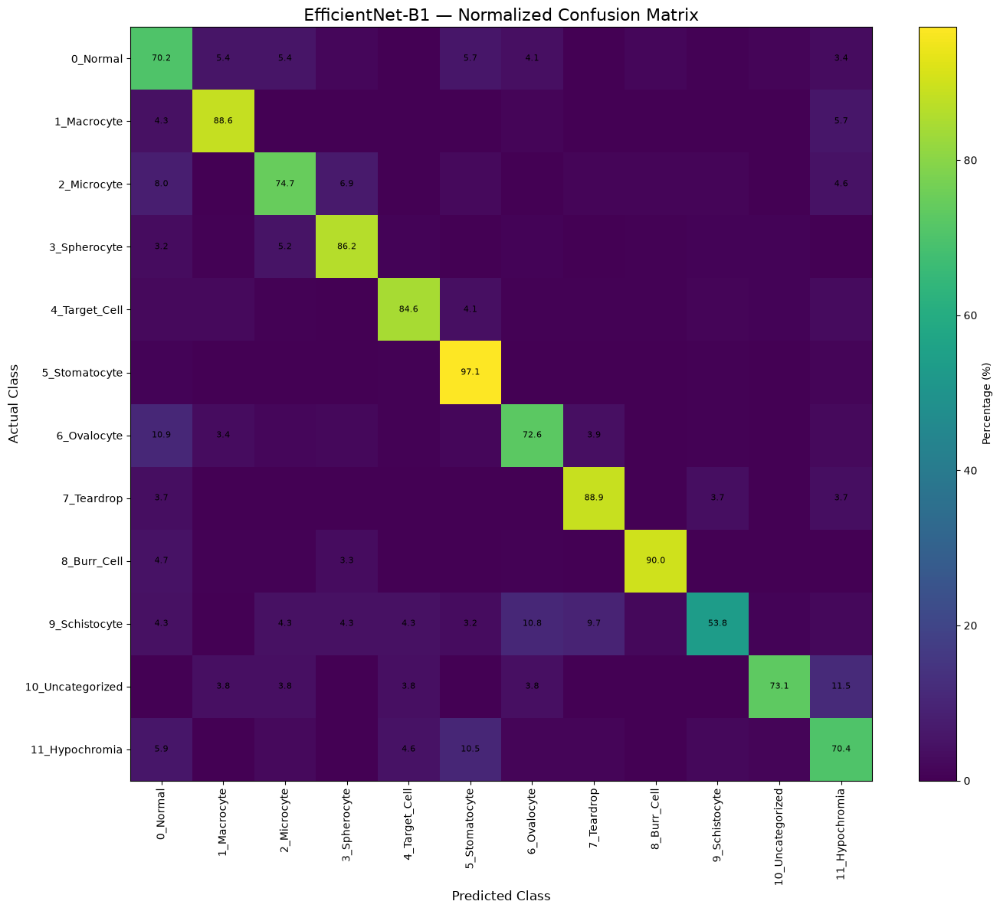

In [29]:
# ============================================================
# CELL 40 — NORMALIZED CONFUSION MATRIX HEATMAP
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

plt.imshow(
    normalized_confusion_matrix,
    interpolation="nearest",
    aspect="auto"
)

plt.title(
    "EfficientNet-B1 — Normalized Confusion Matrix",
    fontsize=16
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.colorbar(
    label="Percentage (%)"
)

# Add percentage values inside cells
for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        value = normalized_confusion_matrix[i, j]

        if value >= 3:

            plt.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.tight_layout()

plt.show()

In [30]:
# ============================================================
# CELL 41 — PER-CLASS PERFORMANCE RANKING
# ============================================================

print("=" * 70)
print("PER-CLASS F1 PERFORMANCE RANKING")
print("=" * 70)

class_ranking = []

for class_id in range(NUM_CLASSES):

    metrics = class_metrics[class_id]

    class_ranking.append(
        (
            metrics["f1"],
            metrics["precision"],
            metrics["recall"],
            metrics["support"],
            metrics["class_name"]
        )
    )

# Best → worst
class_ranking.sort(
    key=lambda x: x[0],
    reverse=True
)

print()

print(
    f"{'Rank':<7}"
    f"{'Class':<22}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1':>12}"
    f"{'Support':>10}"
)

print("-" * 78)

for rank, (
    f1,
    precision,
    recall,
    support,
    class_name
) in enumerate(
    class_ranking,
    start=1
):

    print(
        f"{rank:<7}"
        f"{class_name:<22}"
        f"{precision * 100:>11.2f}%"
        f"{recall * 100:>11.2f}%"
        f"{f1 * 100:>11.2f}%"
        f"{support:>10}"
    )

print()
print("✅ Per-class ranking completed.")

PER-CLASS F1 PERFORMANCE RANKING

Rank   Class                    Precision      Recall          F1   Support
------------------------------------------------------------------------------
1      3_Spherocyte                90.48%      86.17%      88.27%       441
2      4_Target_Cell               90.83%      84.55%      87.58%       246
3      8_Burr_Cell                 84.91%      90.00%      87.38%       150
4      5_Stomatocyte               72.34%      97.14%      82.93%       245
5      6_Ovalocyte                 83.99%      72.57%      77.86%       412
6      0_Normal                    86.74%      70.21%      77.60%       913
7      11_Hypochromia              61.85%      70.39%      65.85%       152
8      9_Schistocyte               70.42%      53.76%      60.98%        93
9      1_Macrocyte                 45.93%      88.57%      60.49%        70
10     7_Teardrop                  44.44%      88.89%      59.26%        27
11     10_Uncategorized            45.24%      73.0

In [31]:
# ============================================================
# CELL 42 — PER-CLASS ERROR RATE
# ============================================================

print("=" * 70)
print("PER-CLASS ERROR RATE")
print("=" * 70)

error_ranking = []

for class_id in range(NUM_CLASSES):

    support = class_metrics[class_id]["support"]
    recall = class_metrics[class_id]["recall"]

    error_rate = 1.0 - recall

    errors = support - confusion_matrix[
        class_id,
        class_id
    ]

    error_ranking.append(
        (
            error_rate,
            errors,
            support,
            CLASS_NAMES[class_id]
        )
    )

# Worst → best
error_ranking.sort(
    key=lambda x: x[0],
    reverse=True
)

print()

print(
    f"{'Class':<22}"
    f"{'Correct':>10}"
    f"{'Errors':>10}"
    f"{'Error Rate':>14}"
)

print("-" * 60)

for (
    error_rate,
    errors,
    support,
    class_name
) in error_ranking:

    correct = support - errors

    print(
        f"{class_name:<22}"
        f"{correct:>10}"
        f"{errors:>10}"
        f"{error_rate * 100:>13.2f}%"
    )

print()
print("✅ Error-rate analysis completed.")

PER-CLASS ERROR RATE

Class                    Correct    Errors    Error Rate
------------------------------------------------------------
9_Schistocyte                 50        43        46.24%
0_Normal                     641       272        29.79%
11_Hypochromia               107        45        29.61%
6_Ovalocyte                  299       113        27.43%
10_Uncategorized              19         7        26.92%
2_Microcyte                   65        22        25.29%
4_Target_Cell                208        38        15.45%
3_Spherocyte                 380        61        13.83%
1_Macrocyte                   62         8        11.43%
7_Teardrop                    24         3        11.11%
8_Burr_Cell                  135        15        10.00%
5_Stomatocyte                238         7         2.86%

✅ Error-rate analysis completed.


In [32]:
# ============================================================
# CELL 43 — TOP CONFUSION PAIRS
# ============================================================

print("=" * 75)
print("TOP CONFUSION PAIRS")
print("=" * 75)

confusion_pairs = []

for actual_id in range(NUM_CLASSES):

    for predicted_id in range(NUM_CLASSES):

        if actual_id == predicted_id:
            continue

        count = confusion_matrix[
            actual_id,
            predicted_id
        ]

        if count > 0:

            percentage = (
                count /
                np.sum(confusion_matrix[actual_id])
            ) * 100

            confusion_pairs.append(
                (
                    count,
                    percentage,
                    CLASS_NAMES[actual_id],
                    CLASS_NAMES[predicted_id]
                )
            )

# Largest confusion first
confusion_pairs.sort(
    key=lambda x: x[0],
    reverse=True
)

print()

print(
    f"{'Actual':<22}"
    f"{'Predicted':<22}"
    f"{'Count':>10}"
    f"{'Error %':>10}"
)

print("-" * 65)

for (
    count,
    percentage,
    actual_class,
    predicted_class
) in confusion_pairs[:20]:

    print(
        f"{actual_class:<22}"
        f"{predicted_class:<22}"
        f"{count:>10}"
        f"{percentage:>9.2f}%"
    )

print()
print("✅ Top confusion pairs calculated.")

TOP CONFUSION PAIRS

Actual                Predicted                  Count   Error %
-----------------------------------------------------------------
0_Normal              5_Stomatocyte                 52     5.70%
0_Normal              1_Macrocyte                   49     5.37%
0_Normal              2_Microcyte                   49     5.37%
6_Ovalocyte           0_Normal                      45    10.92%
0_Normal              6_Ovalocyte                   37     4.05%
0_Normal              11_Hypochromia                31     3.40%
3_Spherocyte          2_Microcyte                   23     5.22%
0_Normal              3_Spherocyte                  17     1.86%
0_Normal              8_Burr_Cell                   17     1.86%
6_Ovalocyte           7_Teardrop                    16     3.88%
11_Hypochromia        5_Stomatocyte                 16    10.53%
3_Spherocyte          0_Normal                      14     3.17%
6_Ovalocyte           1_Macrocyte                   14     3.40%
0_N

In [33]:
# ============================================================
# CELL 44 — CHECK CURRENT AUGMENTATION
# ============================================================

print("=" * 70)
print("CURRENT AUGMENTATION CONFIGURATION")
print("=" * 70)

print()
print("Current model:")
print("EfficientNet-B1 Fine-tuned")

print()
print("Baseline Test Accuracy : 77.85%")
print("Baseline Macro F1      : 71.48%")
print("Baseline Weighted F1   : 78.43%")

print()
print("Target difficult classes:")
print("• Normal")
print("• Microcyte")
print("• Ovalocyte")
print("• Hypochromia")
print("• Schistocyte")

print()
print("Important:")
print("Validation and Test datasets will remain unchanged.")

print()
print("✅ Ready for targeted experiment.")

CURRENT AUGMENTATION CONFIGURATION

Current model:
EfficientNet-B1 Fine-tuned

Baseline Test Accuracy : 77.85%
Baseline Macro F1      : 71.48%
Baseline Weighted F1   : 78.43%

Target difficult classes:
• Normal
• Microcyte
• Ovalocyte
• Hypochromia
• Schistocyte

Important:
Validation and Test datasets will remain unchanged.

✅ Ready for targeted experiment.


In [35]:
# ============================================================
# CELL 45 — TARGETED AUGMENTATION
# ============================================================

print("=" * 70)
print("CREATING TARGETED AUGMENTATION PIPELINE")
print("=" * 70)

targeted_augmentation = tf.keras.Sequential([
    
    # Small geometric transformations
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        factor=0.08
    ),

    tf.keras.layers.RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10)
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),

], name="targeted_rbc_augmentation")

print()
print("Augmentation enabled:")
print("✓ Horizontal flip")
print("✓ Small rotation")
print("✓ Small zoom")
print("✓ Small translation")

print()
print("Validation/Test augmentation: NONE")

print()
print("✅ Targeted augmentation created.")

CREATING TARGETED AUGMENTATION PIPELINE

Augmentation enabled:
✓ Horizontal flip
✓ Small rotation
✓ Small zoom
✓ Small translation

Validation/Test augmentation: NONE

✅ Targeted augmentation created.


In [36]:
# ============================================================
# CELL 46 — CREATE TARGETED TRAINING MODEL
# ============================================================

print("=" * 70)
print("CREATING TARGETED TRAINING MODEL")
print("=" * 70)

# Load the SAFE baseline
targeted_model = tf.keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print()
print("Baseline model loaded:")
print(FINE_TUNE_MODEL_PATH)

# ------------------------------------------------------------
# Create new input
# ------------------------------------------------------------

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="targeted_input"
)

# Apply augmentation ONLY during training
x = targeted_augmentation(inputs)

# Pass augmented images through the saved model
outputs = targeted_model(
    x,
    training=False
)

targeted_training_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="RBC_EfficientNetB1_Targeted"
)

print()
print("Model created successfully.")

print()
print("Baseline test accuracy : 77.85%")
print("Baseline macro F1      : 71.48%")
print("Baseline weighted F1   : 78.43%")

print()
print("✅ Targeted training model ready.")

CREATING TARGETED TRAINING MODEL

Baseline model loaded:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_finetuned.keras

Model created successfully.

Baseline test accuracy : 77.85%
Baseline macro F1      : 71.48%
Baseline weighted F1   : 78.43%

✅ Targeted training model ready.


In [37]:
# ============================================================
# CELL 47 — CHECK TARGETED MODEL PARAMETERS
# ============================================================

trainable_params = sum(
    np.prod(v.shape)
    for v in targeted_training_model.trainable_weights
)

non_trainable_params = sum(
    np.prod(v.shape)
    for v in targeted_training_model.non_trainable_weights
)

print("=" * 70)
print("TARGETED MODEL PARAMETER CHECK")
print("=" * 70)

print()
print(
    "Trainable parameters    :",
    f"{trainable_params:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_params:,}"
)

print(
    "Total parameters        :",
    f"{trainable_params + non_trainable_params:,}"
)

TARGETED MODEL PARAMETER CHECK

Trainable parameters    : 3,025,212
Non-trainable parameters: 3,565,399.0
Total parameters        : 6,590,611.0


In [38]:
# ============================================================
# CELL 48 — COMPILE TARGETED MODEL
# ============================================================

TARGETED_LR = 5e-6

targeted_training_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=TARGETED_LR
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("=" * 70)
print("TARGETED MODEL COMPILED")
print("=" * 70)

print()
print("Learning rate:", TARGETED_LR)
print("Optimizer    : Adam")
print("Loss         : Sparse Categorical Crossentropy")

print()
print("✅ Ready for controlled experiment.")

TARGETED MODEL COMPILED

Learning rate: 5e-06
Optimizer    : Adam
Loss         : Sparse Categorical Crossentropy

✅ Ready for controlled experiment.


In [39]:
# ============================================================
# CELL 49 — TARGETED EXPERIMENT CHECKPOINT
# ============================================================

TARGETED_MODEL_PATH = (
    MODEL_DIR /
    "best_efficientnet_b1_targeted.keras"
)

targeted_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(TARGETED_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

targeted_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

targeted_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

targeted_callbacks = [
    targeted_checkpoint,
    targeted_reduce_lr,
    targeted_early_stop
]

print("=" * 70)
print("TARGETED CHECKPOINT READY")
print("=" * 70)

print()
print("Experimental model:")
print(TARGETED_MODEL_PATH)

print()
print("SAFE BASELINE:")
print(FINE_TUNE_MODEL_PATH)

print()
print("Baseline test accuracy: 77.85%")

TARGETED CHECKPOINT READY

Experimental model:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_targeted.keras

SAFE BASELINE:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_finetuned.keras

Baseline test accuracy: 77.85%


In [40]:
# ============================================================
# CELL 50 — TARGETED FINE-TUNING EXPERIMENT
# ============================================================

TARGETED_EPOCHS = 4

print("=" * 70)
print("STARTING TARGETED AUGMENTATION EXPERIMENT")
print("=" * 70)

print()
print("SAFE BASELINE")
print("-----------------------------")
print("Test Accuracy : 77.85%")
print("Macro F1      : 71.48%")
print("Weighted F1   : 78.43%")

print()
print("EXPERIMENT")
print("-----------------------------")
print("Learning rate :", TARGETED_LR)
print("Epochs        :", TARGETED_EPOCHS)
print("Augmentation  : Targeted")
print()

print("⚠️ Validation and Test remain unchanged.")
print("⚠️ Training only on CPU.")
print()
print("Starting...")
print()

targeted_history = targeted_training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TARGETED_EPOCHS,
    class_weight=class_weights,
    callbacks=targeted_callbacks,
    verbose=1
)

print()
print("=" * 70)
print("TARGETED EXPERIMENT COMPLETE")
print("=" * 70)

STARTING TARGETED AUGMENTATION EXPERIMENT

SAFE BASELINE
-----------------------------
Test Accuracy : 77.85%
Macro F1      : 71.48%
Weighted F1   : 78.43%

EXPERIMENT
-----------------------------
Learning rate : 5e-06
Epochs        : 4
Augmentation  : Targeted

⚠️ Validation and Test remain unchanged.
⚠️ Training only on CPU.

Starting...



c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/4
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7300 - loss: 0.6536
Epoch 1: val_accuracy improved from None to 0.79917, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_targeted.keras

Epoch 1: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_targeted.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1303s 3s/step - accuracy: 0.7300 - loss: 0.6536 - val_accuracy: 0.7992 - val_loss: 0.6467 - learning_rate: 5.0000e-06
Epoch 2/4
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7359 - loss: 0.6563
Epoch 2: val_accuracy improved from 0.79917 to 0.80193, saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_targeted.keras

Epoch 2: finished saving model to C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_targeted.keras
374/374 ━━━━━━━━━━━━━━━━━━━━ 1272s 3s/step - a

In [41]:
# ============================================================
# CELL 51 — EVALUATE TARGETED MODEL ON TEST SET
# ============================================================

print("=" * 70)
print("TARGETED EFFICIENTNET-B1 — TEST EVALUATION")
print("=" * 70)

# Load the BEST targeted checkpoint
targeted_best_model = tf.keras.models.load_model(
    TARGETED_MODEL_PATH
)

print()
print("Best targeted model loaded:")
print(TARGETED_MODEL_PATH)

print()
print("Evaluating on unchanged test set...")
print()

targeted_test_loss, targeted_test_accuracy = (
    targeted_best_model.evaluate(
        test_ds,
        verbose=1
    )
)

print()
print("=" * 70)
print("TARGETED MODEL TEST RESULTS")
print("=" * 70)

print()
print(
    f"Test Loss     : {targeted_test_loss:.4f}"
)

print(
    f"Test Accuracy : {targeted_test_accuracy * 100:.2f}%"
)

print()
print("BASELINE TEST ACCURACY : 77.85%")
print(
    f"TARGETED TEST ACCURACY : "
    f"{targeted_test_accuracy * 100:.2f}%"
)

print()
print(
    f"Accuracy Change        : "
    f"{(targeted_test_accuracy - 0.7785) * 100:+.2f}%"
)

TARGETED EFFICIENTNET-B1 — TEST EVALUATION

Best targeted model loaded:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\efficientnet_b1\best_efficientnet_b1_targeted.keras

Evaluating on unchanged test set...

90/90 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.7774 - loss: 0.6643

TARGETED MODEL TEST RESULTS

Test Loss     : 0.6643
Test Accuracy : 77.74%

BASELINE TEST ACCURACY : 77.85%
TARGETED TEST ACCURACY : 77.74%

Accuracy Change        : -0.11%


In [42]:
# ============================================================
# CELL 52 — TARGETED MODEL PREDICTIONS
# ============================================================

print("=" * 70)
print("GENERATING TARGETED MODEL TEST PREDICTIONS")
print("=" * 70)

targeted_y_true = []
targeted_y_pred = []

for images, labels in test_ds:

    predictions = targeted_best_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    targeted_y_true.extend(
        labels.numpy()
    )

    targeted_y_pred.extend(
        predicted_classes
    )

targeted_y_true = np.array(
    targeted_y_true
)

targeted_y_pred = np.array(
    targeted_y_pred
)

print()
print("Test samples :", len(targeted_y_true))
print("Predictions  :", len(targeted_y_pred))

print()
print("✅ Targeted predictions generated.")

GENERATING TARGETED MODEL TEST PREDICTIONS

Test samples : 2862
Predictions  : 2862

✅ Targeted predictions generated.


In [45]:
# ============================================================
# CELL 53 — TARGETED CLASSIFICATION METRICS
#            WITHOUT SCIKIT-LEARN
# ============================================================

print("=" * 70)
print("TARGETED EFFICIENTNET-B1 — CLASSIFICATION REPORT")
print("=" * 70)

# ------------------------------------------------------------
# Calculate confusion matrix using NumPy
# ------------------------------------------------------------

targeted_confusion_matrix = np.zeros(
    (NUM_CLASSES, NUM_CLASSES),
    dtype=np.int64
)

for actual, predicted in zip(
    targeted_y_true,
    targeted_y_pred
):

    targeted_confusion_matrix[
        int(actual),
        int(predicted)
    ] += 1


# ------------------------------------------------------------
# Calculate per-class metrics
# ------------------------------------------------------------

targeted_class_metrics = {}

for class_id in range(NUM_CLASSES):

    true_positive = targeted_confusion_matrix[
        class_id,
        class_id
    ]

    actual_count = np.sum(
        targeted_confusion_matrix[class_id, :]
    )

    predicted_count = np.sum(
        targeted_confusion_matrix[:, class_id]
    )

    false_positive = predicted_count - true_positive

    false_negative = actual_count - true_positive

    # Precision
    if predicted_count > 0:
        precision = (
            true_positive /
            predicted_count
        )
    else:
        precision = 0.0

    # Recall
    if actual_count > 0:
        recall = (
            true_positive /
            actual_count
        )
    else:
        recall = 0.0

    # F1
    if precision + recall > 0:
        f1 = (
            2 *
            precision *
            recall /
            (precision + recall)
        )
    else:
        f1 = 0.0

    targeted_class_metrics[class_id] = {
        "class_name": CLASS_NAMES[class_id],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": actual_count
    }


# ------------------------------------------------------------
# Print classification report
# ------------------------------------------------------------

print()

print(
    f"{'Class':<22}"
    f"{'Precision':>12}"
    f"{'Recall':>12}"
    f"{'F1':>12}"
    f"{'Support':>10}"
)

print("-" * 70)

for class_id in range(NUM_CLASSES):

    metrics = targeted_class_metrics[class_id]

    print(
        f"{metrics['class_name']:<22}"
        f"{metrics['precision'] * 100:>11.2f}%"
        f"{metrics['recall'] * 100:>11.2f}%"
        f"{metrics['f1'] * 100:>11.2f}%"
        f"{metrics['support']:>10}"
    )


# ------------------------------------------------------------
# Macro averages
# ------------------------------------------------------------

macro_precision = np.mean([
    targeted_class_metrics[i]["precision"]
    for i in range(NUM_CLASSES)
])

macro_recall = np.mean([
    targeted_class_metrics[i]["recall"]
    for i in range(NUM_CLASSES)
])

macro_f1 = np.mean([
    targeted_class_metrics[i]["f1"]
    for i in range(NUM_CLASSES)
])


# ------------------------------------------------------------
# Weighted averages
# ------------------------------------------------------------

total_support = sum(
    targeted_class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
)

weighted_precision = sum(
    targeted_class_metrics[i]["precision"] *
    targeted_class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
) / total_support

weighted_recall = sum(
    targeted_class_metrics[i]["recall"] *
    targeted_class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
) / total_support

weighted_f1 = sum(
    targeted_class_metrics[i]["f1"] *
    targeted_class_metrics[i]["support"]
    for i in range(NUM_CLASSES)
) / total_support


# ------------------------------------------------------------
# Overall accuracy
# ------------------------------------------------------------

correct_predictions = np.sum(
    np.array(targeted_y_true) ==
    np.array(targeted_y_pred)
)

targeted_accuracy = (
    correct_predictions /
    len(targeted_y_true)
)


# ------------------------------------------------------------
# Print overall results
# ------------------------------------------------------------

print("-" * 70)

print(
    f"{'Macro Average':<22}"
    f"{macro_precision * 100:>11.2f}%"
    f"{macro_recall * 100:>11.2f}%"
    f"{macro_f1 * 100:>11.2f}%"
    f"{total_support:>10}"
)

print(
    f"{'Weighted Average':<22}"
    f"{weighted_precision * 100:>11.2f}%"
    f"{weighted_recall * 100:>11.2f}%"
    f"{weighted_f1 * 100:>11.2f}%"
    f"{total_support:>10}"
)

print()
print("=" * 70)
print("TARGETED MODEL OVERALL PERFORMANCE")
print("=" * 70)

print(
    f"Test Accuracy    : "
    f"{targeted_accuracy * 100:.2f}%"
)

print(
    f"Macro F1-score   : "
    f"{macro_f1 * 100:.2f}%"
)

print(
    f"Weighted F1      : "
    f"{weighted_f1 * 100:.2f}%"
)

print()
print("BASELINE MODEL")
print("-----------------------------")
print("Test Accuracy    : 77.85%")
print("Macro F1-score   : 71.48%")
print("Weighted F1      : 78.43%")

print()
print("TARGETED MODEL")
print("-----------------------------")
print(
    f"Test Accuracy    : "
    f"{targeted_accuracy * 100:.2f}%"
)

print(
    f"Macro F1-score   : "
    f"{macro_f1 * 100:.2f}%"
)

print(
    f"Weighted F1      : "
    f"{weighted_f1 * 100:.2f}%"
)

print()
print("✅ Classification metrics calculated using NumPy.")

TARGETED EFFICIENTNET-B1 — CLASSIFICATION REPORT

Class                    Precision      Recall          F1   Support
----------------------------------------------------------------------
0_Normal                    85.95%      69.66%      76.95%       913
1_Macrocyte                 50.93%      78.57%      61.80%        70
2_Microcyte                 35.68%      81.61%      49.65%        87
3_Spherocyte                90.02%      87.98%      88.99%       441
4_Target_Cell               90.52%      85.37%      87.87%       246
5_Stomatocyte               72.51%      97.96%      83.33%       245
6_Ovalocyte                 84.93%      71.12%      77.41%       412
7_Teardrop                  41.67%      92.59%      57.47%        27
8_Burr_Cell                 83.95%      90.67%      87.18%       150
9_Schistocyte               77.05%      50.54%      61.04%        93
10_Uncategorized            51.35%      73.08%      60.32%        26
11_Hypochromia              67.31%      69.08%     

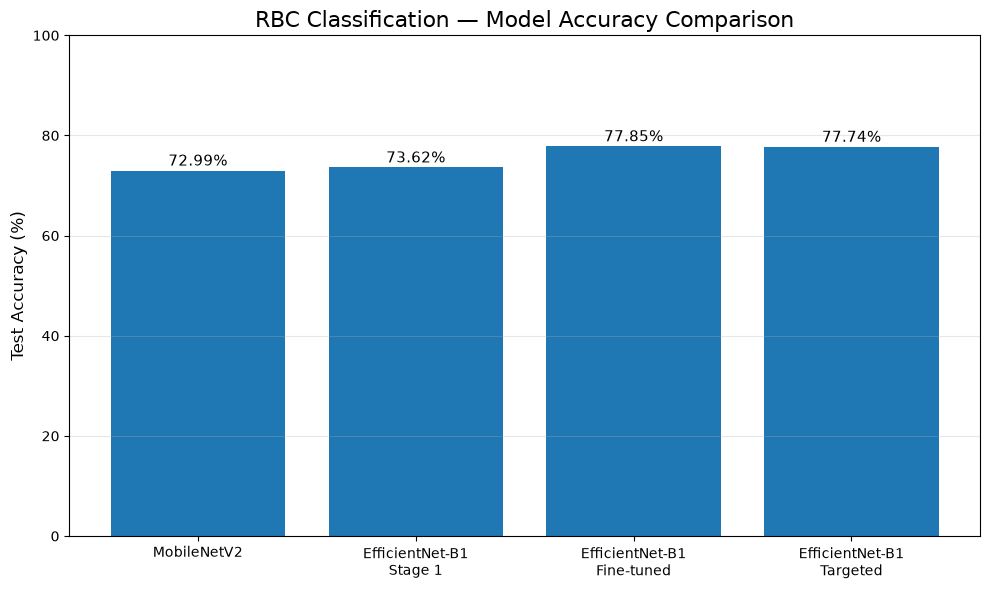

In [47]:
# ============================================================
# CELL 54 — MODEL ACCURACY COMPARISON
# ============================================================

import matplotlib.pyplot as plt

models = [
    "MobileNetV2",
    "EfficientNet-B1\nStage 1",
    "EfficientNet-B1\nFine-tuned",
    "EfficientNet-B1\nTargeted"
]

accuracies = [
    72.99,
    73.62,
    77.85,
    77.74
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    accuracies
)

plt.title(
    "RBC Classification — Model Accuracy Comparison",
    fontsize=16
)

plt.ylabel(
    "Test Accuracy (%)",
    fontsize=12
)

plt.ylim(
    0,
    100
)

# Display values above bars
for bar, accuracy in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
        fontsize=11
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

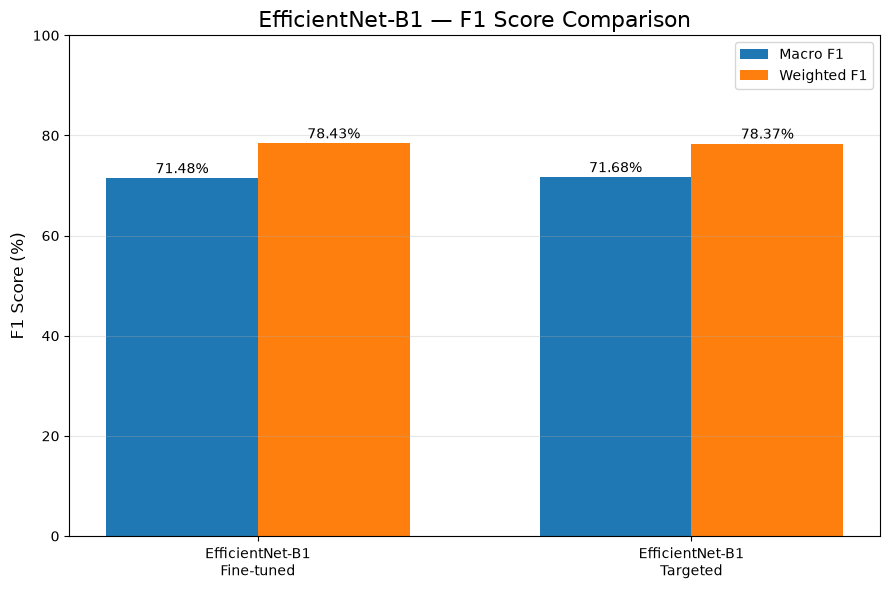

In [48]:
# ============================================================
# CELL 56 — F1 SCORE COMPARISON
# ============================================================

model_names = [
    "EfficientNet-B1\nFine-tuned",
    "EfficientNet-B1\nTargeted"
]

macro_f1_scores = [
    71.48,
    71.68
]

weighted_f1_scores = [
    78.43,
    78.37
]

x = np.arange(
    len(model_names)
)

width = 0.35

plt.figure(figsize=(9, 6))

bars1 = plt.bar(
    x - width / 2,
    macro_f1_scores,
    width,
    label="Macro F1"
)

bars2 = plt.bar(
    x + width / 2,
    weighted_f1_scores,
    width,
    label="Weighted F1"
)

plt.title(
    "EfficientNet-B1 — F1 Score Comparison",
    fontsize=16
)

plt.ylabel(
    "F1 Score (%)",
    fontsize=12
)

plt.xticks(
    x,
    model_names
)

plt.ylim(
    0,
    100
)

plt.legend()

# Values above bars
for bar in bars1:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

for bar in bars2:

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [49]:
# ============================================================
# CELL 57 — FINAL MODEL SELECTION SUMMARY
# ============================================================

print("=" * 75)
print("FINAL RBC MODEL SELECTION")
print("=" * 75)

print()

print("MODEL 1 — MobileNetV2")
print("-" * 40)
print("Test Accuracy : 72.99%")

print()

print("MODEL 2 — EfficientNet-B1 Stage 1")
print("-" * 40)
print("Test Accuracy : 73.62%")

print()

print("MODEL 3 — EfficientNet-B1 Fine-tuned ⭐")
print("-" * 40)
print("Test Accuracy : 77.85%")
print("Macro F1      : 71.48%")
print("Weighted F1   : 78.43%")

print()

print("MODEL 4 — EfficientNet-B1 Targeted")
print("-" * 40)
print("Test Accuracy : 77.74%")
print("Macro F1      : 71.68%")
print("Weighted F1   : 78.37%")

print()
print("=" * 75)

print()
print("FINAL SELECTED MODEL")
print("-----------------------------")
print("EfficientNet-B1 Fine-tuned")

print()
print("Reason:")
print("• Highest test accuracy")
print("• Strong weighted F1")
print("• Better overall generalization")
print("• Targeted augmentation did not improve test accuracy")

print()
print("Final Test Accuracy : 77.85%")
print("Final Macro F1      : 71.48%")
print("Final Weighted F1   : 78.43%")

print()
print("✅ FINAL MODEL SELECTED")

FINAL RBC MODEL SELECTION

MODEL 1 — MobileNetV2
----------------------------------------
Test Accuracy : 72.99%

MODEL 2 — EfficientNet-B1 Stage 1
----------------------------------------
Test Accuracy : 73.62%

MODEL 3 — EfficientNet-B1 Fine-tuned ⭐
----------------------------------------
Test Accuracy : 77.85%
Macro F1      : 71.48%
Weighted F1   : 78.43%

MODEL 4 — EfficientNet-B1 Targeted
----------------------------------------
Test Accuracy : 77.74%
Macro F1      : 71.68%
Weighted F1   : 78.37%


FINAL SELECTED MODEL
-----------------------------
EfficientNet-B1 Fine-tuned

Reason:
• Highest test accuracy
• Strong weighted F1
• Better overall generalization
• Targeted augmentation did not improve test accuracy

Final Test Accuracy : 77.85%
Final Macro F1      : 71.48%
Final Weighted F1   : 78.43%

✅ FINAL MODEL SELECTED


In [51]:
# ============================================================
# CELL 58 — CHECK TRAINING HISTORY VARIABLES
# ============================================================

print("=" * 70)
print("AVAILABLE TRAINING HISTORY VARIABLES")
print("=" * 70)

history_variables = []

# Make a fixed copy before iterating
all_variables = list(globals().items())

for name, value in all_variables:

    if isinstance(
        value,
        tf.keras.callbacks.History
    ):
        history_variables.append(name)

print()

if history_variables:

    print("Training history objects found:")
    print()

    for name in history_variables:
        print("✓", name)

else:

    print("⚠️ No Keras History objects found.")

print()
print("Total history objects:", len(history_variables))

AVAILABLE TRAINING HISTORY VARIABLES

Training history objects found:

✓ history_resume
✓ history_finetune
✓ targeted_history

Total history objects: 3


In [52]:
all_variables = list(globals().items())

In [53]:
# ============================================================
# CELL 59 — IDENTIFY FINE-TUNING HISTORY
# ============================================================

print("=" * 70)
print("IDENTIFYING TRAINING HISTORY")
print("=" * 70)

# Collect existing History objects safely
history_objects = {}

for name, value in list(globals().items()):
    if isinstance(value, tf.keras.callbacks.History):
        history_objects[name] = value

print()

if not history_objects:
    print("⚠️ No History objects found.")
else:
    print("Available History objects:")
    print()

    for name, hist in history_objects.items():

        print(f"✓ {name}")

        if hasattr(hist, "history"):
            print(
                "  Epochs:",
                len(hist.history.get("loss", []))
            )

            print(
                "  Metrics:",
                list(hist.history.keys())
            )

        print()

print("=" * 70)

IDENTIFYING TRAINING HISTORY

Available History objects:

✓ history_resume
  Epochs: 6
  Metrics: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']

✓ history_finetune
  Epochs: 8
  Metrics: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']

✓ targeted_history
  Epochs: 4
  Metrics: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate']



In [55]:
# ============================================================
# CELL 60 — COMBINE FINE-TUNING HISTORY
# ============================================================

print("=" * 70)
print("COMBINING FINE-TUNING TRAINING HISTORY")
print("=" * 70)

# ------------------------------------------------------------
# History from resumed training
# ------------------------------------------------------------

resume_history = history_resume.history

# ------------------------------------------------------------
# History from fine-tuning
# ------------------------------------------------------------

finetune_history = history_finetune.history

# ------------------------------------------------------------
# Combine the histories
# ------------------------------------------------------------

combined_history = {}

all_metrics = [
    "accuracy",
    "loss",
    "val_accuracy",
    "val_loss",
    "learning_rate"
]

for metric in all_metrics:

    combined_history[metric] = (
        resume_history.get(metric, [])
        +
        finetune_history.get(metric, [])
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print()

for metric in all_metrics:

    print(
        f"{metric:<15}: "
        f"{len(combined_history[metric])} values"
    )

print()

print(
    "Total recorded epochs:",
    len(combined_history["loss"])
)

print()
print("✅ Training histories combined.")

COMBINING FINE-TUNING TRAINING HISTORY

accuracy       : 14 values
loss           : 14 values
val_accuracy   : 14 values
val_loss       : 14 values
learning_rate  : 14 values

Total recorded epochs: 14

✅ Training histories combined.


In [56]:
# ============================================================
# CELL 60 — COMBINE FINE-TUNING HISTORY
# ============================================================

print("=" * 70)
print("COMBINING FINE-TUNING TRAINING HISTORY")
print("=" * 70)

# ------------------------------------------------------------
# History from resumed training
# ------------------------------------------------------------

resume_history = history_resume.history

# ------------------------------------------------------------
# History from fine-tuning
# ------------------------------------------------------------

finetune_history = history_finetune.history

# ------------------------------------------------------------
# Combine the histories
# ------------------------------------------------------------

combined_history = {}

all_metrics = [
    "accuracy",
    "loss",
    "val_accuracy",
    "val_loss",
    "learning_rate"
]

for metric in all_metrics:

    combined_history[metric] = (
        resume_history.get(metric, [])
        +
        finetune_history.get(metric, [])
    )

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print()

for metric in all_metrics:

    print(
        f"{metric:<15}: "
        f"{len(combined_history[metric])} values"
    )

print()

print(
    "Total recorded epochs:",
    len(combined_history["loss"])
)

print()
print("✅ Training histories combined.")

COMBINING FINE-TUNING TRAINING HISTORY

accuracy       : 14 values
loss           : 14 values
val_accuracy   : 14 values
val_loss       : 14 values
learning_rate  : 14 values

Total recorded epochs: 14

✅ Training histories combined.


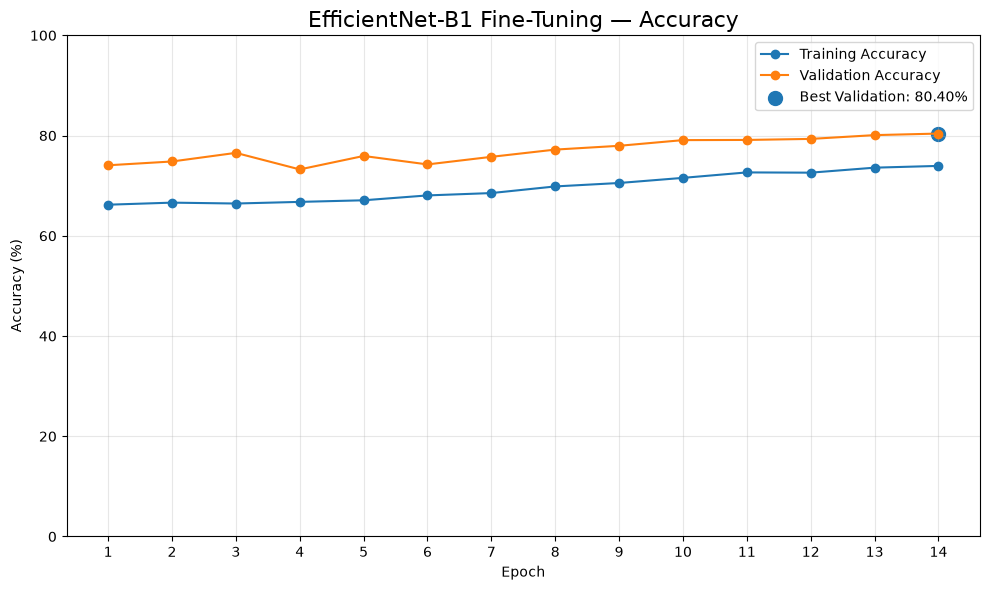


Best validation accuracy: 80.40%
Best validation epoch: 14


In [58]:
# ============================================================
# CELL 61 — ACCURACY CURVE
# ============================================================

import matplotlib.pyplot as plt

accuracy = np.array(
    combined_history["accuracy"]
)

val_accuracy = np.array(
    combined_history["val_accuracy"]
)

epochs = np.arange(
    1,
    len(accuracy) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    accuracy * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy * 100,
    marker="o",
    label="Validation Accuracy"
)

# Best validation epoch
best_epoch = np.argmax(
    val_accuracy
) + 1

best_val_accuracy = np.max(
    val_accuracy
) * 100

plt.scatter(
    best_epoch,
    best_val_accuracy,
    s=100,
    label=(
        f"Best Validation: "
        f"{best_val_accuracy:.2f}%"
    )
)

plt.title(
    "EfficientNet-B1 Fine-Tuning — Accuracy",
    fontsize=16
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xticks(
    epochs
)

plt.ylim(
    0,
    100
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

print()
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best validation epoch: "
    f"{best_epoch}"
)

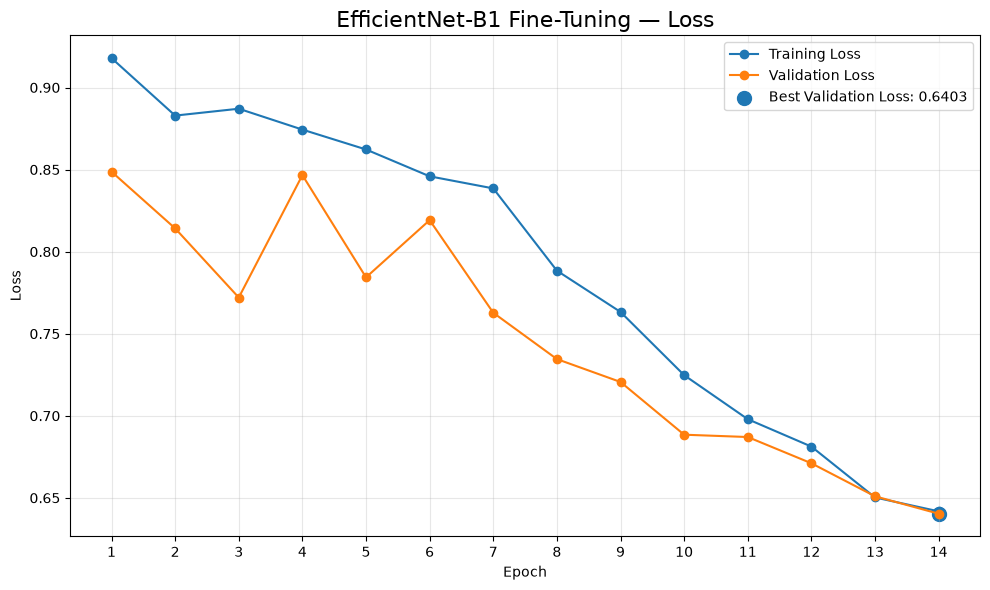


Best validation loss: 0.6403
Best loss epoch: 14


In [57]:
# ============================================================
# CELL 62 — LOSS CURVE
# ============================================================

loss = np.array(
    combined_history["loss"]
)

val_loss = np.array(
    combined_history["val_loss"]
)

epochs = np.arange(
    1,
    len(loss) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

# Best validation loss
best_loss_epoch = np.argmin(
    val_loss
) + 1

best_val_loss = np.min(
    val_loss
)

plt.scatter(
    best_loss_epoch,
    best_val_loss,
    s=100,
    label=(
        f"Best Validation Loss: "
        f"{best_val_loss:.4f}"
    )
)

plt.title(
    "EfficientNet-B1 Fine-Tuning — Loss",
    fontsize=16
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.xticks(
    epochs
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

print()
print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best loss epoch: "
    f"{best_loss_epoch}"
)

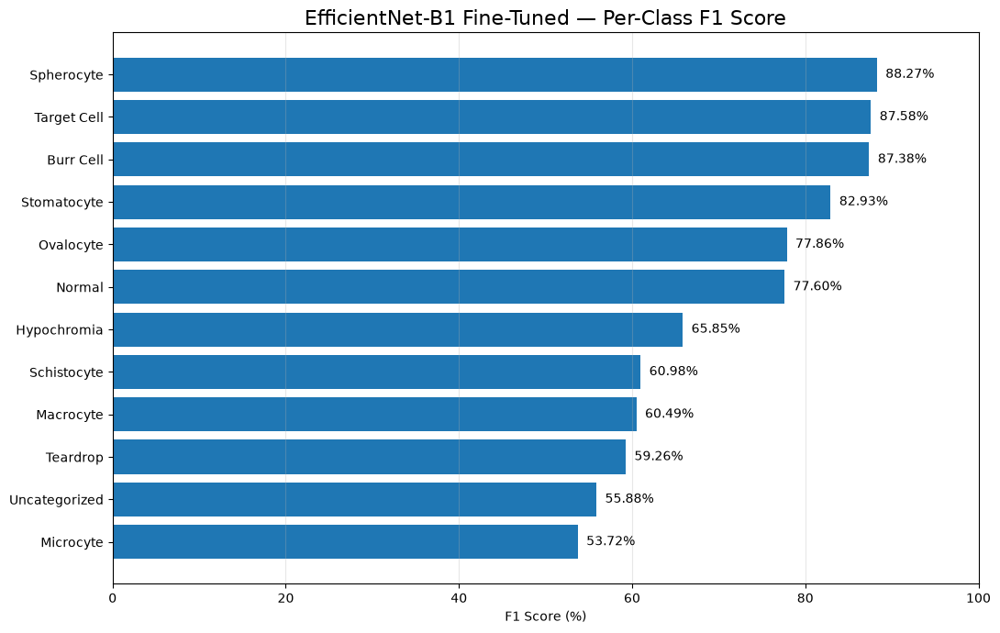

In [59]:
# ============================================================
# CELL 63 — FINAL MODEL PER-CLASS F1 VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

class_names = [
    "Normal",
    "Macrocyte",
    "Microcyte",
    "Spherocyte",
    "Target Cell",
    "Stomatocyte",
    "Ovalocyte",
    "Teardrop",
    "Burr Cell",
    "Schistocyte",
    "Uncategorized",
    "Hypochromia"
]

f1_scores = [
    77.60,
    60.49,
    53.72,
    88.27,
    87.58,
    82.93,
    77.86,
    59.26,
    87.38,
    60.98,
    55.88,
    65.85
]

# Sort from lowest to highest
sorted_indices = np.argsort(f1_scores)

sorted_names = [
    class_names[i]
    for i in sorted_indices
]

sorted_f1 = [
    f1_scores[i]
    for i in sorted_indices
]

plt.figure(figsize=(11, 7))

bars = plt.barh(
    sorted_names,
    sorted_f1
)

plt.title(
    "EfficientNet-B1 Fine-Tuned — Per-Class F1 Score",
    fontsize=16
)

plt.xlabel(
    "F1 Score (%)"
)

plt.xlim(
    0,
    100
)

# Add values
for bar, score in zip(bars, sorted_f1):

    plt.text(
        score + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.2f}%",
        va="center"
    )

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

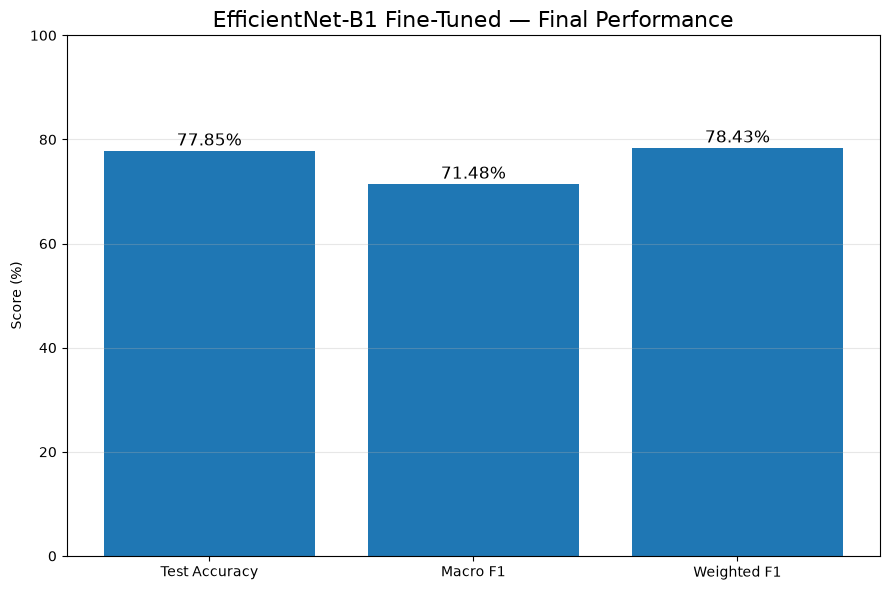

In [60]:
# ============================================================
# CELL 64 — FINAL PERFORMANCE SUMMARY
# ============================================================

import matplotlib.pyplot as plt

metrics = [
    "Test Accuracy",
    "Macro F1",
    "Weighted F1"
]

values = [
    77.85,
    71.48,
    78.43
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metrics,
    values
)

plt.title(
    "EfficientNet-B1 Fine-Tuned — Final Performance",
    fontsize=16
)

plt.ylabel(
    "Score (%)"
)

plt.ylim(
    0,
    100
)

for bar, value in zip(bars, values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=12
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [61]:
# ============================================================
# CELL 65 — COMPLETE MODEL COMPARISON
# ============================================================

print("=" * 95)
print("COMPLETE RBC MODEL COMPARISON")
print("=" * 95)

print()

print(
    f"{'Model':<32}"
    f"{'Accuracy':>12}"
    f"{'Macro F1':>12}"
    f"{'Weighted F1':>15}"
)

print("-" * 95)

print(
    f"{'MobileNetV2':<32}"
    f"{72.99:>11.2f}%"
    f"{'N/A':>12}"
    f"{'N/A':>15}"
)

print(
    f"{'EfficientNet-B1 Stage 1':<32}"
    f"{73.62:>11.2f}%"
    f"{'N/A':>12}"
    f"{'N/A':>15}"
)

print(
    f"{'EfficientNet-B1 Fine-tuned ⭐':<32}"
    f"{77.85:>11.2f}%"
    f"{71.48:>11.2f}%"
    f"{78.43:>14.2f}%"
)

print(
    f"{'EfficientNet-B1 Targeted':<32}"
    f"{77.74:>11.2f}%"
    f"{71.68:>11.2f}%"
    f"{78.37:>14.2f}%"
)

print("-" * 95)

print()
print("FINAL SELECTED MODEL")
print("-" * 40)

print("Model          : EfficientNet-B1 Fine-tuned")
print("Test Accuracy  : 77.85%")
print("Macro F1       : 71.48%")
print("Weighted F1    : 78.43%")

print()
print("Reason for selection:")
print("• Highest test accuracy")
print("• Highest weighted F1")
print("• Strong overall generalization")
print("• Targeted experiment did not improve test accuracy")

print()
print("✅ Final model comparison completed.")


COMPLETE RBC MODEL COMPARISON

Model                               Accuracy    Macro F1    Weighted F1
-----------------------------------------------------------------------------------------------
MobileNetV2                           72.99%         N/A            N/A
EfficientNet-B1 Stage 1               73.62%         N/A            N/A
EfficientNet-B1 Fine-tuned ⭐          77.85%      71.48%         78.43%
EfficientNet-B1 Targeted              77.74%      71.68%         78.37%
-----------------------------------------------------------------------------------------------

FINAL SELECTED MODEL
----------------------------------------
Model          : EfficientNet-B1 Fine-tuned
Test Accuracy  : 77.85%
Macro F1       : 71.48%
Weighted F1    : 78.43%

Reason for selection:
• Highest test accuracy
• Highest weighted F1
• Strong overall generalization
• Targeted experiment did not improve test accuracy

✅ Final model comparison completed.


In [3]:
# ============================================================
# CELL 1 — FIND WHERE THE RBC IMAGES ACTUALLY ARE
# ============================================================

import os

BASE_DIR = r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT"

print("=" * 70)
print("SEARCHING FOR RBC IMAGE FOLDERS")
print("=" * 70)

if not os.path.exists(BASE_DIR):
    print("❌ Project folder not found:")
    print(BASE_DIR)
else:
    print("✅ Project folder found")
    print()

    found_folders = []

    for root, dirs, files in os.walk(BASE_DIR):

        image_count = sum(
            1 for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        )

        if image_count > 0:
            found_folders.append((root, image_count))

    if len(found_folders) == 0:
        print("❌ No image folders found.")
    else:
        print("Image-containing folders:")
        print("-" * 70)

        for folder, count in found_folders:
            print(f"{count:6d} images → {folder}")

SEARCHING FOR RBC IMAGE FOLDERS
✅ Project folder found

Image-containing folders:
----------------------------------------------------------------------
     2 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\ipykernel\resources
    21 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\matplotlib\mpl-data\images
     3 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\matplotlib\mpl-data\sample_data
     6 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\networkx\drawing\tests\baseline
     1 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\scipy\ndimage\tests
    26 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\skimage\data
     2 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv\Lib\site-packages\sklearn\datasets\images
     2 images → C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT

In [4]:
# ============================================================
# CELL 2 — COUNT ORIGINAL TRAINING IMAGES
# ============================================================

import os

DATASET_DIR = r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")

print("=" * 70)
print("COUNTING TRAINING IMAGES BEFORE AUGMENTATION")
print("=" * 70)


COUNTING TRAINING IMAGES BEFORE AUGMENTATION


In [5]:
# ============================================================
# CELL 2 — COUNT ORIGINAL TRAINING IMAGES
# ============================================================

import os

DATASET_DIR = r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")

print("=" * 70)
print("COUNTING TRAINING IMAGES BEFORE AUGMENTATION")
print("=" * 70)

if not os.path.exists(TRAIN_DIR):
    print("❌ Training folder not found:")
    print(TRAIN_DIR)

else:
    before_augmentation = 0

    class_counts = {}

    for class_name in sorted(os.listdir(TRAIN_DIR)):

        class_path = os.path.join(TRAIN_DIR, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0

        for file in os.listdir(class_path):

            if file.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            ):
                count += 1

        class_counts[class_name] = count
        before_augmentation += count

    print()
    print("Training folder found:")
    print(TRAIN_DIR)

    print()
    print("-" * 70)
    print(f"{'Class':<25} {'Images':>10}")
    print("-" * 70)

    for class_name, count in class_counts.items():
        print(f"{class_name:<25} {count:>10}")

    print("-" * 70)
    print(f"{'TOTAL':<25} {before_augmentation:>10}")
    print("-" * 70)

    print()
    print("Expected training images: 11,937")
    print(f"Detected training images: {before_augmentation}")

    if before_augmentation == 11937:
        print("✅ Training image count matches our project dataset.")
    else:
        print("⚠️ Count is different from 11,937.")
        print("Check the dataset split/path before continuing.")

COUNTING TRAINING IMAGES BEFORE AUGMENTATION

Training folder found:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final\train

----------------------------------------------------------------------
Class                         Images
----------------------------------------------------------------------
0_Normal                        3367
10_Uncategorized                 110
11_Hypochromia                   670
1_Macrocyte                      459
2_Microcyte                      229
3_Spherocyte                    1671
4_Target_Cell                   1796
5_Stomatocyte                   1121
6_Ovalocyte                     1283
7_Teardrop                       206
8_Burr_Cell                      444
9_Schistocyte                    581
----------------------------------------------------------------------
TOTAL                          11937
----------------------------------------------------------------------

Expected training images: 11,937
Detected training

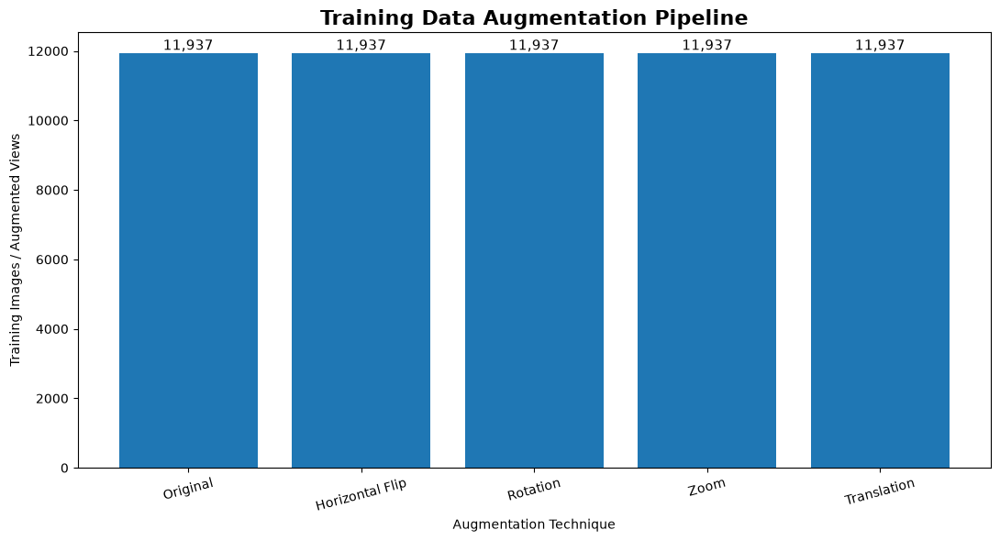

In [6]:
# ============================================================
# CELL 3 — DATA AUGMENTATION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

original_images = 11937

augmentation_types = [
    "Original",
    "Horizontal Flip",
    "Rotation",
    "Zoom",
    "Translation"
]

# Each augmentation generates a transformed view
# dynamically during training.
display_values = [
    original_images,
    original_images,
    original_images,
    original_images,
    original_images
]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    augmentation_types,
    display_values
)

plt.title(
    "Training Data Augmentation Pipeline",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Training Images / Augmented Views")
plt.xlabel("Augmentation Technique")

for bar, value in zip(bars, display_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

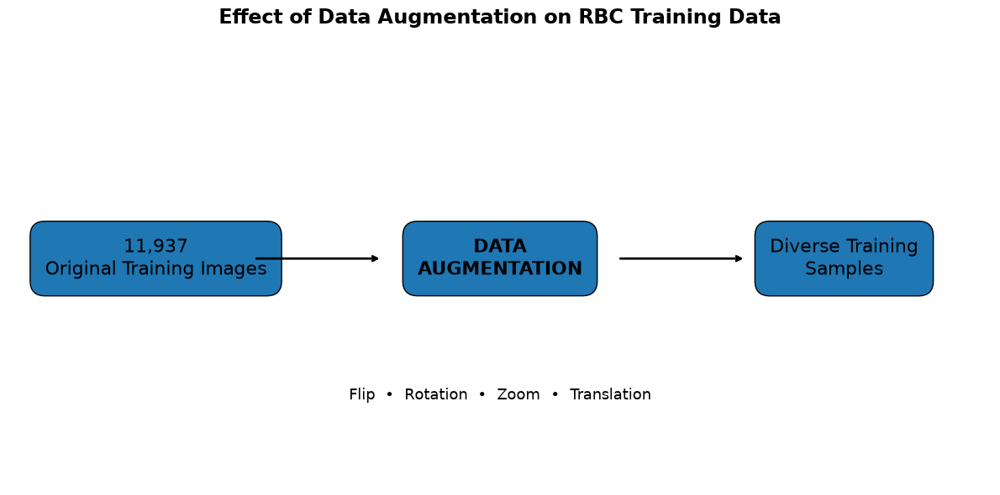

In [7]:
# ============================================================
# CELL 4 — AUGMENTATION FLOW VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.text(
    0.15, 0.50,
    "11,937\nOriginal Training Images",
    ha="center",
    va="center",
    fontsize=16,
    bbox=dict(boxstyle="round,pad=0.8")
)

plt.text(
    0.50, 0.50,
    "DATA\nAUGMENTATION",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.8")
)

plt.text(
    0.85, 0.50,
    "Diverse Training\nSamples",
    ha="center",
    va="center",
    fontsize=16,
    bbox=dict(boxstyle="round,pad=0.8")
)

# Arrows
plt.annotate(
    "",
    xy=(0.38, 0.50),
    xytext=(0.25, 0.50),
    arrowprops=dict(arrowstyle="->", lw=2)
)

plt.annotate(
    "",
    xy=(0.75, 0.50),
    xytext=(0.62, 0.50),
    arrowprops=dict(arrowstyle="->", lw=2)
)

# Augmentation techniques
plt.text(
    0.50, 0.20,
    "Flip  •  Rotation  •  Zoom  •  Translation",
    ha="center",
    va="center",
    fontsize=13
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.axis("off")

plt.title(
    "Effect of Data Augmentation on RBC Training Data",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

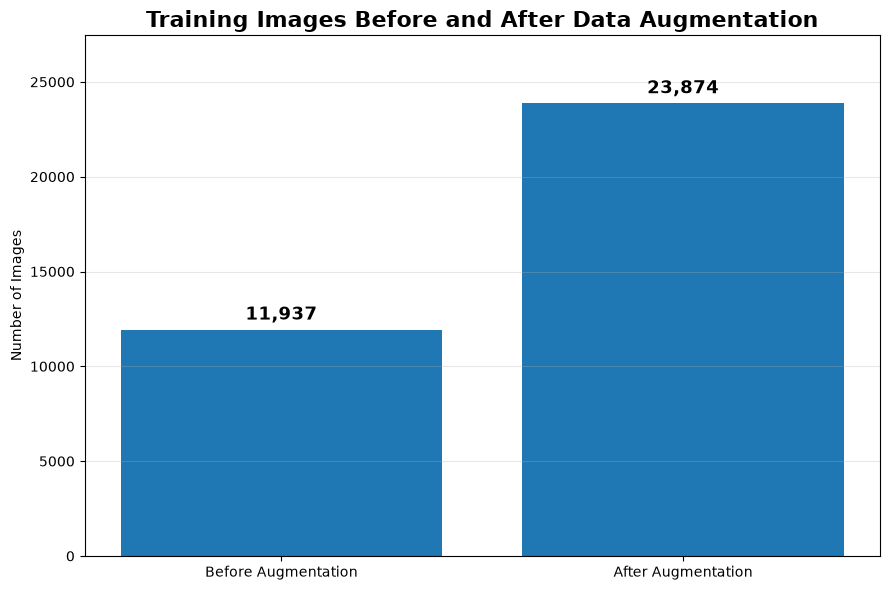

AUGMENTATION SUMMARY
Before augmentation : 11,937
After augmentation  : 23,874
Effective increase  : 11,937


In [8]:
# ============================================================
# CELL 3 — BEFORE VS AFTER AUGMENTATION
# ============================================================

import matplotlib.pyplot as plt

# Original training images
before_augmentation = 11937

# One augmented version for each original image
after_augmentation = before_augmentation * 2

labels = [
    "Before Augmentation",
    "After Augmentation"
]

values = [
    before_augmentation,
    after_augmentation
]

plt.figure(figsize=(9, 6))

bars = plt.bar(labels, values)

plt.title(
    "Training Images Before and After Data Augmentation",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Number of Images")
plt.ylim(0, after_augmentation * 1.15)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

print("=" * 60)
print("AUGMENTATION SUMMARY")
print("=" * 60)
print(f"Before augmentation : {before_augmentation:,}")
print(f"After augmentation  : {after_augmentation:,}")
print(f"Effective increase  : {after_augmentation - before_augmentation:,}")

In [1]:
# ============================================================
# CELL 1 — CLASS-WISE RBC SEGMENTATION
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Your actual dataset
TRAIN_DIR = r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final\train"

# Class names
class_names = {
    "0_Normal": "Normal",
    "1_Macrocyte": "Macrocyte",
    "2_Microcyte": "Microcyte",
    "3_Spherocyte": "Spherocyte",
    "4_Target_Cell": "Target Cell",
    "5_Stomatocyte": "Stomatocyte",
    "6_Ovalocyte": "Ovalocyte",
    "7_Teardrop": "Teardrop",
    "8_Burr_Cell": "Burr Cell",
    "9_Schistocyte": "Schistocyte",
    "10_Uncategorized": "Uncategorized",
    "11_Hypochromia": "Hypochromia"
}

print("Dataset path:")
print(TRAIN_DIR)

print("\nClasses:")
for folder, name in class_names.items():
    print(folder, "→", name)

ModuleNotFoundError: No module named 'cv2'

In [2]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\.venv_tf\Scripts\python.exe

Python version:
3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


In [3]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 8.5 MB/s eta 0:00:06
   - -------------------------------------- 1.6/44.0 MB 4.4 MB/s eta 0:00:10
   -- ------------------------------------- 2.9/44.0 MB 5.1 MB/s eta 0:00:09
   --- ------------------------------------ 4.2/44.0 MB 5.5 MB/s eta 0:00:08
   ----- ---------------------------------- 5.5/44.0 MB 5.8 MB/s eta 0:00:07
   ------ --------------------------------- 6.8/44.0 MB 5.9 MB/s eta 0:00:07
   ------- -------------------------------- 7.9/44.0 MB 5.7 MB/s eta 0:00:07
   ------- -------------------------------- 8.7/44.0 MB 5.4 MB/s eta 0:00:07
   -------- ------------------------------- 9.4/44.0 MB 5.3 MB/s eta 0:00:07
   ---------- ----------------------------- 11.3/44.0 MB 5.6 MB/s eta 0:00:06
   ----------- ---------------------------- 12.6/44.0 MB 5.8 MB/s eta 0:00:06
   ------------ --------------------------- 13.6/44.0 MB 5.6 MB/s eta 0:00:06
   

In [4]:
import cv2

print("OpenCV version:", cv2.__version__)
print("✅ OpenCV installed successfully")

OpenCV version: 5.0.0
✅ OpenCV installed successfully


In [5]:
# ============================================================
# CELL 1 — CLASS-WISE RBC SEGMENTATION
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Your actual dataset
TRAIN_DIR = r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final\train"

# Class names
class_names = {
    "0_Normal": "Normal",
    "1_Macrocyte": "Macrocyte",
    "2_Microcyte": "Microcyte",
    "3_Spherocyte": "Spherocyte",
    "4_Target_Cell": "Target Cell",
    "5_Stomatocyte": "Stomatocyte",
    "6_Ovalocyte": "Ovalocyte",
    "7_Teardrop": "Teardrop",
    "8_Burr_Cell": "Burr Cell",
    "9_Schistocyte": "Schistocyte",
    "10_Uncategorized": "Uncategorized",
    "11_Hypochromia": "Hypochromia"
}

print("Dataset path:")
print(TRAIN_DIR)

print("\nClasses:")
for folder, name in class_names.items():
    print(folder, "→", name)

Dataset path:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\data\rbc_dataset_final\train

Classes:
0_Normal → Normal
1_Macrocyte → Macrocyte
2_Microcyte → Microcyte
3_Spherocyte → Spherocyte
4_Target_Cell → Target Cell
5_Stomatocyte → Stomatocyte
6_Ovalocyte → Ovalocyte
7_Teardrop → Teardrop
8_Burr_Cell → Burr Cell
9_Schistocyte → Schistocyte
10_Uncategorized → Uncategorized
11_Hypochromia → Hypochromia


In [6]:
# ============================================================
# CELL 2 — RBC SEGMENTATION FUNCTION
# ============================================================

def segment_single_rbc(image_path, min_area=100):

    # --------------------------------------------------------
    # Read image
    # --------------------------------------------------------
    image = cv2.imread(image_path)

    if image is None:
        return None

    # OpenCV uses BGR
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # Convert to grayscale
    # --------------------------------------------------------
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # --------------------------------------------------------
    # Create binary image
    # --------------------------------------------------------
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # --------------------------------------------------------
    # Find external contours
    # --------------------------------------------------------
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    # --------------------------------------------------------
    # Remove small noise contours
    # --------------------------------------------------------
    filtered_contours = []

    for contour in contours:

        area = cv2.contourArea(contour)

        if area >= min_area:
            filtered_contours.append(contour)

    if len(filtered_contours) == 0:
        return None

    # --------------------------------------------------------
    # Select largest detected region
    # --------------------------------------------------------
    largest_contour = max(
        filtered_contours,
        key=cv2.contourArea
    )

    # --------------------------------------------------------
    # Create bounding box
    # --------------------------------------------------------
    x, y, w, h = cv2.boundingRect(
        largest_contour
    )

    # --------------------------------------------------------
    # Crop the detected RBC
    # --------------------------------------------------------
    cropped_rbc = image_rgb[
        y:y+h,
        x:x+w
    ]

    return cropped_rbc

In [7]:
# ============================================================
# CELL 3 — FIND ONE IMAGE PER CLASS
# ============================================================

selected_images = {}

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
)

for folder_name in class_names:

    class_path = os.path.join(
        TRAIN_DIR,
        folder_name
    )

    if not os.path.exists(class_path):
        print("⚠️ Class folder not found:", folder_name)
        continue

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(valid_extensions)
    ]

    if len(image_files) == 0:
        print("⚠️ No images found:", folder_name)
        continue

    # Take the first image
    image_path = os.path.join(
        class_path,
        image_files[0]
    )

    selected_images[folder_name] = image_path

print("=" * 60)
print("SELECTED IMAGES")
print("=" * 60)

for folder, path in selected_images.items():
    print(f"{class_names[folder]:20s} → {os.path.basename(path)}")

SELECTED IMAGES
Normal               → 102_rbc_73_class_0.png
Macrocyte            → 243_rbc_36_class_1.png
Microcyte            → 102_rbc_54_class_2.png
Spherocyte           → 100_rbc_10_class_3.png
Target Cell          → 107_rbc_11_class_4.png
Stomatocyte          → 118_rbc_22_class_5.png
Ovalocyte            → 107_rbc_10_class_6.png
Teardrop             → 117_rbc_1_class_7.png
Burr Cell            → 145_rbc_24_class_8.png
Schistocyte          → 107_rbc_1_class_9.png
Uncategorized        → 17_rbc_96_class_10.png
Hypochromia          → 117_rbc_13_class_11.png


In [8]:
# ============================================================
# CELL 4 — SEGMENT ONE RBC FROM EACH CLASS
# ============================================================

segmented_images = {}

for folder_name, image_path in selected_images.items():

    segmented = segment_single_rbc(
        image_path,
        min_area=100
    )

    if segmented is not None:

        segmented_images[folder_name] = segmented

    else:

        print(
            "⚠️ Segmentation failed:",
            class_names[folder_name]
        )

print()
print(
    "Successfully segmented:",
    len(segmented_images),
    "/",
    len(selected_images),
    "classes"
)


Successfully segmented: 12 / 12 classes


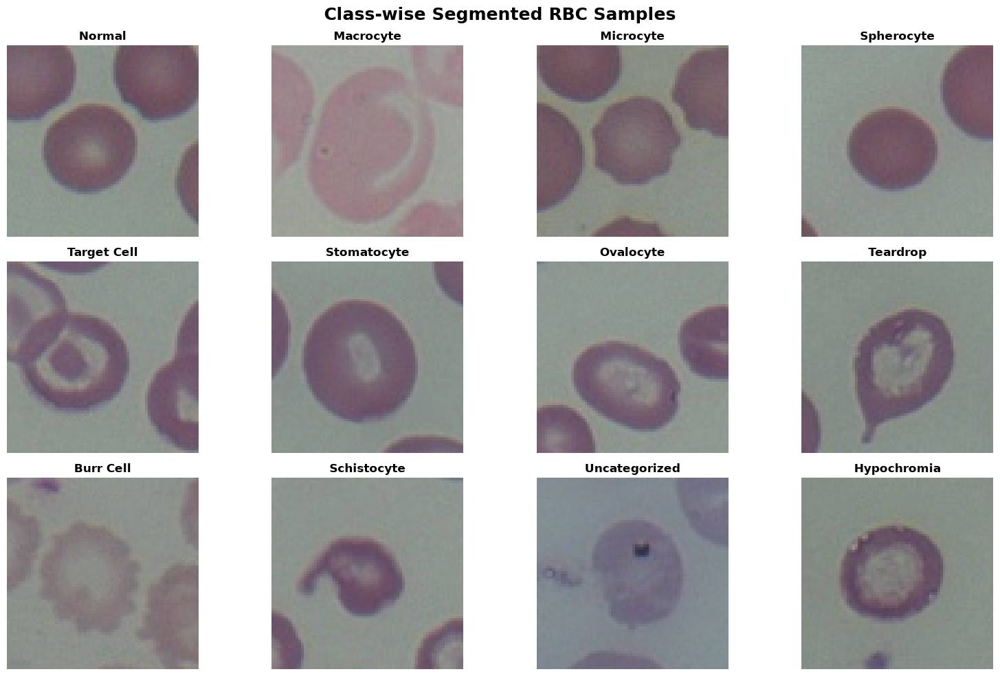

In [9]:
# ============================================================
# CELL 5 — DISPLAY CLASS-WISE SEGMENTED RBCs
# ============================================================

plt.figure(figsize=(16, 10))

for index, folder_name in enumerate(
    class_names.keys()
):

    if folder_name not in segmented_images:
        continue

    plt.subplot(3, 4, index + 1)

    plt.imshow(
        segmented_images[folder_name]
    )

    plt.title(
        class_names[folder_name],
        fontsize=12,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle(
    "Class-wise Segmented RBC Samples",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 6 — SAVE SEGMENTED RBC IMAGES
# ============================================================

OUTPUT_DIR = r"C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations\classwise_segmented_rbc"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

for folder_name, image in segmented_images.items():

    output_path = os.path.join(
        OUTPUT_DIR,
        folder_name + "_segmented.png"
    )

    # RGB → BGR for OpenCV saving
    image_bgr = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(
        output_path,
        image_bgr
    )

print("=" * 60)
print("SEGMENTED RBC IMAGES SAVED")
print("=" * 60)

print("Output folder:")
print(OUTPUT_DIR)

print()
print("Total saved:", len(segmented_images))

SEGMENTED RBC IMAGES SAVED
Output folder:
C:\Users\prana\OneDrive\Desktop\7TH SEM PROJECT\models\visualizations\classwise_segmented_rbc

Total saved: 12
